# # 📊 Análisis de Órdenes de Trabajo - Fase 1: Diagnóstico
# 
# ## Proyecto: Desarrollo de Estrategia Educativa para la Prevención de Daños en Dispositivos Médicos
# 
# **Estudiante:** Ana Luisa Parra Valencia  
# **Asesor:** Juan Guillermo Barreneche  
# **Organización:** Sociedad Médica Rionegro S.A.
# 
# ---
# 
# ### Objetivos de este análisis:
# 1. Revisar reportes de mantenimiento correctivo (últimos 12-24 meses)
# 2. Identificar dispositivos médicos con mayor frecuencia de daños por mal uso/mal trato
# 3. Clasificar tipos de daños según causa raíz
# 4. Identificar áreas asistenciales con mayor incidencia
# 5. Establecer criterios de inclusión para dispositivos críticos


# ## 1. Configuración inicial y carga de datos

In [1]:
# Importación de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import style
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
# Carga del archivo Excel
nombre_archivo = 'ordenes_filtradas_2025.xlsx'

try:
    df = pd.read_excel(nombre_archivo)
    print(f"Archivo cargado exitosamente: {nombre_archivo}")
    print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{nombre_archivo}'")
    print("Por favor, asegúrate de que el archivo esté en la misma carpeta que este notebook.")

Archivo cargado exitosamente: ordenes_filtradas_2025.xlsx
Dimensiones del dataset: 413 filas × 36 columnas


# ## 2. Exploración inicial de los datos

In [4]:
# Mostrar información general del dataset
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())

# %%
# Mostrar primeras filas
print("PRIMERAS 5 FILAS DEL DATASET")
print("=" * 50)
print(df.head())

# %%
# Mostrar estadísticas descriptivas de columnas numéricas
print("ESTADÍSTICAS DESCRIPTIVAS (columnas numéricas)")
print("=" * 50)
print(df.describe())

# %%
# Verificar valores nulos por columna
print("VALORES NULOS POR COLUMNA")
print("=" * 50)
valores_nulos = df.isnull().sum()
valores_nulos_pct = (df.isnull().sum() / len(df)) * 100
df_nulos = pd.DataFrame({
    'Valores Nulos': valores_nulos,
    'Porcentaje (%)': valores_nulos_pct
})
print(df_nulos[df_nulos['Valores Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False))


INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 36 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   CONSEC      413 non-null    int64         
 1   TIPO        413 non-null    object        
 2   SOLICI      413 non-null    int64         
 3   NOMSOL      413 non-null    object        
 4   DESCRI      413 non-null    object        
 5   NOMCEN      0 non-null      float64       
 6   RESPON      413 non-null    int64         
 7   NOMRES      413 non-null    object        
 8   NOMTER      11 non-null     object        
 9   SERVICI     411 non-null    object        
 10  UBICA       53 non-null     object        
 11  EQUIPO      413 non-null    object        
 12  CODIGO      413 non-null    int64         
 13  PLACA       384 non-null    object        
 14  CODINT      145 non-null    object        
 15  MARCA       413 non-null    object        

# ## 3. Limpieza y preparación de datos

In [8]:
# Identificar columnas clave para el análisis
columnas_clave = ['EQUIPO', 'CAUSA', 'SERVICI', 'UBICA', 'ESTADO', 'FECCRE', 'TIETOT']

print("COLUMNAS CLAVE IDENTIFICADAS:")
print("=" * 50)
for i, col in enumerate(columnas_clave, 1):
    print(f"{i}. {col}: {df[col].dtype if col in df.columns else 'NO ENCONTRADA'}")

# %%
# Verificar si tenemos las columnas necesarias
columnas_faltantes = [col for col in columnas_clave if col not in df.columns]
if columnas_faltantes:
    print(f"Advertencia: Faltan las siguientes columnas: {columnas_faltantes}")
else:
    print("Todas las columnas clave están presentes")

# %%
# Convertir columnas de fecha si existen
if 'FECCRE' in df.columns:
    df['FECCRE'] = pd.to_datetime(df['FECCRE'], errors='coerce')
    print("Columna FECCRE convertida a datetime")
    
    # Filtrar últimos 12-24 meses (ajustar según necesidad)
    fecha_minima = df['FECCRE'].max() - pd.DateOffset(months=24)
    df_reciente = df[df['FECCRE'] >= fecha_minima]
    print(f"Período analizado: {fecha_minima.date()} al {df['FECCRE'].max().date()}")
    print(f"Órdenes en el período: {len(df_reciente)} de {len(df)} totales")
else:
    df_reciente = df.copy()
    print("ℹNo se encontró columna de fecha, se analizarán todos los datos")

# %%
# Crear una copia del dataset para análisis
df_analisis = df_reciente.copy()

# Mostrar resumen del dataset de análisis
print("RESUMEN DEL DATASET PARA ANÁLISIS")
print("=" * 50)
print(f"• Total de órdenes: {len(df_analisis)}")
print(f"• Columnas disponibles: {len(df_analisis.columns)}")
print(f"• Período cubierto: {'Últimos 12 meses' if 'FECCRE' in df.columns else 'No especificado'}")

COLUMNAS CLAVE IDENTIFICADAS:
1. EQUIPO: object
2. CAUSA: object
3. SERVICI: object
4. UBICA: object
5. ESTADO: object
6. FECCRE: datetime64[ns]
7. TIETOT: float64
Todas las columnas clave están presentes
Columna FECCRE convertida a datetime
Período analizado: 2023-12-26 al 2025-12-26
Órdenes en el período: 413 de 413 totales
RESUMEN DEL DATASET PARA ANÁLISIS
• Total de órdenes: 413
• Columnas disponibles: 36
• Período cubierto: Últimos 12 meses


# ## 4. Análisis específico: Identificación de dispositivos críticos

ANÁLISIS DE DISPOSITIVOS CON MAYOR FRECUENCIA DE DAÑOS

Total de equipos únicos: 84
Top 10 equipos con más reportes:
                   EQUIPO  FRECUENCIA  PORCENTAJE
MONITOR DE SIGNOS VITALES         120   29.055690
          TERMOHIGRÓMETRO          22    5.326877
               INCUBADORA          21    5.084746
              FLUJÓMETRO           16    3.874092
            FONENDOSCOPIO          15    3.631961
                 GENERICO          14    3.389831
             CUNA TÉRMICA          13    3.147700
          MESA DE CIRUGÍA          12    2.905569
           CAMA ELÉCTRICA          10    2.421308
       REGULADOR DE VACÍO           8    1.937046


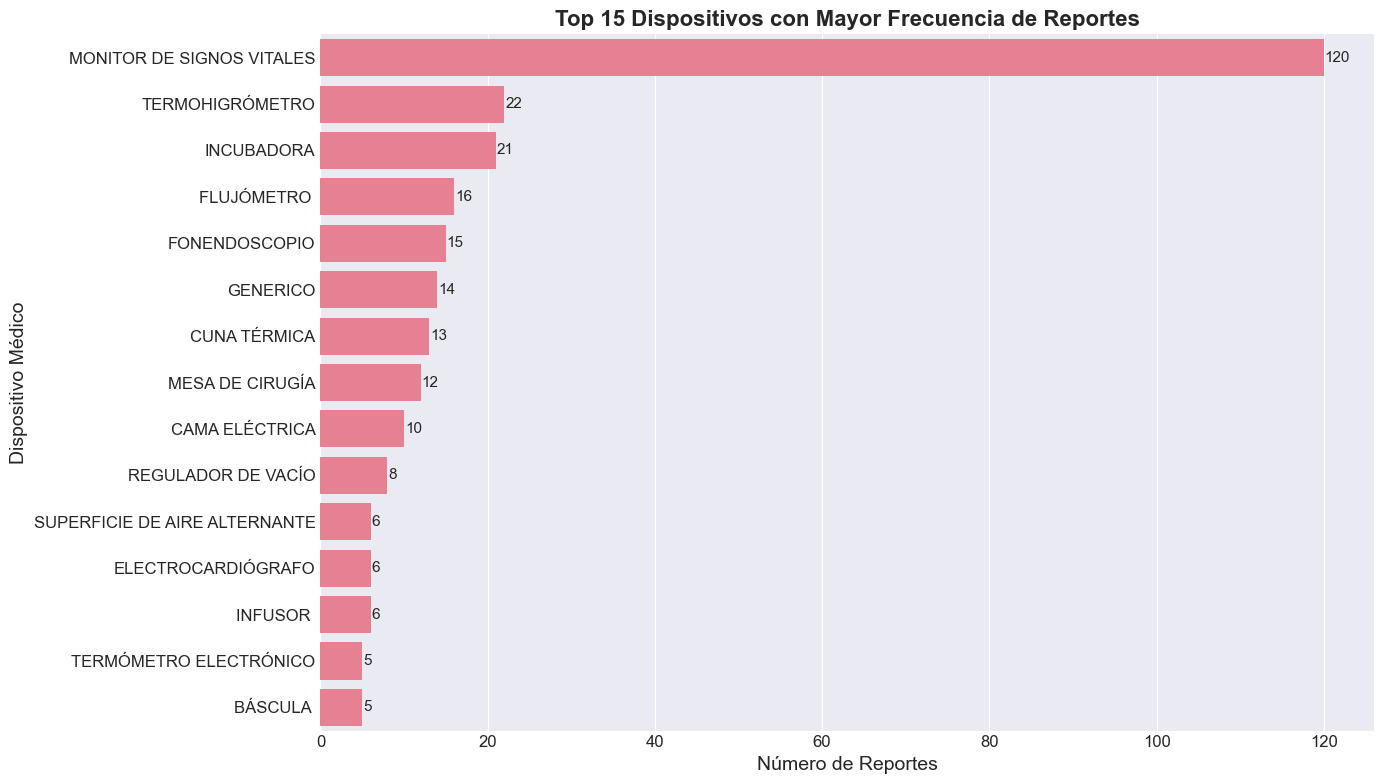

In [14]:
print("ANÁLISIS DE DISPOSITIVOS CON MAYOR FRECUENCIA DE DAÑOS")
print("=" * 60)

# Análisis por equipo
if 'EQUIPO' in df_analisis.columns:
    # Contar frecuencia por equipo
    frecuencia_equipos = df_analisis['EQUIPO'].value_counts().reset_index()
    frecuencia_equipos.columns = ['EQUIPO', 'FRECUENCIA']
    frecuencia_equipos['PORCENTAJE'] = (frecuencia_equipos['FRECUENCIA'] / len(df_analisis)) * 100
    
    print(f"\nTotal de equipos únicos: {len(frecuencia_equipos)}")
    print(f"Top 10 equipos con más reportes:")
    print(frecuencia_equipos.head(10).to_string(index=False))
    
    # Gráfico 1: Top 15 equipos con más reportes
    plt.figure(figsize=(14, 8))
    top_n = min(15, len(frecuencia_equipos))
    ax = sns.barplot(data=frecuencia_equipos.head(top_n), x='FRECUENCIA', y='EQUIPO')
    plt.title(f'Top {top_n} Dispositivos con Mayor Frecuencia de Reportes', fontsize=16, fontweight='bold')
    plt.xlabel('Número de Reportes', fontsize=14)
    plt.ylabel('Dispositivo Médico', fontsize=14)
    
    # Agregar valores en las barras
    for i, (freq, equipo) in enumerate(zip(frecuencia_equipos.head(top_n)['FRECUENCIA'], 
                                           frecuencia_equipos.head(top_n)['EQUIPO'])):
        plt.text(freq + 0.1, i, str(freq), va='center', fontsize=11)
    
    plt.tight_layout()
    plt.show()
else:
    print(" No se encontró la columna 'EQUIPO'")

# ## 5. Clasificación de tipos de daños según causa raíz

CLASIFICACIÓN DE TIPOS DE DAÑOS SEGÚN CAUSA RAÍZ

Total de causas únicas: 3
Top 15 causas más frecuentes:
              CAUSA  FRECUENCIA
          MAL TRATO         356
            MAL USO          55
MAL USO / MAL TRATO           2

Distribución por categoría de causa:
CATEGORIA  FRECUENCIA  PORCENTAJE
    OTROS         356   86.198547
  MAL USO          57   13.801453


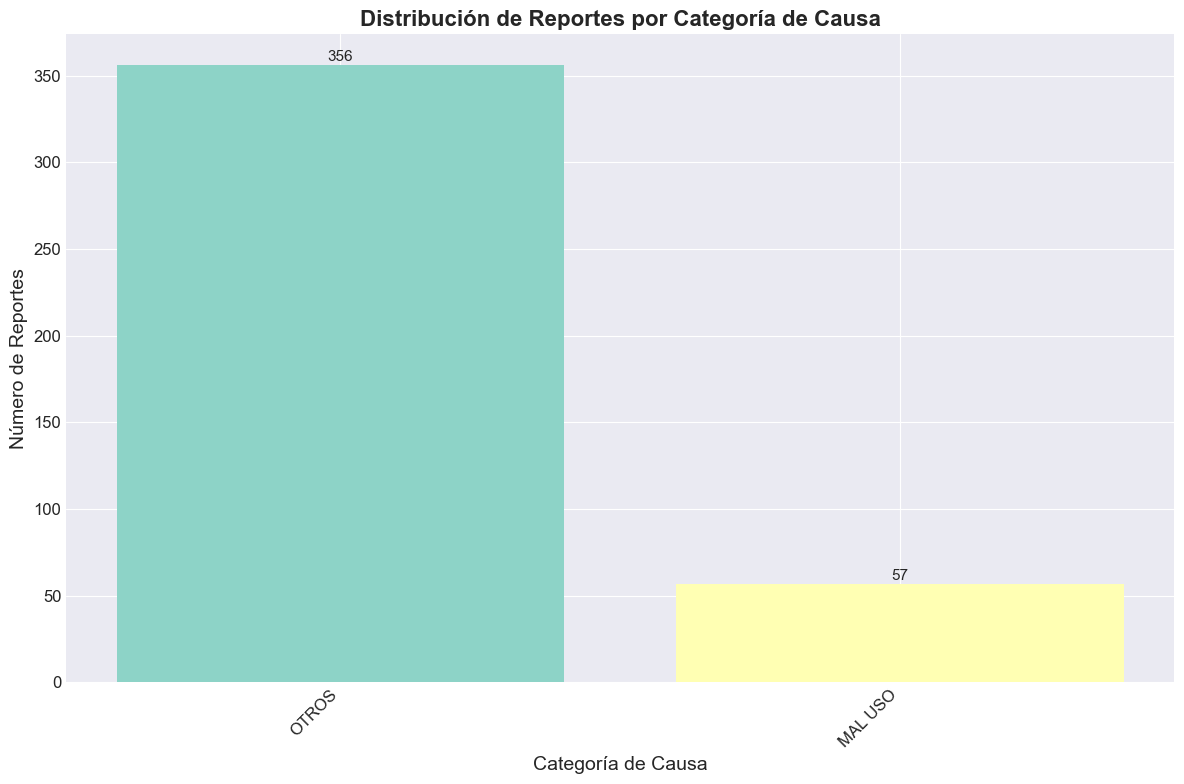

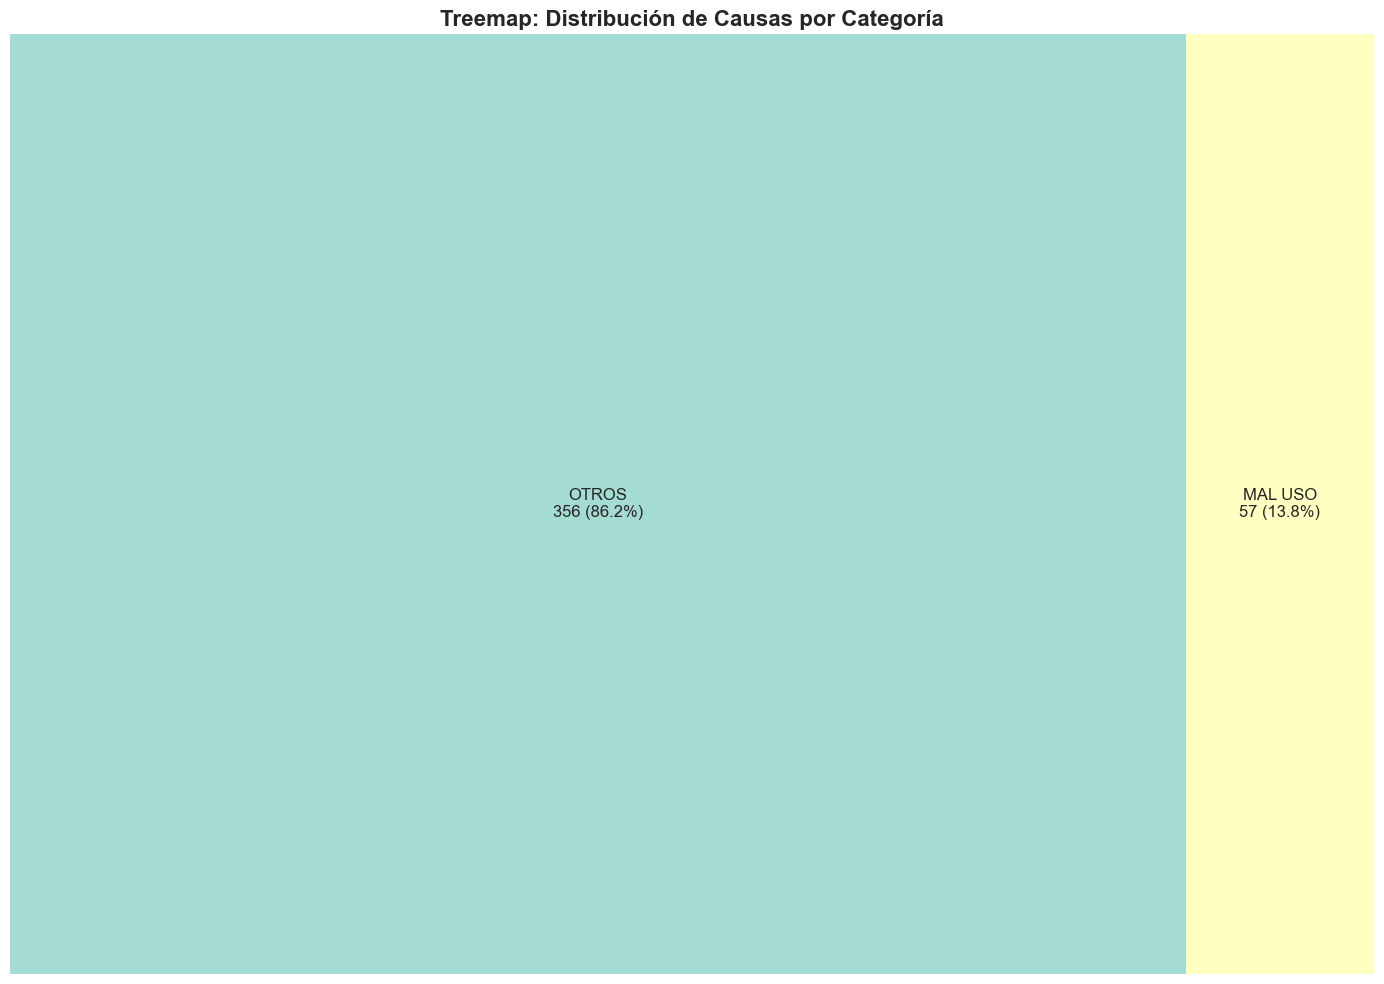


Análisis detallado de causas para Top 5 equipos:

MONITOR DE SIGNOS VITALES:
  • OTROS: 105 reportes
  • MAL USO: 15 reportes

TERMOHIGRÓMETRO:
  • OTROS: 22 reportes

INCUBADORA:
  • OTROS: 19 reportes
  • MAL USO: 2 reportes

FLUJÓMETRO :
  • OTROS: 16 reportes

FONENDOSCOPIO:
  • OTROS: 15 reportes


In [16]:
print("CLASIFICACIÓN DE TIPOS DE DAÑOS SEGÚN CAUSA RAÍZ")
print("=" * 60)

if 'CAUSA' in df_analisis.columns:
    # Limpiar y estandarizar texto de causas
    df_analisis['CAUSA_LIMPIA'] = df_analisis['CAUSA'].astype(str).str.strip().str.upper()
    
    # Identificar causas comunes (top 20)
    causas_frecuentes = df_analisis['CAUSA_LIMPIA'].value_counts().head(20).reset_index()
    causas_frecuentes.columns = ['CAUSA', 'FRECUENCIA']
    
    print(f"\nTotal de causas únicas: {df_analisis['CAUSA_LIMPIA'].nunique()}")
    print(f"Top 15 causas más frecuentes:")
    print(causas_frecuentes.head(15).to_string(index=False))
    
    # Categorización automática de causas
    categorias = {
        'GOLPES': ['GOLPE', 'CHOQUE', 'IMPACTO', 'CAÍDA', 'CAIDA', 'COLISIÓN'],
        'DERRAMES': ['DERRAME', 'LÍQUIDO', 'LIQUIDO', 'HUMEDAD', 'AGUA'],
        'MAL USO': ['MAL USO', 'USO INADECUADO', 'USO INCORRECTO', 'OPERACIÓN', 'MANIPULACIÓN'],
        'LIMPIEZA': ['LIMPIEZA', 'ASEO', 'DESINFECCIÓN', 'SANITIZACIÓN'],
        'ELECTRICO': ['ELÉCTRICO', 'ELECTRICO', 'CORTO', 'FUENTE', 'ENERGÍA'],
        'MECANICO': ['MECÁNICO', 'MECANICO', 'DESGASTE', 'ROTURA', 'FRACTURA'],
        'CONFIGURACIÓN': ['CONFIGURACIÓN', 'CALIBRACIÓN', 'AJUSTE', 'PROGRAMACIÓN'],
        'DESCONOCIDO': ['DESCONOCIDO', 'NO ESPECIFICADO', 'NAN', 'SIN INFORMACIÓN']
    }
    
    # Función para categorizar causas
    def categorizar_causa(texto):
        texto = str(texto).upper()
        for categoria, palabras in categorias.items():
            for palabra in palabras:
                if palabra in texto:
                    return categoria
        return 'OTROS'
    
    # Aplicar categorización
    df_analisis['CATEGORIA_CAUSA'] = df_analisis['CAUSA_LIMPIA'].apply(categorizar_causa)
    
    # Análisis por categoría
    categorias_analisis = df_analisis['CATEGORIA_CAUSA'].value_counts().reset_index()
    categorias_analisis.columns = ['CATEGORIA', 'FRECUENCIA']
    categorias_analisis['PORCENTAJE'] = (categorias_analisis['FRECUENCIA'] / len(df_analisis)) * 100
    
    print(f"\nDistribución por categoría de causa:")
    print(categorias_analisis.to_string(index=False))
    
    # Gráfico 2: Distribución por categoría de causa
    plt.figure(figsize=(12, 8))
    colors = plt.cm.Set3(np.arange(len(categorias_analisis)))
    bars = plt.bar(categorias_analisis['CATEGORIA'], categorias_analisis['FRECUENCIA'], color=colors)
    plt.title('Distribución de Reportes por Categoría de Causa', fontsize=16, fontweight='bold')
    plt.xlabel('Categoría de Causa', fontsize=14)
    plt.ylabel('Número de Reportes', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    
    # Agregar valores en las barras
    for bar, freq in zip(bars, categorias_analisis['FRECUENCIA']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                str(freq), ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Gráfico 3: Treemap de categorías (opcional)
    try:
        import squarify
        plt.figure(figsize=(14, 10))
        squarify.plot(sizes=categorias_analisis['FRECUENCIA'], 
                     label=categorias_analisis.apply(lambda x: f"{x['CATEGORIA']}\n{x['FRECUENCIA']} ({x['PORCENTAJE']:.1f}%)", axis=1),
                     alpha=0.8, 
                     color=plt.cm.Set3(np.arange(len(categorias_analisis))))
        plt.title('Treemap: Distribución de Causas por Categoría', fontsize=16, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("ℹPara el gráfico treemap, instala: pip install squarify")
    
    # Análisis de causas específicas por dispositivo (Top 5 equipos)
    if 'EQUIPO' in df_analisis.columns:
        top_5_equipos = frecuencia_equipos.head(5)['EQUIPO'].tolist()
        print(f"\nAnálisis detallado de causas para Top 5 equipos:")
        
        for equipo in top_5_equipos:
            causas_equipo = df_analisis[df_analisis['EQUIPO'] == equipo]['CATEGORIA_CAUSA'].value_counts()
            print(f"\n{equipo}:")
            for causa, freq in causas_equipo.head(3).items():
                print(f"  • {causa}: {freq} reportes")
else:
    print("No se encontró la columna 'CAUSA'")

# ## 6. Identificación de áreas asistenciales con mayor incidencia

IDENTIFICACIÓN DE ÁREAS ASISTENCIALES CON MAYOR INCIDENCIA

ANÁLISIS POR: SERVICI
----------------------------------------
Áreas únicas identificadas: 34

Top 10 áreas con mayor incidencia:
               AREA  FRECUENCIA  PORCENTAJE
            CIRUGÍA          74   17.917676
               UCIA          59   14.285714
               UCIN          57   13.801453
          URGENCIAS          42   10.169492
                UMI          24    5.811138
               UCIP          19    4.600484
              H6-T2          12    2.905569
UNIDAD FARMACÉUTICA          11    2.663438
              H2-T2          10    2.421308
              H2-T1          10    2.421308


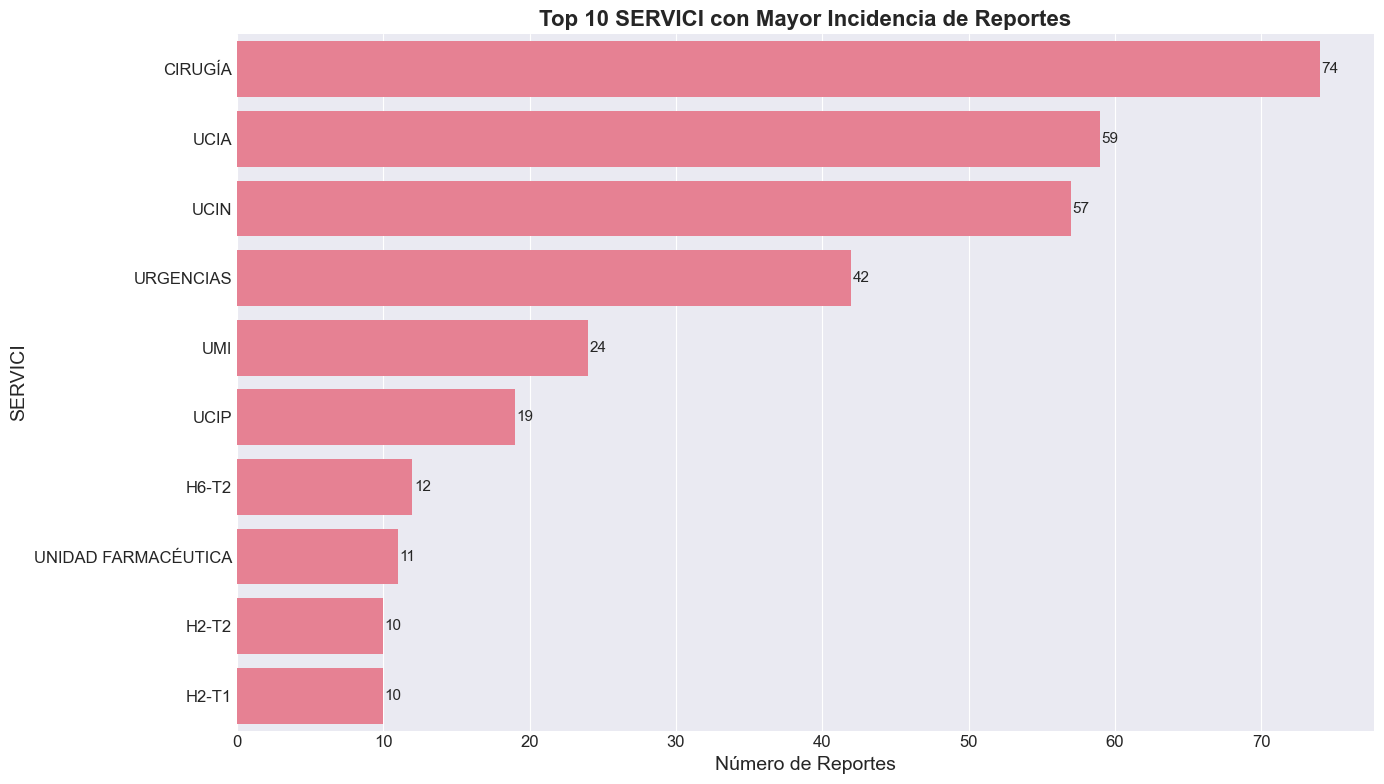


Análisis cruzado: SERVICI vs Categoría de Causa

Top 5 áreas para 'OTROS':
  • CIRUGÍA: 63 reportes
  • UCIA: 55 reportes
  • UCIN: 52 reportes
  • URGENCIAS: 34 reportes
  • UMI: 18 reportes

Top 5 áreas para 'MAL USO':
  • CIRUGÍA: 11 reportes
  • URGENCIAS: 8 reportes
  • UMI: 6 reportes
  • UCIN: 5 reportes
  • UCIA: 4 reportes

ANÁLISIS POR: UBICA
----------------------------------------
Áreas únicas identificadas: 30

Top 10 áreas con mayor incidencia:
                      AREA  FRECUENCIA  PORCENTAJE
         CUARTO DE EQUIPOS           6    1.452785
  CUARTO DE EQUIPOS 4 PISO           5    1.210654
               QUIRÓFANO 1           4    0.968523
            RECUPERACIÓN 1           3    0.726392
               QUIRÓFANO 3           3    0.726392
               QUIROFANO 4           3    0.726392
PREPARACION DE PACIENTES 1           2    0.484262
                CUBÍCULO 7           2    0.484262
               QUIROFANO 5           2    0.484262
      PUESTO DE ENFERMERÍA

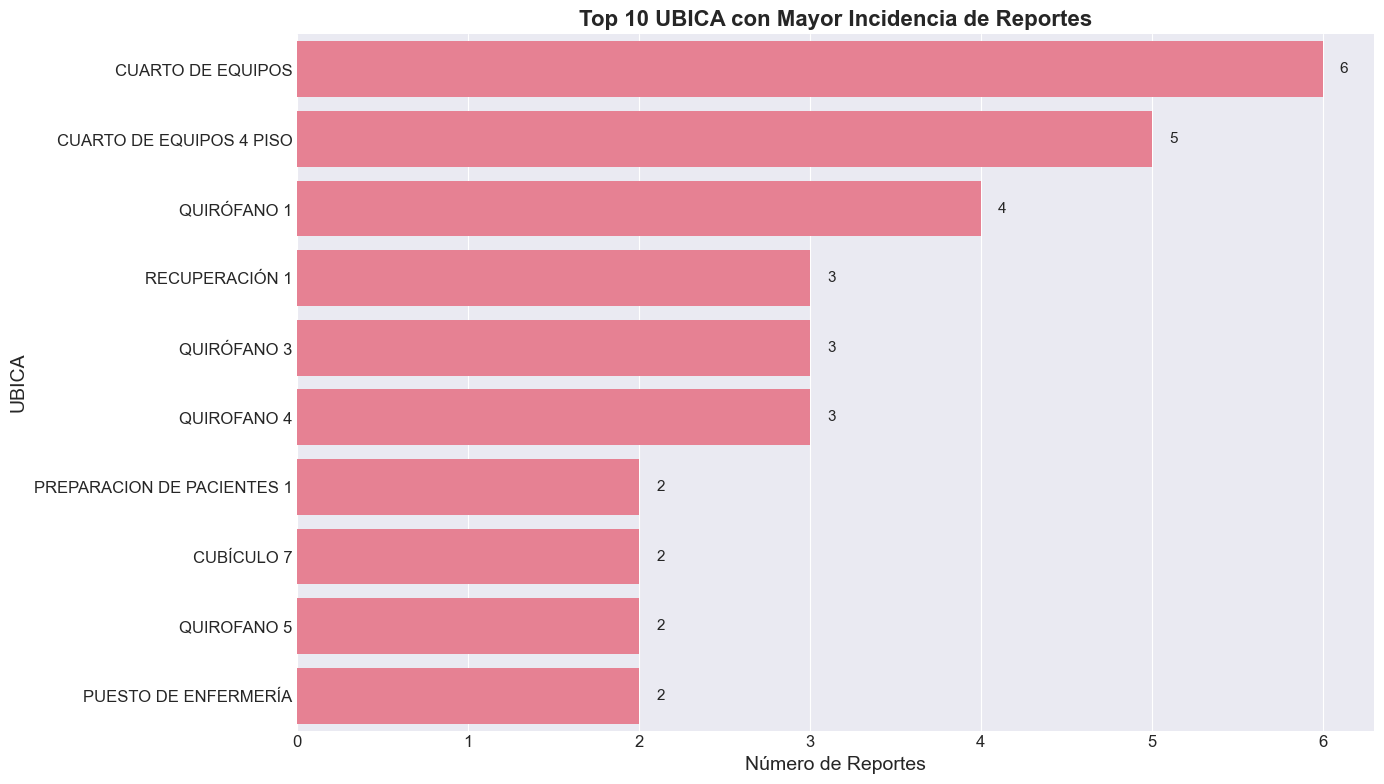


Análisis cruzado: UBICA vs Categoría de Causa

Top 5 áreas para 'OTROS':
  • CUARTO DE EQUIPOS: 6 reportes
  • CUARTO DE EQUIPOS 4 PISO: 4 reportes
  • QUIRÓFANO 1: 4 reportes
  • QUIRÓFANO 3: 3 reportes
  • RECUPERACIÓN 1: 3 reportes

Top 5 áreas para 'MAL USO':
  • CUARTO DE EQUIPOS 4 PISO: 1 reportes
  • PUESTO DE ENFERMERÍA: 1 reportes
  • QUIROFANO 4: 1 reportes
  • QUIROFANO 6: 1 reportes
  • QUIROFANO 8: 1 reportes


In [17]:
print("IDENTIFICACIÓN DE ÁREAS ASISTENCIALES CON MAYOR INCIDENCIA")
print("=" * 70)

# Análisis por servicio/ubicación
columnas_area = ['SERVICI', 'UBICA']
areas_disponibles = [col for col in columnas_area if col in df_analisis.columns]

if areas_disponibles:
    for col_area in areas_disponibles:
        print(f"\nANÁLISIS POR: {col_area}")
        print("-" * 40)
        
        # Contar frecuencia por área
        frecuencia_areas = df_analisis[col_area].value_counts().reset_index()
        frecuencia_areas.columns = ['AREA', 'FRECUENCIA']
        frecuencia_areas['PORCENTAJE'] = (frecuencia_areas['FRECUENCIA'] / len(df_analisis)) * 100
        
        print(f"Áreas únicas identificadas: {len(frecuencia_areas)}")
        print(f"\nTop 10 áreas con mayor incidencia:")
        print(frecuencia_areas.head(10).to_string(index=False))
        
        # Gráfico 4: Top áreas por incidencia
        plt.figure(figsize=(14, 8))
        top_n_areas = min(10, len(frecuencia_areas))
        ax = sns.barplot(data=frecuencia_areas.head(top_n_areas), x='FRECUENCIA', y='AREA')
        plt.title(f'Top {top_n_areas} {col_area} con Mayor Incidencia de Reportes', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Número de Reportes', fontsize=14)
        plt.ylabel(f'{col_area}', fontsize=14)
        
        # Agregar valores en las barras
        for i, (freq, area) in enumerate(zip(frecuencia_areas.head(top_n_areas)['FRECUENCIA'], 
                                            frecuencia_areas.head(top_n_areas)['AREA'])):
            plt.text(freq + 0.1, i, str(freq), va='center', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        # Análisis cruzado: Áreas vs Categorías de causa
        if 'CATEGORIA_CAUSA' in df_analisis.columns:
            print(f"\nAnálisis cruzado: {col_area} vs Categoría de Causa")
            
            # Crear tabla pivote
            pivot_table = pd.crosstab(df_analisis[col_area], df_analisis['CATEGORIA_CAUSA'])
            
            # Top 5 áreas para cada categoría principal
            top_categorias = categorias_analisis.head(3)['CATEGORIA'].tolist()
            
            for categoria in top_categorias:
                if categoria in pivot_table.columns:
                    top_areas_categoria = pivot_table[categoria].sort_values(ascending=False).head(5)
                    print(f"\nTop 5 áreas para '{categoria}':")
                    for area, freq in top_areas_categoria.items():
                        print(f"  • {area}: {freq} reportes")
else:
    print("No se encontraron columnas de área (SERVICI o UBICA)")

# ## 6.5 ANÁLISIS DE TEXTO PARA IDENTIFICAR CATEGORÍAS DE MANIPULACIÓN

🔍 ANÁLISIS DE LA COLUMNA OBSERV PARA CATEGORIZAR MANIPULACIÓN

📝 EJEMPLOS DE OBSERVACIONES:
----------------------------------------

Ejemplo 1:
Diagnostico: Se reporta nevera en el servicio ya que la temperatura estaba fuera de rango Actividad realizada: Se revisa controlador y se encuentran configurado correctamente Se revisa funcionamiento del equipo y se puede ver que es difícil llegar a la temperatura por que el personal abre mucho la p...

Ejemplo 2:
Diagnostico: monitor no toma la frecuencia cardiaca Actividad realizada: Se revisa equipo y se encuentra que no tiene configurado el parámetro PR. Se admite parámetro y se realizan pruebas de funcionamiento satisfactoriamente Estado final: Equipo en optimas condiciones de funcionamiento Repuestos: n...

Ejemplo 3:
Diagnostico: Equipo no toma presion no invasiva Actividad realizada: Se revisa equipo y se encuentra que estaba configurado en modo adulto y el paciente era neonatal. Se realiza cambio de tipo de paciente y se realizan vari

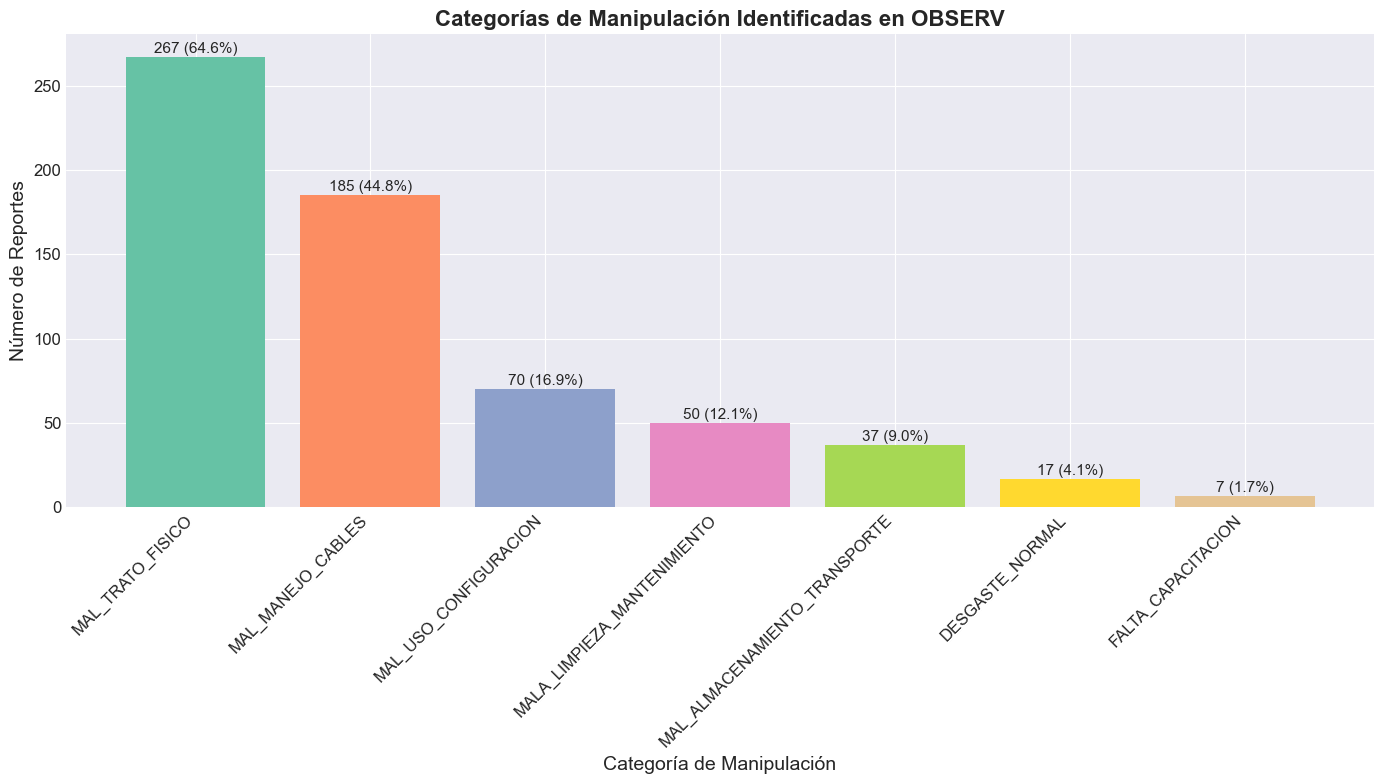


🔗 COMBINACIONES MÁS FRECUENTES DE CATEGORÍAS:
--------------------------------------------------
• MAL_TRATO_FISICO, MAL_MANEJO_CABLES: 105 reportes (28.4%)
• MAL_TRATO_FISICO: 83 reportes (22.4%)
• MAL_MANEJO_CABLES: 30 reportes (8.1%)
• MAL_USO_CONFIGURACION: 20 reportes (5.4%)
• MAL_USO_CONFIGURACION, MAL_TRATO_FISICO: 17 reportes (4.6%)
• MAL_TRATO_FISICO, MALA_LIMPIEZA_MANTENIMIENTO: 13 reportes (3.5%)
• MAL_USO_CONFIGURACION, MAL_TRATO_FISICO, MAL_MANEJO_CABLES: 11 reportes (3.0%)
• MALA_LIMPIEZA_MANTENIMIENTO: 9 reportes (2.4%)
• MAL_TRATO_FISICO, MAL_ALMACENAMIENTO_TRANSPORTE: 8 reportes (2.2%)
• MAL_ALMACENAMIENTO_TRANSPORTE: 8 reportes (2.2%)

📝 EJEMPLOS DE OBSERVACIONES POR CATEGORÍA:
------------------------------------------------------------

🔍 MAL_TRATO_FISICO:
  Ejemplo 1: Diagnostico: Se reporta equipo ya que no tomaba la presion arterial Actividad realizada: Se realiza cambio de brazalete ya que tenía el velcro en mal ...
  Ejemplo 2: Diagnostico: Equipo con uno de l

<Figure size 1600x1000 with 0 Axes>

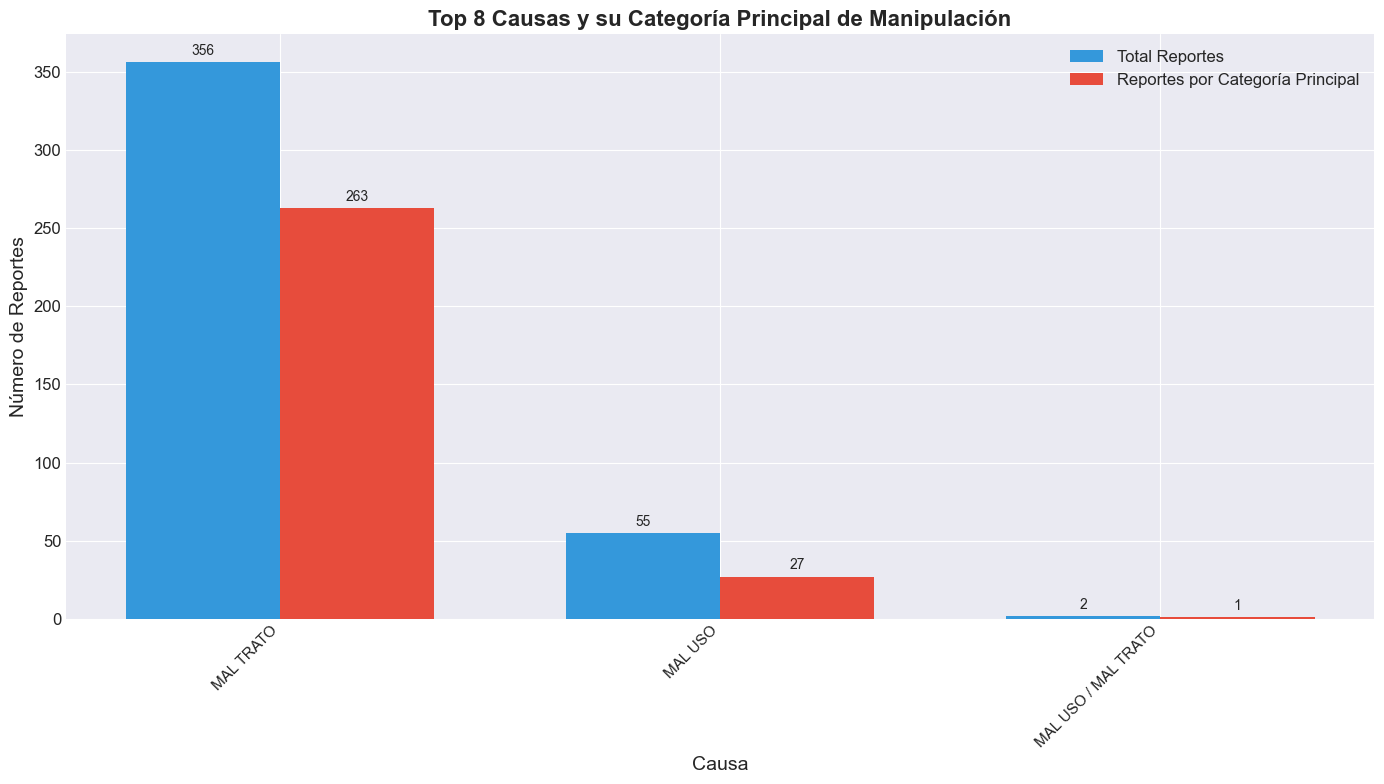


📋 MATRIZ SIMPLIFICADA DE RELACIÓN:
------------------------------------------------------------
Matriz de 3 causas × 7 categorías

🔝 Top 5 relaciones (Causa → Categoría):
1. 'MAL TRATO...' → MAL_TRATO_FISICO: 263 reportes
2. 'MAL TRATO...' → MAL_MANEJO_CABLES: 169 reportes
3. 'MAL TRATO...' → MALA_LIMPIEZA_MANTENIMIENTO: 45 reportes
4. 'MAL TRATO...' → MAL_USO_CONFIGURACION: 42 reportes
5. 'MAL TRATO...' → MAL_ALMACENAMIENTO_TRANSPORTE: 34 reportes


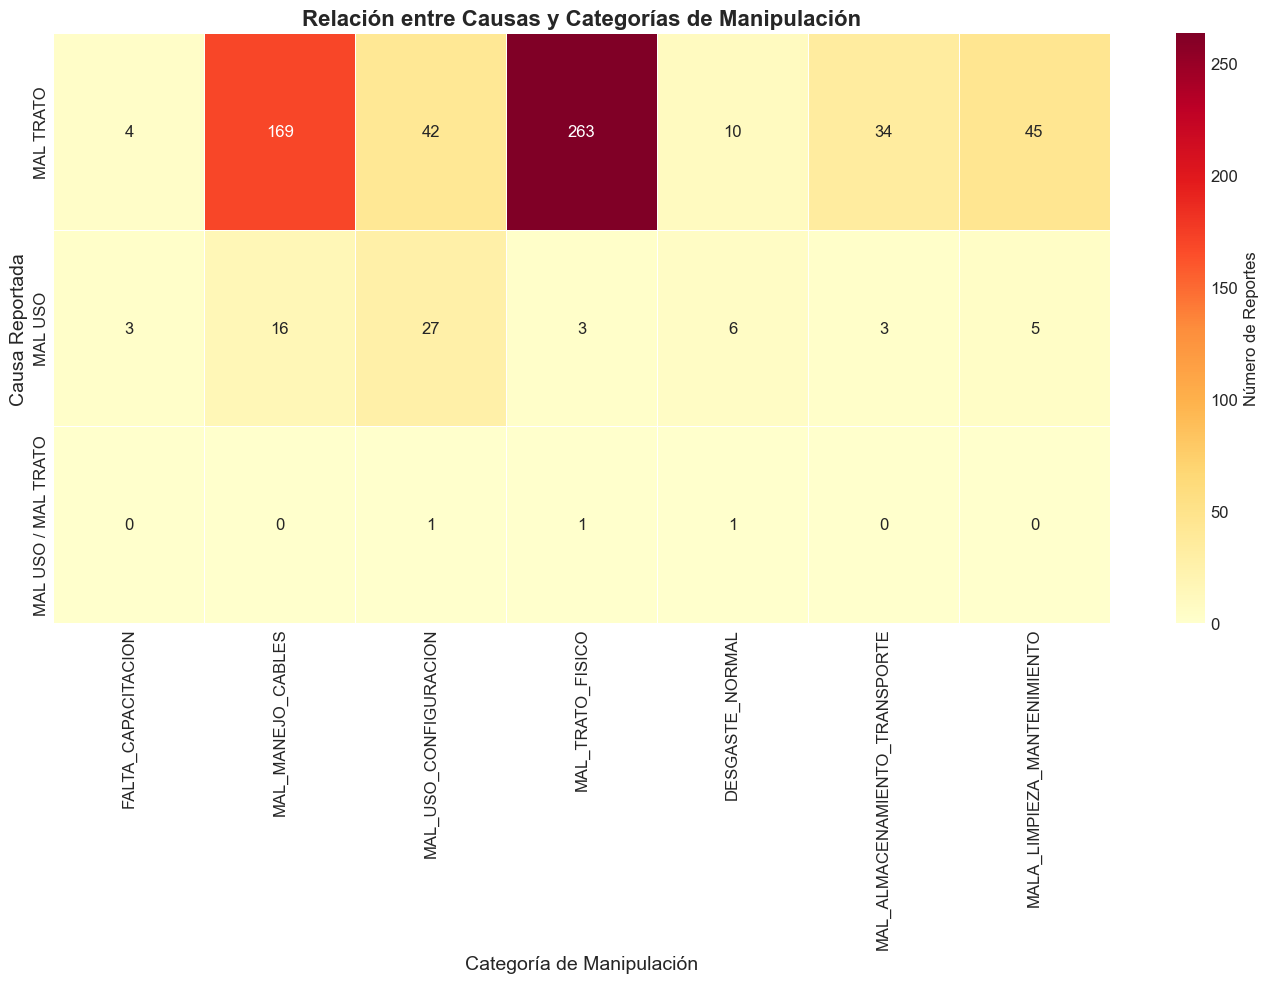


💾 Matriz de relación exportada a: resultados/matriz_causa_manipulacion.xlsx

🔍 IDENTIFICANDO DISCREPANCIAS ENTRE CAUSA Y OBSERVACIONES:
------------------------------------------------------------
✅ No se encontraron discrepancias significativas entre CAUSA y OBSERV

📈 ANÁLISIS DE COHERENCIA ENTRE CAUSA Y OBSERV:
--------------------------------------------------
• Total de casos: 413
• Casos con OBSERV no nulo: 413 (100.0%)
• Casos con categoría identificada: 370 (89.6%)
• Casos donde CAUSA sugiere NO manipulación: 0 (0.0%)


In [ ]:

# Análisis de la columna OBSERV para identificar patrones de mal uso/mal trato

# %%
print("🔍 ANÁLISIS DE LA COLUMNA OBSERV PARA CATEGORIZAR MANIPULACIÓN")
print("=" * 80)

if 'OBSERV' in df_analisis.columns:
    # Mostrar algunas observaciones de ejemplo
    print("\n📝 EJEMPLOS DE OBSERVACIONES:")
    print("-" * 40)
    for i, obs in enumerate(df_analisis['OBSERV'].dropna().head(5), 1):
        print(f"\nEjemplo {i}:\n{obs[:300]}...")  # Mostrar primeros 300 caracteres
    
    # Limpieza básica del texto
    df_analisis['OBSERV_LIMPIO'] = df_analisis['OBSERV'].fillna('').astype(str).str.lower()
    
    # Lista de palabras clave para identificar diferentes tipos de manipulación
    # Basado en los ejemplos proporcionados
    
    palabras_clave_manipulacion = {
        'MAL_USO_CONFIGURACION': [
            'configurado', 'configuración', 'modo adulto', 'modo neonato', 
            'modo niño', 'derivadas', 'parámetro', 'tipo de paciente',
            'programado', 'ajuste', 'calibración', 'filtro', 'velocidad',
            'predeterminado', 'límites', 'alarmas', 'conjunto', 'ajustar',
            'configurar', 'seleccionar', 'cambio'
        ],
        'MAL_TRATO_FISICO': [
            'golpe', 'caída', 'caida', 'choque', 'impacto', 'pisada',
            'fuerza', 'brusco', 'movimiento brusco', 'torcido', 'torcidos',
            'doblado', 'doblados', 'fractura', 'fracturado', 'fracturada',
            'quebrado', 'quebrada', 'reventado', 'reventada', 'reventados',
            'partido', 'partida', 'roto', 'rota', 'rotos', 'rotura',
            'hundido', 'hundida', 'suelto', 'suelta', 'soltar',
            'desprendido', 'desprendida', 'arrancado', 'arrancada',
            'cortado', 'cortada', 'rasgado', 'rasgada', 'rasgadura',
            'aplastamiento', 'aplastado', 'aplastada', 'daño', 'mal estado',
            'desgarrado', 'desgarrada', 'maltrato', 'mal trato'
        ],
        'MAL_MANEJO_CABLES': [
            'cable', 'cables', 'cableado', 'conector', 'conectores',
            'pin', 'pines', 'latiguillo', 'latiguillos', 'terminal',
            'soldadura', 'soldado', 'soldar', 'conexión', 'desconectado',
            'desconexión', 'enchufe', 'acople', 'acoplamiento', 'conectar',
            'desconectar', 'puerto', 'enchufar', 'desenchufar', 'adaptador',
            'interface', 'interfaz'
        ],
        'MALA_LIMPIEZA_MANTENIMIENTO': [
            'líquido', 'liquido', 'humedad', 'agua', 'sangre', 'fluido',
            'derrame', 'derramado', 'sucio', 'limpia', 'limpieza',
            'desinfección', 'sanitización', 'residuos', 'almohadilla',
            'velcro', 'pegamento', 'adhesivo', 'sangre', 'líquidos',
            'residuos', 'contaminación', 'aseo', 'sanitario', 'limpiar'
        ],
        'MAL_ALMACENAMIENTO_TRANSPORTE': [
            'almacenamiento', 'transporte', 'guardado', 'bodega',
            'perdido', 'extraviado', 'ubicación', 'colocación',
            'posición', 'orientación', 'dejar', 'colocar', 'ubicar',
            'mover', 'trasladar', 'llevar', 'traer'
        ],
        'FALTA_CAPACITACION': [
            'no sabe', 'desconoce', 'ignoraba', 'capacitación',
            'entrenamiento', 'instrucción', 'enseñar', 'mostrar',
            'indicar', 'explicar', 'conocimiento', 'entendimiento',
            'enseñanza', 'informar', 'capacitar', 'instruir', 'mostrar cómo'
        ],
        'DESGASTE_NORMAL': [
            'desgaste', 'vida útil', 'tiempo', 'uso continuo',
            'antiguo', 'viejo', 'uso prolongado', 'frecuencia',
            'horas de uso', 'operación continua'
        ]
    }
    
    # Función para categorizar cada observación
    def categorizar_observacion(texto):
        categorias_encontradas = []
        texto = str(texto).lower()
        
        for categoria, palabras in palabras_clave_manipulacion.items():
            for palabra in palabras:
                if palabra in texto:
                    if categoria not in categorias_encontradas:
                        categorias_encontradas.append(categoria)
                    break  # Solo necesitamos una palabra por categoría
        
        return ', '.join(categorias_encontradas) if categorias_encontradas else 'NO_IDENTIFICADO'
    
    # Aplicar categorización
    print("\n🔄 Procesando observaciones...")
    df_analisis['CATEGORIA_MANIPULACION'] = df_analisis['OBSERV_LIMPIO'].apply(categorizar_observacion)
    
    # Separar múltiples categorías
    df_analisis['CATEGORIA_MANIPULACION_LISTA'] = df_analisis['CATEGORIA_MANIPULACION'].apply(
        lambda x: x.split(', ') if x != 'NO_IDENTIFICADO' else []
    )
    
    # Análisis de frecuencia de categorías
    print("\n📊 FRECUENCIA DE CATEGORÍAS DE MANIPULACIÓN IDENTIFICADAS:")
    print("-" * 60)
    
    # Contar categorías individuales
    todas_categorias = []
    for categorias in df_analisis['CATEGORIA_MANIPULACION_LISTA']:
        todas_categorias.extend(categorias)
    
    if todas_categorias:
        from collections import Counter
        contador_categorias = Counter(todas_categorias)
        
        # Crear DataFrame con resultados
        df_categorias_manip = pd.DataFrame.from_dict(contador_categorias, 
                                                    orient='index', 
                                                    columns=['FRECUENCIA'])
        df_categorias_manip = df_categorias_manip.sort_values('FRECUENCIA', ascending=False)
        df_categorias_manip['PORCENTAJE'] = (df_categorias_manip['FRECUENCIA'] / len(df_analisis)) * 100
        
        print(f"Total de observaciones analizadas: {len(df_analisis)}")
        print(f"Observaciones con categoría identificada: {len(df_analisis[df_analisis['CATEGORIA_MANIPULACION'] != 'NO_IDENTIFICADO'])}")
        print(f"Categorías únicas identificadas: {len(df_categorias_manip)}")
        print("\nDistribución de categorías:")
        print(df_categorias_manip.to_string())
        
        # Gráfico: Distribución de categorías de manipulación
        plt.figure(figsize=(14, 8))
        colors = plt.cm.Set2(np.arange(len(df_categorias_manip)))
        bars = plt.bar(df_categorias_manip.index, 
                      df_categorias_manip['FRECUENCIA'], 
                      color=colors)
        
        plt.title('Categorías de Manipulación Identificadas en OBSERV', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Categoría de Manipulación', fontsize=14)
        plt.ylabel('Número de Reportes', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        
        # Agregar valores en las barras
        for bar, freq, pct in zip(bars, 
                                 df_categorias_manip['FRECUENCIA'], 
                                 df_categorias_manip['PORCENTAJE']):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{freq} ({pct:.1f}%)", ha='center', va='bottom', fontsize=11)
        
        plt.tight_layout()
        plt.show()
        
        # Análisis de combinaciones de categorías
        print("\n🔗 COMBINACIONES MÁS FRECUENTES DE CATEGORÍAS:")
        print("-" * 50)
        
        # Contar combinaciones (solo para observaciones con categoría)
        df_con_categoria = df_analisis[df_analisis['CATEGORIA_MANIPULACION'] != 'NO_IDENTIFICADO']
        combinaciones = df_con_categoria['CATEGORIA_MANIPULACION'].value_counts().head(10)
        
        for combo, freq in combinaciones.items():
            if combo != '':
                pct = (freq / len(df_con_categoria)) * 100
                print(f"• {combo}: {freq} reportes ({pct:.1f}%)")
        
        # Ejemplos específicos por categoría
        print("\n📝 EJEMPLOS DE OBSERVACIONES POR CATEGORÍA:")
        print("-" * 60)
        
        for categoria in df_categorias_manip.head(5).index:
            print(f"\n🔍 {categoria}:")
            ejemplos = df_analisis[df_analisis['CATEGORIA_MANIPULACION'].str.contains(categoria)]['OBSERV'].head(2)
            for i, ejemplo in enumerate(ejemplos, 1):
                if pd.notna(ejemplo):
                    # Extraer solo la parte relevante
                    lines = str(ejemplo).split('\n')
                    diagnostico = next((line for line in lines if any(keyword in line.lower() 
                                                                    for keyword in ['diagnostico:', 'diagnóstico:', 'diagnostico'])), 
                                      lines[0] if lines else '')
                    print(f"  Ejemplo {i}: {diagnostico[:150]}...")
        
        # Análisis cruzado con equipos
        if 'EQUIPO' in df_analisis.columns:
            print("\n🏥 CATEGORÍAS POR EQUIPO (Top 5 equipos):")
            print("-" * 50)
            
            top_equipos = df_analisis['EQUIPO'].value_counts().head(5).index
            
            for equipo in top_equipos:
                print(f"\n📋 {equipo}:")
                equipo_data = df_analisis[df_analisis['EQUIPO'] == equipo]
                
                # Contar categorías para este equipo
                cats_equipo = []
                for cats in equipo_data['CATEGORIA_MANIPULACION_LISTA']:
                    cats_equipo.extend(cats)
                
                if cats_equipo:
                    contador_equipo = Counter(cats_equipo)
                    for cat, freq in contador_equipo.most_common(3):
                        pct = (freq / len(equipo_data)) * 100
                        print(f"  • {cat}: {freq} ({pct:.1f}%)")
                else:
                    print(f"  • No se identificaron categorías específicas")
        
        # Identificar las categorías principales para manipulación
        # Excluir DESGASTE_NORMAL ya que no es manipulación
        categorias_manip = [cat for cat in df_categorias_manip.index if cat != 'DESGASTE_NORMAL']
        CATEGORIAS_MANIPULACION = categorias_manip[:4]  # Tomar las 4 principales
        
        print(f"\n🎯 CATEGORÍAS PRINCIPALES IDENTIFICADAS PARA MANIPULACIÓN:")
        print(f"{', '.join(CATEGORIAS_MANIPULACION)}")
        
        # Guardar resultados
        df_categorias_manip.to_excel('resultados/categorias_manipulacion.xlsx')
        print("\n💾 Resultados exportados a: resultados/categorias_manipulacion.xlsx")
        
    else:
        print("⚠️ No se identificaron categorías de manipulación en las observaciones")
        CATEGORIAS_MANIPULACION = ['MAL_TRATO_FISICO', 'MAL_USO_CONFIGURACION', 'MAL_MANEJO_CABLES']
    
else:
    print("❌ No se encontró la columna 'OBSERV'")
    # Si no hay OBSERV, usar categorías por defecto
    CATEGORIAS_MANIPULACION = ['MAL_TRATO_FISICO', 'MAL_USO_CONFIGURACION', 'MAL_MANEJO_CABLES']

# %% [markdown]
# ## 6.6 ANALIZAR RELACIÓN ENTRE CAUSA (CAUSA) Y OBSERVACIONES (OBSERV) - VERSIÓN CORREGIDA
# 
# Comparar la categorización automática con la columna CAUSA existente

# %%
print("🔄 COMPARANDO CATEGORÍAS DE CAUSA CON OBSERVACIONES (VERSIÓN CORREGIDA)")
print("=" * 70)

if 'CAUSA_LIMPIA' in df_analisis.columns and 'CATEGORIA_MANIPULACION' in df_analisis.columns:
    # SOLUCIÓN AL ERROR: Crear un DataFrame temporal con índices únicos
    temp_df = df_analisis.copy()
    
    # Crear un índice temporal único si hay duplicados en CAUSA_LIMPIA
    if temp_df['CAUSA_LIMPIA'].duplicated().any():
        print(f"⚠️ Advertencia: Se encontraron {temp_df['CAUSA_LIMPIA'].duplicated().sum()} valores duplicados en CAUSA_LIMPIA")
        # Crear un identificador único temporal
        temp_df['CAUSA_UNICA'] = temp_df['CAUSA_LIMPIA'] + '_' + temp_df.index.astype(str)
    else:
        temp_df['CAUSA_UNICA'] = temp_df['CAUSA_LIMPIA']
    
    # Preparar datos para el crosstab
    causas_unicas = temp_df['CAUSA_LIMPIA'].value_counts().head(15).index
    print(f"\n📊 Análisis de las {len(causas_unicas)} causas más frecuentes:")
    
    # Método alternativo: Crear matriz manualmente
    print("\n🔝 TOP 10 CAUSAS VS CATEGORÍAS DE MANIPULACIÓN:")
    print("-" * 60)
    
    # Crear un DataFrame para análisis
    resultados = []
    
    for causa in causas_unicas:
        # Filtrar por esta causa
        subset = temp_df[temp_df['CAUSA_LIMPIA'] == causa]
        
        # Obtener categorías de manipulación
        categorias_causa = []
        for cats in subset['CATEGORIA_MANIPULACION_LISTA']:
            categorias_causa.extend(cats)
        
        if categorias_causa:
            contador = Counter(categorias_causa)
            # Tomar la categoría más frecuente
            categoria_principal, freq = contador.most_common(1)[0]
            pct = (freq / len(subset)) * 100
            
            resultados.append({
                'CAUSA': causa[:80] + '...' if len(causa) > 80 else causa,
                'FRECUENCIA': len(subset),
                'CATEGORIA_PRINCIPAL': categoria_principal,
                'REPORTES_CATEGORIA': freq,
                '%_EN_CAUSA': pct
            })
    
    # Crear DataFrame de resultados
    if resultados:
        df_resultados = pd.DataFrame(resultados)
        df_resultados = df_resultados.sort_values('FRECUENCIA', ascending=False)
        
        print(df_resultados.head(10).to_string(index=False))
        
        # Gráfico: Causas principales y sus categorías
        plt.figure(figsize=(16, 10))
        
        # Preparar datos para gráfico de barras agrupadas
        top_causas = df_resultados.head(8)
        
        x = np.arange(len(top_causas))
        width = 0.35
        
        fig, ax1 = plt.subplots(figsize=(14, 8))
        
        # Barras para frecuencia total
        bars1 = ax1.bar(x - width/2, top_causas['FRECUENCIA'], width, 
                       label='Total Reportes', color='#3498db')
        
        # Barras para reportes por categoría principal
        bars2 = ax1.bar(x + width/2, top_causas['REPORTES_CATEGORIA'], width,
                       label='Reportes por Categoría Principal', color='#e74c3c')
        
        ax1.set_xlabel('Causa', fontsize=14)
        ax1.set_ylabel('Número de Reportes', fontsize=14)
        ax1.set_title('Top 8 Causas y su Categoría Principal de Manipulación', 
                     fontsize=16, fontweight='bold')
        
        # Configurar eje x con nombres de causas truncados
        ax1.set_xticks(x)
        ax1.set_xticklabels(top_causas['CAUSA'], rotation=45, ha='right', fontsize=11)
        
        # Agregar etiquetas en las barras
        def autolabel(bars):
            for bar in bars:
                height = bar.get_height()
                ax1.annotate(f'{int(height)}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center', va='bottom', fontsize=10)
        
        autolabel(bars1)
        autolabel(bars2)
        
        ax1.legend()
        plt.tight_layout()
        plt.show()
        
        # Método 2: Crear matriz simplificada sin crosstab
        print("\n📋 MATRIZ SIMPLIFICADA DE RELACIÓN:")
        print("-" * 60)
        
        # Crear matriz manual
        categorias_manip_unicas = list(set([cat for sublist in df_analisis['CATEGORIA_MANIPULACION_LISTA'] 
                                          for cat in sublist if cat != '']))
        
        # Crear DataFrame vacío
        matriz_manual = pd.DataFrame(0, index=causas_unicas, columns=categorias_manip_unicas)
        
        # Llenar matriz manualmente
        for _, row in df_analisis.iterrows():
            causa = row['CAUSA_LIMPIA']
            if causa in causas_unicas:
                categorias = row['CATEGORIA_MANIPULACION_LISTA']
                for cat in categorias:
                    if cat in categorias_manip_unicas:
                        matriz_manual.at[causa, cat] += 1
        
        # Filtrar solo columnas y filas con datos
        matriz_filtrada = matriz_manual.loc[(matriz_manual.sum(axis=1) > 0), 
                                          (matriz_manual.sum(axis=0) > 0)]
        
        if not matriz_filtrada.empty:
            print(f"Matriz de {matriz_filtrada.shape[0]} causas × {matriz_filtrada.shape[1]} categorías")
            
            # Mostrar versión resumida
            print("\n🔝 Top 5 relaciones (Causa → Categoría):")
            relaciones = []
            for causa in matriz_filtrada.index:
                for categoria in matriz_filtrada.columns:
                    valor = matriz_filtrada.at[causa, categoria]
                    if valor > 0:
                        relaciones.append((causa, categoria, valor))
            
            # Ordenar y mostrar top 5
            relaciones.sort(key=lambda x: x[2], reverse=True)
            for i, (causa, categoria, valor) in enumerate(relaciones[:5], 1):
                print(f"{i}. '{causa[:50]}...' → {categoria}: {valor} reportes")
            
            # Gráfico de calor con datos limitados para mejor visualización
            if len(matriz_filtrada) <= 20:  # Limitar para mejor visualización
                plt.figure(figsize=(14, 10))
                sns.heatmap(matriz_filtrada, annot=True, fmt='d', cmap='YlOrRd', 
                           linewidths=0.5, cbar_kws={'label': 'Número de Reportes'})
                plt.title('Relación entre Causas y Categorías de Manipulación', 
                         fontsize=16, fontweight='bold')
                plt.xlabel('Categoría de Manipulación', fontsize=14)
                plt.ylabel('Causa Reportada', fontsize=14)
                plt.tight_layout()
                plt.show()
            
            # Exportar matriz
            matriz_filtrada.to_excel('resultados/matriz_causa_manipulacion.xlsx')
            print("\n💾 Matriz de relación exportada a: resultados/matriz_causa_manipulacion.xlsx")
        
        # Identificar discrepancias
        print("\n🔍 IDENTIFICANDO DISCREPANCIAS ENTRE CAUSA Y OBSERVACIONES:")
        print("-" * 60)
        
        # Casos donde CAUSA no sugiere manipulación pero OBSERV sí
        causas_no_manip = ['falla técnica', 'desgaste normal', 'obsolescencia', 
                          'fabricación', 'material defectuoso', 'falla', 
                          'defecto', 'técnica', 'normal']
        
        # Crear una función para detectar si la causa sugiere NO manipulación
        def es_causa_no_manip(texto):
            texto = str(texto).lower()
            return any(termino in texto for termino in causas_no_manip)
        
        df_analisis['CAUSA_ES_NO_MANIP'] = df_analisis['CAUSA_LIMPIA'].apply(es_causa_no_manip)
        
        # Filtrar discrepancias
        df_discrepancias = df_analisis[
            df_analisis['CAUSA_ES_NO_MANIP'] & 
            (df_analisis['CATEGORIA_MANIPULACION'] != 'NO_IDENTIFICADO')
        ]
        
        if len(df_discrepancias) > 0:
            print(f"⚠️ Se encontraron {len(df_discrepancias)} casos donde:")
            print("  • La CAUSA sugiere falla técnica/desgaste")
            print("  • Pero OBSERV indica manipulación/mal uso")
            
            print("\n📋 Ejemplos de discrepancias (primeros 3):")
            for idx, row in df_discrepancias.head(3).iterrows():
                print(f"\n• Equipo: {row.get('EQUIPO', 'No disponible')}")
                print(f"  Causa: {row.get('CAUSA_LIMPIA', 'No disponible')[:100]}")
                print(f"  Categorías OBSERV: {row.get('CATEGORIA_MANIPULACION', 'No disponible')}")
                if 'OBSERV' in row and pd.notna(row['OBSERV']):
                    obs_short = str(row['OBSERV'])[:150]
                    print(f"  Observación: {obs_short}...")
            
            # Exportar discrepancias
            df_discrepancias[['EQUIPO', 'CAUSA', 'CATEGORIA_MANIPULACION', 'OBSERV']].to_excel(
                'resultados/discrepancias_causa_observ.xlsx', index=False)
            print("\n💾 Discrepancias exportadas a: resultados/discrepancias_causa_observ.xlsx")
        else:
            print("✅ No se encontraron discrepancias significativas entre CAUSA y OBSERV")
            
        # Análisis de coherencia
        print("\n📈 ANÁLISIS DE COHERENCIA ENTRE CAUSA Y OBSERV:")
        print("-" * 50)
        
        total_casos = len(df_analisis)
        casos_con_observ = len(df_analisis[df_analisis['OBSERV'].notna()])
        casos_con_categoria = len(df_analisis[df_analisis['CATEGORIA_MANIPULACION'] != 'NO_IDENTIFICADO'])
        
        print(f"• Total de casos: {total_casos}")
        print(f"• Casos con OBSERV no nulo: {casos_con_observ} ({casos_con_observ/total_casos*100:.1f}%)")
        print(f"• Casos con categoría identificada: {casos_con_categoria} ({casos_con_categoria/total_casos*100:.1f}%)")
        
        if 'CAUSA_ES_NO_MANIP' in df_analisis.columns:
            casos_causa_no_manip = df_analisis['CAUSA_ES_NO_MANIP'].sum()
            print(f"• Casos donde CAUSA sugiere NO manipulación: {casos_causa_no_manip} ({casos_causa_no_manip/total_casos*100:.1f}%)")
        
    else:
        print("ℹ️ No se encontraron resultados para mostrar")
        
else:
    print("ℹ️ No se pudo realizar comparación: faltan columnas necesarias")
    print("  Columnas disponibles:", [col for col in ['CAUSA', 'CAUSA_LIMPIA', 'CATEGORIA_MANIPULACION'] 
                                     if col in df_analisis.columns])

# ## 7. Criterios de inclusión y dispositivos críticos

🎯 APLICACIÓN DE CRITERIOS DE INCLUSIÓN
✅ Usando categorías identificadas automáticamente del análisis 6.5
📋 Categorías identificadas: MAL_TRATO_FISICO, MAL_MANEJO_CABLES, MAL_USO_CONFIGURACION, MALA_LIMPIEZA_MANTENIMIENTO

📊 ANÁLISIS DE DISTRIBUCIÓN DE REPORTES:
  • Total de equipos únicos: 84
  • Mediana (percentil 50): 2.0 reportes
  • Percentil 75: 4.0 reportes
  • Máximo reportes: 120 reportes
  • Umbral calculado: 4 reportes


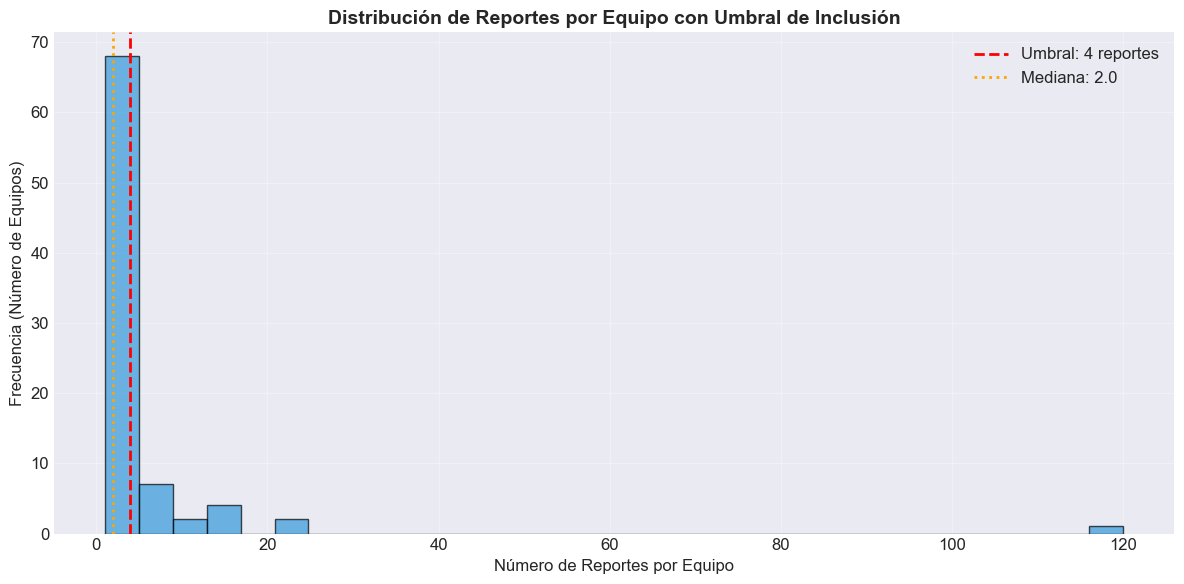


✅ Todas las columnas necesarias están disponibles
  • EQUIPO: 84 equipos únicos
  • CATEGORIA_MANIPULACION_LISTA: 370 registros con categorías

📊 CRITERIO 1: Dispositivos con al menos 4 reportes
Dispositivos que cumplen: 26 de 84 totales

🏆 Top 10 dispositivos por frecuencia:
   1. MONITOR DE SIGNOS VITALES: 120 reportes
   2. TERMOHIGRÓMETRO: 22 reportes
   3. INCUBADORA: 21 reportes
   4. FLUJÓMETRO : 16 reportes
   5. FONENDOSCOPIO: 15 reportes
   6. GENERICO: 14 reportes
   7. CUNA TÉRMICA: 13 reportes
   8. MESA DE CIRUGÍA: 12 reportes
   9. CAMA ELÉCTRICA: 10 reportes
  10. REGULADOR DE VACÍO: 8 reportes


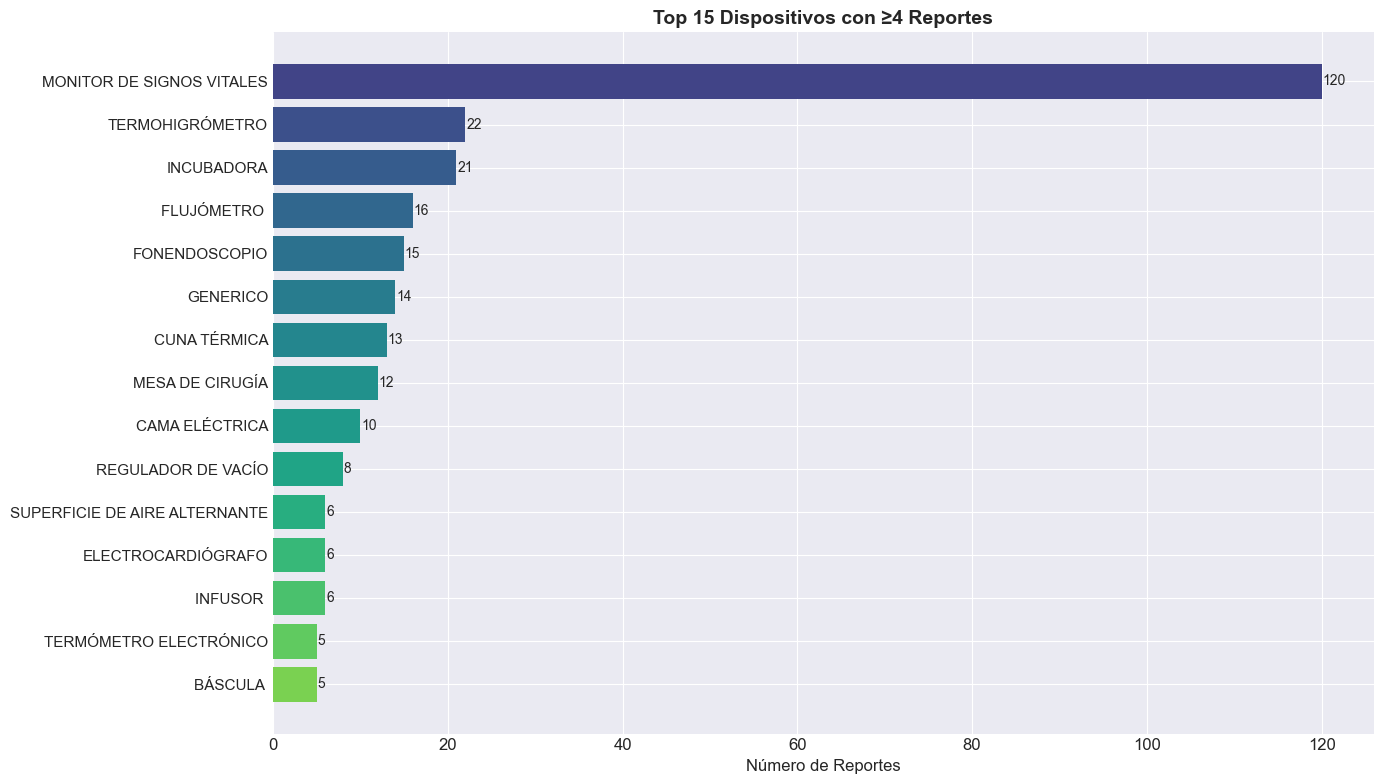


📊 CRITERIO 2: Daños por manipulación
Categorías consideradas: MAL_TRATO_FISICO, MAL_MANEJO_CABLES, MAL_USO_CONFIGURACION, MALA_LIMPIEZA_MANTENIMIENTO
Dispositivos que cumplen: 20 de 84 totales
Reportes por manipulación: 357 de 413 totales (86.4%)

🔝 Top 10 dispositivos por reportes de manipulación:
   1. MONITOR DE SIGNOS VITALES: 118 por manipulación (98.3% de 120 totales)
   2. TERMOHIGRÓMETRO: 21 por manipulación (95.5% de 22 totales)
   3. INCUBADORA: 18 por manipulación (85.7% de 21 totales)
   4. FLUJÓMETRO : 14 por manipulación (87.5% de 16 totales)
   5. CUNA TÉRMICA: 13 por manipulación (100.0% de 13 totales)
   6. GENERICO: 11 por manipulación (78.6% de 14 totales)
   7. MESA DE CIRUGÍA: 10 por manipulación (83.3% de 12 totales)
   8. CAMA ELÉCTRICA: 10 por manipulación (100.0% de 10 totales)
   9. REGULADOR DE VACÍO: 7 por manipulación (87.5% de 8 totales)
  10. SUPERFICIE DE AIRE ALTERNANTE: 6 por manipulación (100.0% de 6 totales)


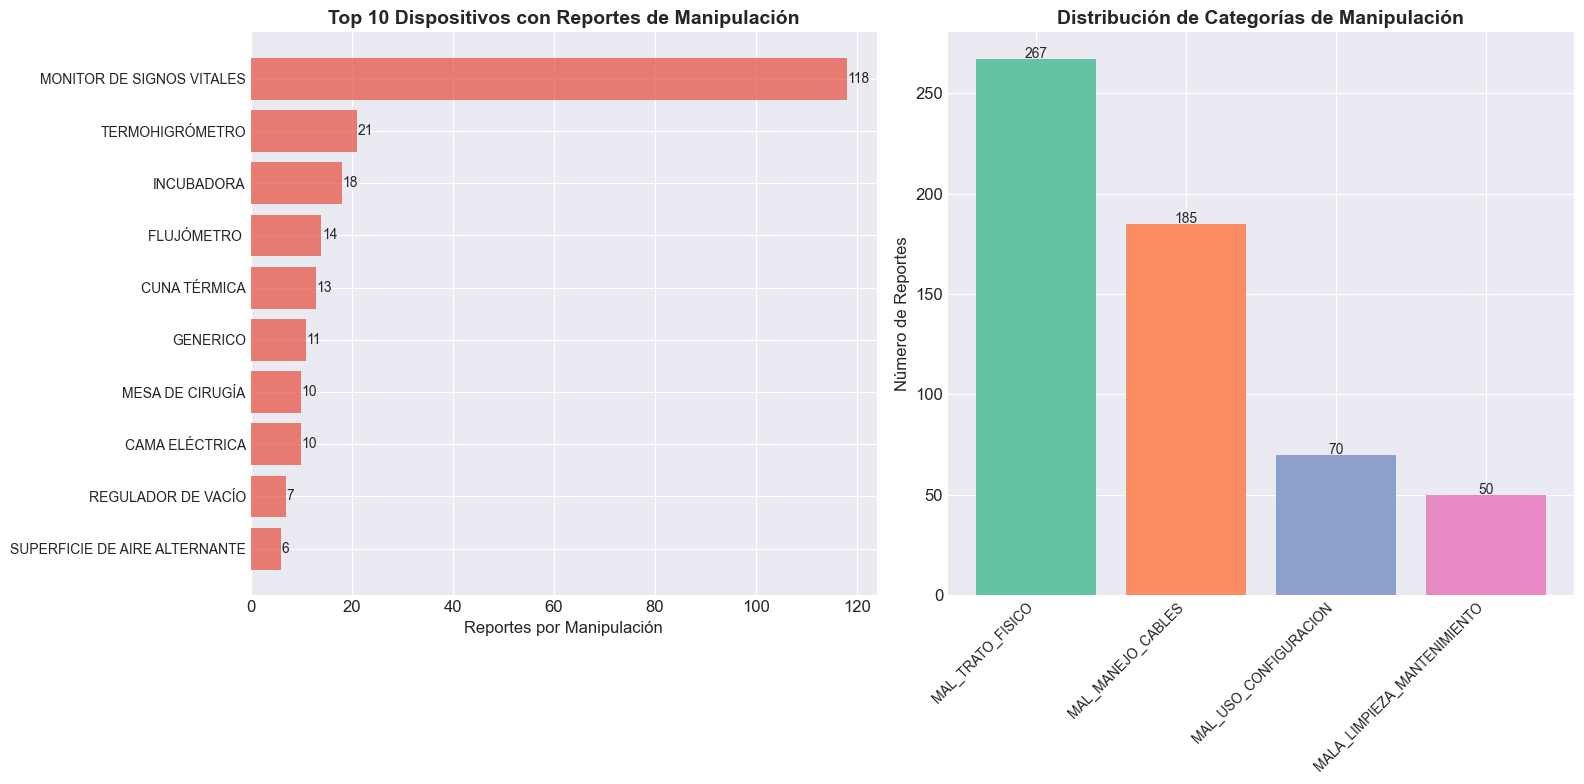


🔍 DISTRIBUCIÓN DE CATEGORÍAS EN DISPOSITIVOS CON MANIPULACIÓN:
------------------------------------------------------------

📋 MONITOR DE SIGNOS VITALES (Total reportes: 118):
  • MAL_MANEJO_CABLES: 103 veces (87.3%)
  • MAL_TRATO_FISICO: 93 veces (78.8%)
  • MAL_USO_CONFIGURACION: 24 veces (20.3%)
  • MALA_LIMPIEZA_MANTENIMIENTO: 12 veces (10.2%)

📋 TERMOHIGRÓMETRO (Total reportes: 21):
  • MAL_TRATO_FISICO: 18 veces (85.7%)
  • MAL_MANEJO_CABLES: 11 veces (52.4%)
  • MAL_USO_CONFIGURACION: 3 veces (14.3%)
  • MALA_LIMPIEZA_MANTENIMIENTO: 1 veces (4.8%)

📋 INCUBADORA (Total reportes: 18):
  • MAL_TRATO_FISICO: 13 veces (72.2%)
  • MAL_USO_CONFIGURACION: 5 veces (27.8%)
  • MAL_MANEJO_CABLES: 3 veces (16.7%)
  • MALA_LIMPIEZA_MANTENIMIENTO: 2 veces (11.1%)

📋 FLUJÓMETRO  (Total reportes: 14):
  • MAL_TRATO_FISICO: 14 veces (100.0%)
  • MALA_LIMPIEZA_MANTENIMIENTO: 4 veces (28.6%)

📋 CUNA TÉRMICA (Total reportes: 13):
  • MAL_TRATO_FISICO: 12 veces (92.3%)
  • MALA_LIMPIEZA_MANTENIMIEN

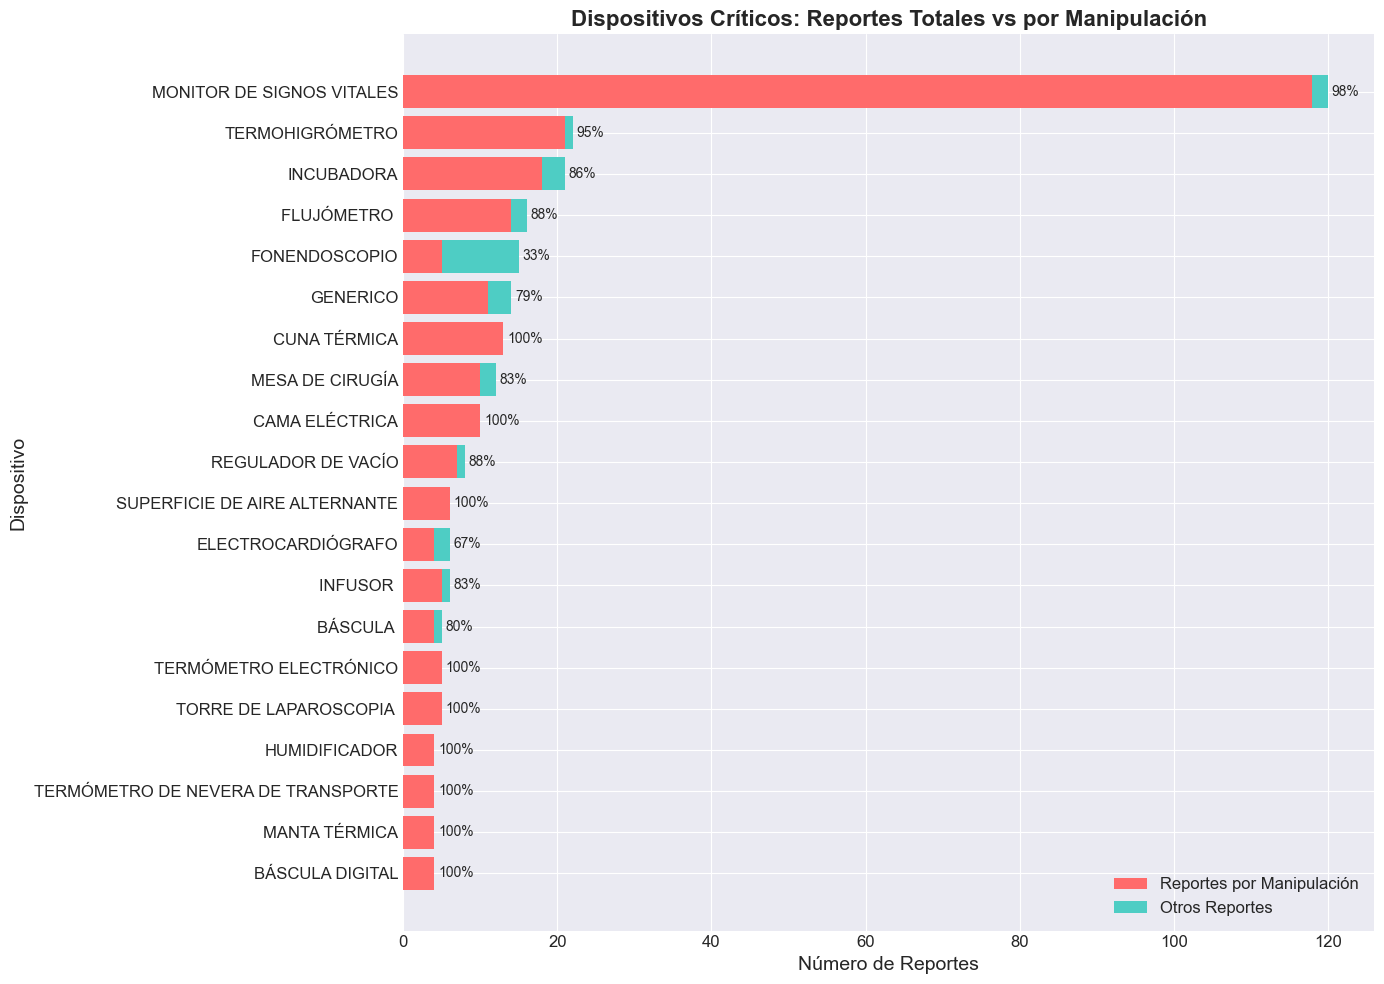


💾 Tabla exportada a: resultados/dispositivos_criticos_identificados.xlsx

📊 RESUMEN EJECUTIVO DE DISPOSITIVOS CRÍTICOS:
------------------------------------------------------------
• Total dispositivos críticos identificados: 20
• Dispositivo con más reportes: CUNA TÉRMICA (13 reportes)
• Dispositivo con mayor % de manipulación: CUNA TÉRMICA (100.0%)
• Prioridad ALTA: 19 dispositivos (>50% manipulación)
• Prioridad MEDIA: 1 dispositivos (≤50% manipulación)

🔴 DISPOSITIVOS DE ALTA PRIORIDAD (intervención urgente):
  • CUNA TÉRMICA: 13/13 (100.0%)
  • CAMA ELÉCTRICA: 10/10 (100.0%)
  • SUPERFICIE DE AIRE ALTERNANTE: 6/6 (100.0%)
  • TERMÓMETRO ELECTRÓNICO: 5/5 (100.0%)
  • TORRE DE LAPAROSCOPIA : 5/5 (100.0%)
  • TERMÓMETRO DE NEVERA DE TRANSPORTE: 4/4 (100.0%)
  • BÁSCULA DIGITAL: 4/4 (100.0%)
  • MANTA TÉRMICA: 4/4 (100.0%)
  • HUMIDIFICADOR: 4/4 (100.0%)
  • MONITOR DE SIGNOS VITALES: 118/120 (98.3%)
  • TERMOHIGRÓMETRO: 21/22 (95.5%)
  • FLUJÓMETRO : 14/16 (87.5%)
  • REGULADOR DE V

In [ ]:

print("🎯 APLICACIÓN DE CRITERIOS DE INCLUSIÓN")
print("=" * 60)

# --- VERIFICACIÓN Y USO DE CATEGORÍAS IDENTIFICADAS AUTOMÁTICAMENTE ---
# Verificar si las categorías fueron identificadas en el punto 6.5
if 'CATEGORIAS_MANIPULACION' in locals() or 'CATEGORIAS_MANIPULACION' in globals():
    print("✅ Usando categorías identificadas automáticamente del análisis 6.5")
    print(f"📋 Categorías identificadas: {', '.join(CATEGORIAS_MANIPULACION)}")
else:
    # Si por alguna razón no se identificaron, usar las categorías por defecto
    CATEGORIAS_MANIPULACION = ['MAL_TRATO_FISICO', 'MAL_USO_CONFIGURACION', 'MAL_MANEJO_CABLES']
    print("⚠️  Usando categorías por defecto (no se identificaron en 6.5)")
    print(f"📋 Categorías por defecto: {', '.join(CATEGORIAS_MANIPULACION)}")

# --- DEFINIR UMBRAL BASADO EN DATOS (DINÁMICO) ---
# Calcular umbral basado en percentil (más robusto que valor fijo)
if 'EQUIPO' in df_analisis.columns:
    frecuencia_total = df_analisis['EQUIPO'].value_counts()
    
    if len(frecuencia_total) > 0:
        # Calcular percentiles para determinar umbral
        percentil_50 = np.percentile(frecuencia_total.values, 50)  # Mediana
        percentil_75 = np.percentile(frecuencia_total.values, 75)  # Percentil 75
        
        # Usar percentil 75 o mínimo 3 reportes
        UMBRAL_REPORTES = max(3, int(percentil_75))
        
        print(f"\n📊 ANÁLISIS DE DISTRIBUCIÓN DE REPORTES:")
        print(f"  • Total de equipos únicos: {len(frecuencia_total)}")
        print(f"  • Mediana (percentil 50): {percentil_50:.1f} reportes")
        print(f"  • Percentil 75: {percentil_75:.1f} reportes")
        print(f"  • Máximo reportes: {frecuencia_total.max()} reportes")
        print(f"  • Umbral calculado: {UMBRAL_REPORTES} reportes")
        
        # Gráfico de distribución
        plt.figure(figsize=(12, 6))
        plt.hist(frecuencia_total.values, bins=30, alpha=0.7, color='#3498db', edgecolor='black')
        plt.axvline(x=UMBRAL_REPORTES, color='red', linestyle='--', linewidth=2, 
                   label=f'Umbral: {UMBRAL_REPORTES} reportes')
        plt.axvline(x=percentil_50, color='orange', linestyle=':', linewidth=2, 
                   label=f'Mediana: {percentil_50:.1f}')
        plt.xlabel('Número de Reportes por Equipo', fontsize=12)
        plt.ylabel('Frecuencia (Número de Equipos)', fontsize=12)
        plt.title('Distribución de Reportes por Equipo con Umbral de Inclusión', 
                 fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        UMBRAL_REPORTES = 5
        print(f"\n📊 Umbral por defecto: {UMBRAL_REPORTES} reportes (no hay datos suficientes)")
else:
    UMBRAL_REPORTES = 5
    print(f"\n📊 Umbral por defecto: {UMBRAL_REPORTES} reportes (columna EQUIPO no encontrada)")

# --- VERIFICAR QUE TENEMOS LAS COLUMNAS NECESARIAS ---
# Necesitamos la columna CATEGORIA_MANIPULACION_LISTA creada en 6.5
columnas_necesarias = ['EQUIPO', 'CATEGORIA_MANIPULACION_LISTA']
columnas_faltantes = [col for col in columnas_necesarias if col not in df_analisis.columns]

if columnas_faltantes:
    print(f"\n❌ ERROR: Faltan columnas necesarias: {columnas_faltantes}")
    print("  Asegúrate de que el punto 6.5 se ejecutó correctamente")
    print("  Columnas disponibles relacionadas:")
    for col in sorted(df_analisis.columns):
        if any(keyword in col.upper() for keyword in ['CATEGORIA', 'EQUIPO', 'CAUSA', 'OBSERV']):
            print(f"    • {col}")
    
    # Intentar continuar con datos disponibles
    if 'EQUIPO' not in df_analisis.columns:
        print("\n⚠️  No se puede continuar sin la columna EQUIPO")
        dispositivos_criticos = set()
        df_criticos = pd.DataFrame()
    else:
        # Continuar solo con criterio 1
        print("\n⚠️  Continuando solo con criterio 1 (frecuencia de reportes)")
        dispositivos_criticos = set()
        df_criticos = pd.DataFrame()
else:
    print(f"\n✅ Todas las columnas necesarias están disponibles")
    print(f"  • EQUIPO: {df_analisis['EQUIPO'].nunique()} equipos únicos")
    print(f"  • CATEGORIA_MANIPULACION_LISTA: {len(df_analisis[df_analisis['CATEGORIA_MANIPULACION_LISTA'].apply(len) > 0])} registros con categorías")
    
    # --- CRITERIO 1: Dispositivos con al menos UMBRAL_REPORTES reportes ---
    frecuencia_total = df_analisis['EQUIPO'].value_counts()
    dispositivos_frecuentes = frecuencia_total[frecuencia_total >= UMBRAL_REPORTES]
    
    print(f"\n📊 CRITERIO 1: Dispositivos con al menos {UMBRAL_REPORTES} reportes")
    print("=" * 50)
    print(f"Dispositivos que cumplen: {len(dispositivos_frecuentes)} de {len(frecuencia_total)} totales")
    
    if len(dispositivos_frecuentes) > 0:
        print(f"\n🏆 Top 10 dispositivos por frecuencia:")
        for i, (equipo, freq) in enumerate(dispositivos_frecuentes.head(10).items(), 1):
            print(f"  {i:2d}. {equipo}: {freq} reportes")
        
        # Gráfico de dispositivos frecuentes
        plt.figure(figsize=(14, 8))
        top_15 = dispositivos_frecuentes.head(15)
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_15)))
        bars = plt.barh(range(len(top_15)), top_15.values, color=colors)
        
        plt.yticks(range(len(top_15)), top_15.index, fontsize=11)
        plt.xlabel('Número de Reportes', fontsize=12)
        plt.title(f'Top 15 Dispositivos con ≥{UMBRAL_REPORTES} Reportes', 
                 fontsize=14, fontweight='bold')
        
        # Agregar valores en las barras
        for i, (bar, freq) in enumerate(zip(bars, top_15.values)):
            plt.text(freq + 0.1, i, str(freq), va='center', fontsize=10)
        
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️  No hay dispositivos que cumplan este criterio")
        print(f"  Considera reducir el umbral (actual: {UMBRAL_REPORTES})")
    
    # --- CRITERIO 2: Daños con causa relacionada a manipulación del personal ---
    print(f"\n📊 CRITERIO 2: Daños por manipulación")
    print("=" * 50)
    print(f"Categorías consideradas: {', '.join(CATEGORIAS_MANIPULACION)}")
    
    # Función para verificar si tiene categorías de manipulación
    def tiene_categoria_manipulacion(lista_categorias):
        """Verifica si alguna categoría en la lista está en CATEGORIAS_MANIPULACION"""
        if not isinstance(lista_categorias, list) or len(lista_categorias) == 0:
            return False
        return any(cat in CATEGORIAS_MANIPULACION for cat in lista_categorias)
    
    # Aplicar filtro
    mascara_manipulacion = df_analisis['CATEGORIA_MANIPULACION_LISTA'].apply(tiene_categoria_manipulacion)
    df_manipulacion = df_analisis[mascara_manipulacion]
    
    if len(df_manipulacion) > 0:
        frecuencia_manipulacion = df_manipulacion['EQUIPO'].value_counts()
        dispositivos_manipulacion = frecuencia_manipulacion[frecuencia_manipulacion >= UMBRAL_REPORTES]
        
        print(f"Dispositivos que cumplen: {len(dispositivos_manipulacion)} de {len(frecuencia_total)} totales")
        print(f"Reportes por manipulación: {len(df_manipulacion)} de {len(df_analisis)} totales ({len(df_manipulacion)/len(df_analisis)*100:.1f}%)")
        
        if len(dispositivos_manipulacion) > 0:
            print(f"\n🔝 Top 10 dispositivos por reportes de manipulación:")
            for i, (equipo, freq) in enumerate(dispositivos_manipulacion.head(10).items(), 1):
                total_equipo = frecuencia_total.get(equipo, 0)
                pct_manip = (freq / total_equipo * 100) if total_equipo > 0 else 0
                print(f"  {i:2d}. {equipo}: {freq} por manipulación ({pct_manip:.1f}% de {total_equipo} totales)")
            
            # Gráfico comparativo
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
            
            # Gráfico 1: Top dispositivos por manipulación
            top_manip = dispositivos_manipulacion.head(10)
            ax1.barh(range(len(top_manip)), top_manip.values, color='#e74c3c', alpha=0.7)
            ax1.set_yticks(range(len(top_manip)))
            ax1.set_yticklabels(top_manip.index, fontsize=10)
            ax1.set_xlabel('Reportes por Manipulación', fontsize=12)
            ax1.set_title('Top 10 Dispositivos con Reportes de Manipulación', fontsize=14, fontweight='bold')
            ax1.invert_yaxis()
            
            # Agregar valores
            for i, freq in enumerate(top_manip.values):
                ax1.text(freq + 0.1, i, str(freq), va='center', fontsize=10)
            
            # Gráfico 2: Distribución de categorías de manipulación
            if 'CATEGORIA_MANIPULACION_LISTA' in df_manipulacion.columns:
                # Contar categorías
                todas_categorias = []
                for cats in df_manipulacion['CATEGORIA_MANIPULACION_LISTA']:
                    # Filtrar solo categorías de manipulación
                    cats_filtradas = [cat for cat in cats if cat in CATEGORIAS_MANIPULACION]
                    todas_categorias.extend(cats_filtradas)
                
                if todas_categorias:
                    contador_cats = Counter(todas_categorias)
                    cats_series = pd.Series(contador_cats).sort_values(ascending=False)
                    
                    colors_cats = plt.cm.Set2(np.arange(len(cats_series)))
                    ax2.bar(range(len(cats_series)), cats_series.values, color=colors_cats)
                    ax2.set_xticks(range(len(cats_series)))
                    ax2.set_xticklabels(cats_series.index, rotation=45, ha='right', fontsize=10)
                    ax2.set_ylabel('Número de Reportes', fontsize=12)
                    ax2.set_title('Distribución de Categorías de Manipulación', fontsize=14, fontweight='bold')
                    
                    # Agregar valores
                    for i, freq in enumerate(cats_series.values):
                        ax2.text(i, freq + 0.5, str(freq), ha='center', fontsize=10)
            
            plt.tight_layout()
            plt.show()
            
            # Análisis detallado de categorías por equipo
            print(f"\n🔍 DISTRIBUCIÓN DE CATEGORÍAS EN DISPOSITIVOS CON MANIPULACIÓN:")
            print("-" * 60)
            
            for equipo in list(dispositivos_manipulacion.index)[:5]:
                subset = df_manipulacion[df_manipulacion['EQUIPO'] == equipo]
                categorias_equipo = []
                for cats in subset['CATEGORIA_MANIPULACION_LISTA']:
                    # Filtrar solo categorías de manipulación
                    cats_filtradas = [cat for cat in cats if cat in CATEGORIAS_MANIPULACION]
                    categorias_equipo.extend(cats_filtradas)
                
                if categorias_equipo:
                    contador = Counter(categorias_equipo)
                    print(f"\n📋 {equipo} (Total reportes: {len(subset)}):")
                    for cat, freq in contador.most_common():
                        pct = (freq / len(subset)) * 100
                        print(f"  • {cat}: {freq} veces ({pct:.1f}%)")
    else:
        print("⚠️  No se encontraron dispositivos con categorías de manipulación")
        print(f"  Verifica las categorías definidas: {CATEGORIAS_MANIPULACION}")
        dispositivos_manipulacion = pd.Series(dtype='int64')
    
    # --- DISPOSITIVOS QUE CUMPLEN AMBOS CRITERIOS ---
    dispositivos_criticos = set(dispositivos_frecuentes.index) & set(dispositivos_manipulacion.index)
    
    print(f"\n🎯 DISPOSITIVOS CRÍTICOS (cumplen ambos criterios): {len(dispositivos_criticos)}")
    print("=" * 60)
    
    if dispositivos_criticos:
        # Crear DataFrame con información detallada de dispositivos críticos
        info_criticos = []
        
        for equipo in dispositivos_criticos:
            # Información del equipo
            total_reportes = frecuencia_total[equipo]
            reportes_manipulacion = frecuencia_manipulacion.get(equipo, 0)
            
            # Obtener categorías específicas
            subset_equipo = df_manipulacion[df_manipulacion['EQUIPO'] == equipo]
            categorias_especificas = []
            for cats in subset_equipo['CATEGORIA_MANIPULACION_LISTA']:
                cats_filtradas = [cat for cat in cats if cat in CATEGORIAS_MANIPULACION]
                categorias_especificas.extend(cats_filtradas)
            
            if categorias_especificas:
                contador_cats = Counter(categorias_especificas)
                causas_str = ", ".join([f"{causa} ({freq})" for causa, freq in contador_cats.most_common(3)])
            else:
                causas_str = "No especificadas"
            
            # Obtener áreas más afectadas
            if 'SERVICI' in df_analisis.columns:
                areas = df_analisis[df_analisis['EQUIPO'] == equipo]['SERVICI'].value_counts().head(3)
                areas_str = ", ".join([f"{area} ({freq})" for area, freq in areas.items()])
            elif 'UBICA' in df_analisis.columns:
                areas = df_analisis[df_analisis['EQUIPO'] == equipo]['UBICA'].value_counts().head(3)
                areas_str = ", ".join([f"{area} ({freq})" for area, freq in areas.items()])
            else:
                areas_str = "No disponible"
            
            # Obtener ejemplo de observación
            if 'OBSERV' in df_analisis.columns:
                ejemplo_obs = df_analisis[(df_analisis['EQUIPO'] == equipo) & 
                                         (df_analisis['OBSERV'].notna())]['OBSERV'].iloc[0] \
                                         if not df_analisis[(df_analisis['EQUIPO'] == equipo) & 
                                                           (df_analisis['OBSERV'].notna())].empty else ""
                # Limitar longitud
                if len(str(ejemplo_obs)) > 100:
                    ejemplo_obs = str(ejemplo_obs)[:100] + "..."
            else:
                ejemplo_obs = "No disponible"
            
            info_criticos.append({
                'EQUIPO': equipo,
                'TOTAL_REPORTES': total_reportes,
                'REPORTES_MANIPULACION': reportes_manipulacion,
                '%_MANIPULACION': (reportes_manipulacion / total_reportes) * 100 if total_reportes > 0 else 0,
                'CATEGORIAS_PRINCIPALES': causas_str,
                'AREAS_AFECTADAS': areas_str,
                'EJEMPLO_OBSERVACION': ejemplo_obs,
                'PRIORIDAD': 'ALTA' if (reportes_manipulacion / total_reportes) > 0.5 else 'MEDIA'
            })
        
        # Convertir a DataFrame y ordenar
        df_criticos = pd.DataFrame(info_criticos)
        df_criticos = df_criticos.sort_values(['%_MANIPULACION', 'TOTAL_REPORTES'], ascending=False)
        
        # Mostrar tabla
        print("\n📋 TABLA DE DISPOSITIVOS CRÍTICOS (prioridad de intervención):")
        print("-" * 80)
        print(df_criticos.to_string(index=False))
        
        # Gráfico de dispositivos críticos
        plt.figure(figsize=(14, 10))
        
        # Preparar datos para gráfico
        df_grafico = df_criticos.copy()
        df_grafico = df_grafico.sort_values('TOTAL_REPORTES')
        
        # Gráfico de barras apiladas
        x = np.arange(len(df_grafico))
        width = 0.6
        
        plt.barh(df_grafico['EQUIPO'], df_grafico['REPORTES_MANIPULACION'], 
                label='Reportes por Manipulación', color='#FF6B6B')
        plt.barh(df_grafico['EQUIPO'], df_grafico['TOTAL_REPORTES'] - df_grafico['REPORTES_MANIPULACION'], 
                left=df_grafico['REPORTES_MANIPULACION'], 
                label='Otros Reportes', color='#4ECDC4')
        
        plt.title('Dispositivos Críticos: Reportes Totales vs por Manipulación', 
                 fontsize=16, fontweight='bold')
        plt.xlabel('Número de Reportes', fontsize=14)
        plt.ylabel('Dispositivo', fontsize=14)
        plt.legend()
        
        # Agregar porcentajes
        for i, row in enumerate(df_grafico.itertuples()):
            pct = (row.REPORTES_MANIPULACION / row.TOTAL_REPORTES) * 100
            plt.text(row.TOTAL_REPORTES + 0.5, i, f"{pct:.0f}%", va='center', fontsize=10)
        
        plt.tight_layout()
        plt.show()
        
        # Exportar a Excel
        nombre_archivo_criticos = 'resultados/dispositivos_criticos_identificados.xlsx'
        df_criticos.to_excel(nombre_archivo_criticos, index=False)
        print(f"\n💾 Tabla exportada a: {nombre_archivo_criticos}")
        
        # Resumen ejecutivo
        print(f"\n📊 RESUMEN EJECUTIVO DE DISPOSITIVOS CRÍTICOS:")
        print("-" * 60)
        print(f"• Total dispositivos críticos identificados: {len(df_criticos)}")
        print(f"• Dispositivo con más reportes: {df_criticos.iloc[0]['EQUIPO']} ({df_criticos.iloc[0]['TOTAL_REPORTES']} reportes)")
        print(f"• Dispositivo con mayor % de manipulación: {df_criticos.iloc[0]['EQUIPO']} ({df_criticos.iloc[0]['%_MANIPULACION']:.1f}%)")
        
        # Prioridades
        alta_prioridad = df_criticos[df_criticos['PRIORIDAD'] == 'ALTA']
        media_prioridad = df_criticos[df_criticos['PRIORIDAD'] == 'MEDIA']
        
        print(f"• Prioridad ALTA: {len(alta_prioridad)} dispositivos (>50% manipulación)")
        print(f"• Prioridad MEDIA: {len(media_prioridad)} dispositivos (≤50% manipulación)")
        
        if len(alta_prioridad) > 0:
            print(f"\n🔴 DISPOSITIVOS DE ALTA PRIORIDAD (intervención urgente):")
            for _, row in alta_prioridad.iterrows():
                print(f"  • {row['EQUIPO']}: {row['REPORTES_MANIPULACION']}/{row['TOTAL_REPORTES']} ({row['%_MANIPULACION']:.1f}%)")
        
    else:
        print("⚠️  No se encontraron dispositivos que cumplan ambos criterios")
        print("\n💡 RECOMENDACIONES:")
        print("  1. Reducir el umbral de reportes (actual: {UMBRAL_REPORTES})")
        print(f"  2. Revisar las categorías de manipulación: {CATEGORIAS_MANIPULACION}")
        print("  3. Verificar la calidad de los datos en OBSERV")
        
        df_criticos = pd.DataFrame()

print("\n✅ ANÁLISIS DE CRITERIOS DE INCLUSIÓN COMPLETADO")

# ## 8. Análisis temporal (si hay datos de fecha)

ANÁLISIS TEMPORAL DE REPORTES


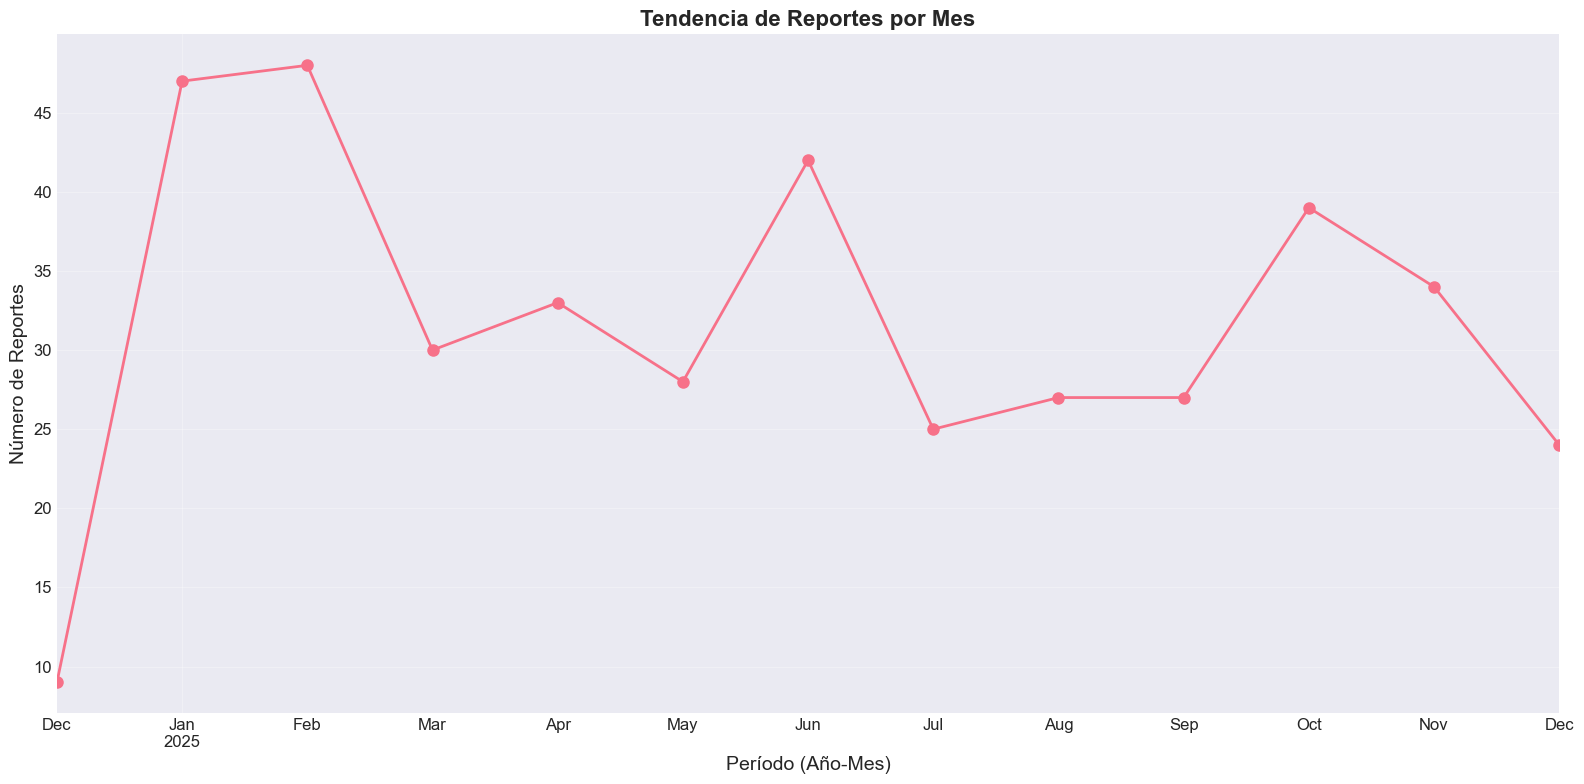


TENDENCIA TEMPORAL DE DISPOSITIVOS CRÍTICOS:
--------------------------------------------------


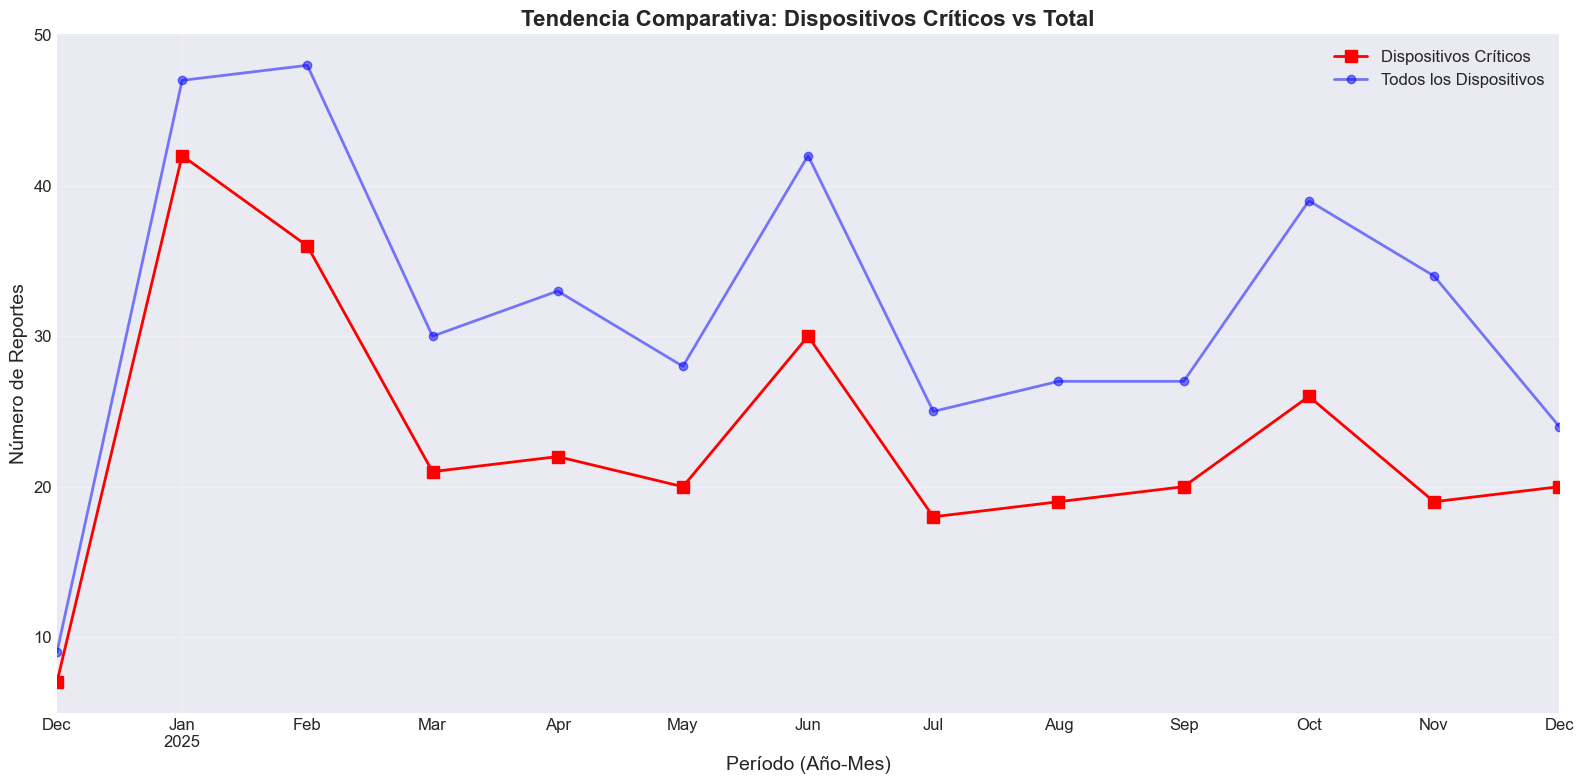

• Correlación entre reportes totales y críticos: 0.940
  → Alta correlación: Los críticos siguen la tendencia general


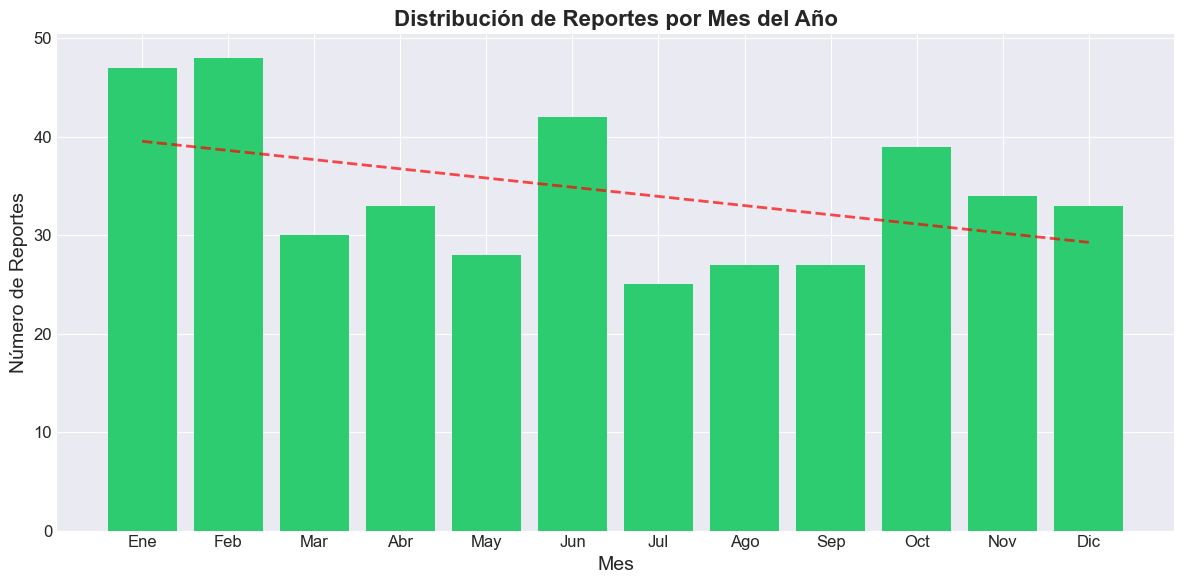

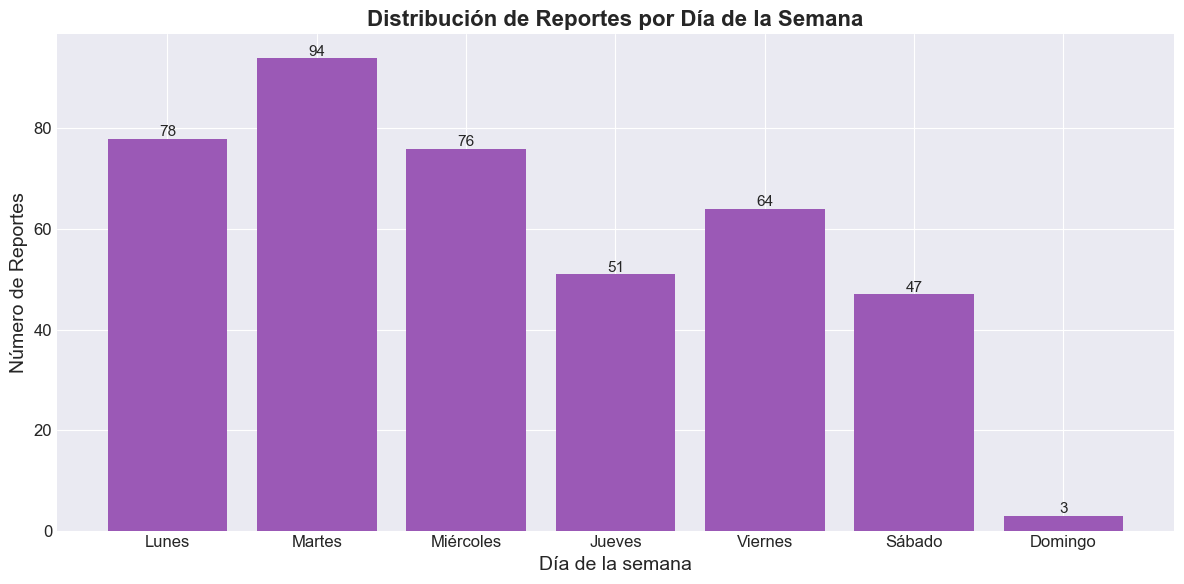


RESUMEN TEMPORAL:
• Mes con más reportes: 2025-02 (48 reportes)
• Mes con menos reportes: 2024-12 (9 reportes)
• Promedio mensual: 31.8 reportes
• Desviación estándar: 10.6 reportes
Análisis temporal exportado a: resultados/analisis_temporal.xlsx


In [30]:
print("ANÁLISIS TEMPORAL DE REPORTES")
print("=" * 50)

if 'FECCRE' in df_analisis.columns:
    # Extraer año y mes
    df_analisis['AÑO'] = df_analisis['FECCRE'].dt.year
    df_analisis['MES'] = df_analisis['FECCRE'].dt.month
    df_analisis['AÑO_MES'] = df_analisis['FECCRE'].dt.to_period('M')
    
    # Análisis por mes
    reportes_por_mes = df_analisis['AÑO_MES'].value_counts().sort_index()
    
    # Gráfico 1: Tendencia temporal general
    plt.figure(figsize=(16, 8))
    reportes_por_mes.plot(marker='o', linewidth=2, markersize=8)
    plt.title('Tendencia de Reportes por Mes', fontsize=16, fontweight='bold')
    plt.xlabel('Período (Año-Mes)', fontsize=14)
    plt.ylabel('Número de Reportes', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Análisis de tendencia para dispositivos críticos
    if 'df_criticos' in locals() and len(df_criticos) > 0:
        print("\nTENDENCIA TEMPORAL DE DISPOSITIVOS CRÍTICOS:")
        print("-" * 50)
        
        # Filtrar solo dispositivos críticos
        if 'EQUIPO' in df_analisis.columns:
            dispositivos_criticos_lista = df_criticos['EQUIPO'].tolist()
            df_criticos_temporal = df_analisis[df_analisis['EQUIPO'].isin(dispositivos_criticos_lista)]
            
            if len(df_criticos_temporal) > 0:
                reportes_criticos_mes = df_criticos_temporal['AÑO_MES'].value_counts().sort_index()
                
                plt.figure(figsize=(16, 8))
                reportes_criticos_mes.plot(marker='s', linewidth=2, markersize=8, color='red', label='Dispositivos Críticos')
                reportes_por_mes.plot(marker='o', linewidth=2, markersize=6, color='blue', alpha=0.5, label='Todos los Dispositivos')
                plt.title('Tendencia Comparativa: Dispositivos Críticos vs Total', fontsize=16, fontweight='bold')
                plt.xlabel('Período (Año-Mes)', fontsize=14)
                plt.ylabel('Número de Reportes', fontsize=14)
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
                # Calcular correlación
                df_comparacion = pd.DataFrame({
                    'Total': reportes_por_mes,
                    'Críticos': reportes_criticos_mes
                }).fillna(0)
                
                correlacion = df_comparacion['Total'].corr(df_comparacion['Críticos'])
                print(f"• Correlación entre reportes totales y críticos: {correlacion:.3f}")
                if correlacion > 0.7:
                    print("  → Alta correlación: Los críticos siguen la tendencia general")
                elif correlacion > 0.3:
                    print("  → Correlación moderada")
                else:
                    print("  → Baja correlación: Los críticos tienen patrón diferente")
    
    # Análisis estacional por mes (sin año)
    reportes_por_mes_num = df_analisis['MES'].value_counts().sort_index()
    meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(1, 13), [reportes_por_mes_num.get(i, 0) for i in range(1, 13)], color='#2ecc71')
    plt.xticks(range(1, 13), meses_nombres)
    plt.title('Distribución de Reportes por Mes del Año', fontsize=16, fontweight='bold')
    plt.xlabel('Mes', fontsize=14)
    plt.ylabel('Número de Reportes', fontsize=14)
    
    # Agregar línea de tendencia
    x = list(range(1, 13))
    y = [reportes_por_mes_num.get(i, 0) for i in x]
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), "r--", alpha=0.7, linewidth=2)
    
    plt.tight_layout()
    plt.show()
    
    # Análisis por día de la semana
    if 'FECCRE' in df_analisis.columns:
        df_analisis['DIA_SEMANA'] = df_analisis['FECCRE'].dt.day_name()
        df_analisis['DIA_SEMANA_NUM'] = df_analisis['FECCRE'].dt.dayofweek
        
        dias_orden = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        dias_esp = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
        
        reportes_por_dia = df_analisis['DIA_SEMANA'].value_counts()
        reportes_por_dia = reportes_por_dia.reindex(dias_orden)
        
        plt.figure(figsize=(12, 6))
        plt.bar(range(7), reportes_por_dia.values, color='#9b59b6')
        plt.xticks(range(7), dias_esp)
        plt.title('Distribución de Reportes por Día de la Semana', fontsize=16, fontweight='bold')
        plt.xlabel('Día de la semana', fontsize=14)
        plt.ylabel('Número de Reportes', fontsize=14)
        
        # Agregar valores
        for i, valor in enumerate(reportes_por_dia.values):
            plt.text(i, valor + 0.5, str(valor), ha='center', fontsize=11)
        
        plt.tight_layout()
        plt.show()
    
    print(f"\nRESUMEN TEMPORAL:")
    print(f"• Mes con más reportes: {reportes_por_mes.idxmax()} ({reportes_por_mes.max()} reportes)")
    print(f"• Mes con menos reportes: {reportes_por_mes.idxmin()} ({reportes_por_mes.min()} reportes)")
    print(f"• Promedio mensual: {reportes_por_mes.mean():.1f} reportes")
    print(f"• Desviación estándar: {reportes_por_mes.std():.1f} reportes")
    
    # Exportar datos temporales
    df_temporal = df_analisis[['FECCRE', 'AÑO', 'MES', 'DIA_SEMANA', 'EQUIPO', 'CATEGORIA_MANIPULACION']].copy()
    df_temporal.to_excel('resultados/analisis_temporal.xlsx', index=False)
    print("Análisis temporal exportado a: resultados/analisis_temporal.xlsx")
    
else:
    print("No se encontró columna de fecha (FECCRE) para análisis temporal")


# ## 9. Matriz de clasificación de daños

MATRIZ DE CLASIFICACIÓN DE DAÑOS MEJORADA
🔝 Analizando 20 dispositivos críticos identificados

Matriz de clasificación creada:
• Equipos analizados: 20
• Categorías identificadas: 4
• Total de relaciones mapeadas: 443

TOP 5 RELACIONES EQUIPO-CATEGORÍA:
 1. MONITOR DE SIGNOS VITALES                → MAL_MANEJO_CABLES        : 103 reportes
 2. MONITOR DE SIGNOS VITALES                → MAL_TRATO_FISICO         :  93 reportes
 3. MONITOR DE SIGNOS VITALES                → MAL_USO_CONFIGURACION    :  24 reportes
 4. TERMOHIGRÓMETRO                          → MAL_TRATO_FISICO         :  18 reportes
 5. FLUJÓMETRO                               → MAL_TRATO_FISICO         :  14 reportes
 6. INCUBADORA                               → MAL_TRATO_FISICO         :  13 reportes
 7. CUNA TÉRMICA                             → MAL_TRATO_FISICO         :  12 reportes
 8. MONITOR DE SIGNOS VITALES                → MALA_LIMPIEZA_MANTENIMIENTO:  12 reportes
 9. TERMOHIGRÓMETRO                          → M

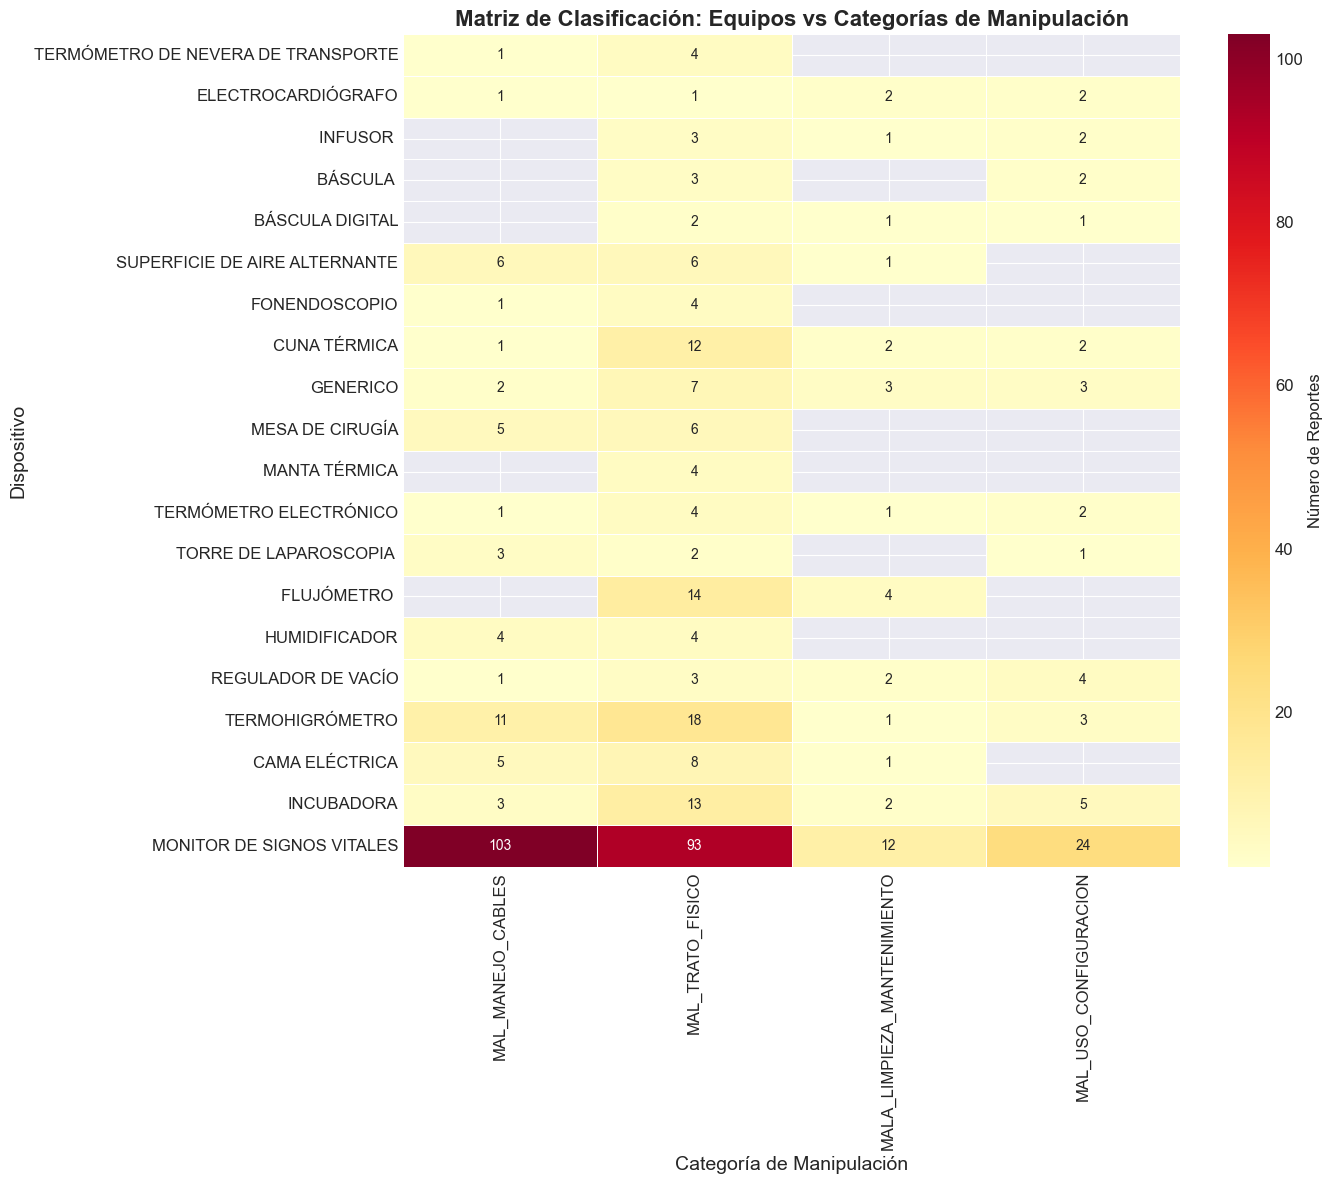


PATRONES IDENTIFICADOS:
----------------------------------------

🏆 CATEGORÍAS MÁS FRECUENTES:
  1. MAL_TRATO_FISICO: 211 reportes en 20 equipos
  2. MAL_MANEJO_CABLES: 148 reportes en 15 equipos
  3. MAL_USO_CONFIGURACION: 51 reportes en 12 equipos
  4. MALA_LIMPIEZA_MANTENIMIENTO: 33 reportes en 13 equipos

🎯 EQUIPOS CON MÁS DIVERSIDAD DE PROBLEMAS:
  1. ELECTROCARDIÓGRAFO: 4 categorías diferentes, 6 reportes totales
  2. TERMÓMETRO ELECTRÓNICO: 4 categorías diferentes, 8 reportes totales
  3. GENERICO: 4 categorías diferentes, 15 reportes totales
  4. CUNA TÉRMICA: 4 categorías diferentes, 17 reportes totales
  5. TERMOHIGRÓMETRO: 4 categorías diferentes, 33 reportes totales

🔗 CORRELACIONES ENTRE CATEGORÍAS:
  • MAL_MANEJO_CABLES ↔ MAL_TRATO_FISICO: 0.98
    → Tienden a ocurrir juntas
  • MAL_MANEJO_CABLES ↔ MAL_USO_CONFIGURACION: 0.95
    → Tienden a ocurrir juntas
  • MAL_TRATO_FISICO ↔ MAL_USO_CONFIGURACION: 0.95
    → Tienden a ocurrir juntas

Matrices exportadas:
  • resultad

In [31]:
print("MATRIZ DE CLASIFICACIÓN DE DAÑOS MEJORADA")
print("=" * 60)

if 'EQUIPO' in df_analisis.columns and 'CATEGORIA_MANIPULACION_LISTA' in df_analisis.columns:
    # Filtrar equipos que cumplen criterios de inclusión
    if 'dispositivos_criticos' in locals() and len(dispositivos_criticos) > 0:
        equipos_prioritarios = list(dispositivos_criticos)
        print(f"🔝 Analizando {len(equipos_prioritarios)} dispositivos críticos identificados")
    else:
        # Si no hay críticos, usar top 20 por frecuencia
        frecuencia_total = df_analisis['EQUIPO'].value_counts()
        equipos_prioritarios = frecuencia_total.head(20).index.tolist()
        print(f"🔝 Analizando top {len(equipos_prioritarios)} dispositivos por frecuencia")
    
    # Crear matriz de clasificación mejorada
    categorias_unicas = []
    for cats in df_analisis['CATEGORIA_MANIPULACION_LISTA']:
        if isinstance(cats, list):
            # Filtrar solo categorías de manipulación si están definidas
            if 'CATEGORIAS_MANIPULACION' in locals():
                cats_filtradas = [cat for cat in cats if cat in CATEGORIAS_MANIPULACION]
            else:
                cats_filtradas = cats
            categorias_unicas.extend(cats_filtradas)
    
    categorias_unicas = list(set([cat for cat in categorias_unicas if cat]))
    
    if categorias_unicas and equipos_prioritarios:
        # Crear DataFrame vacío para la matriz
        matriz_clasificacion = pd.DataFrame(0, index=equipos_prioritarios, columns=categorias_unicas)
        
        # Llenar matriz manualmente
        for equipo in equipos_prioritarios:
            subset = df_analisis[df_analisis['EQUIPO'] == equipo]
            for _, row in subset.iterrows():
                cats = row['CATEGORIA_MANIPULACION_LISTA']
                if isinstance(cats, list):
                    for cat in cats:
                        if cat in categorias_unicas:
                            matriz_clasificacion.at[equipo, cat] += 1
        
        # Filtrar solo columnas y filas con datos
        matriz_filtrada = matriz_clasificacion.loc[(matriz_clasificacion.sum(axis=1) > 0), 
                                                  (matriz_clasificacion.sum(axis=0) > 0)]
        
        print(f"\nMatriz de clasificación creada:")
        print(f"• Equipos analizados: {matriz_filtrada.shape[0]}")
        print(f"• Categorías identificadas: {matriz_filtrada.shape[1]}")
        print(f"• Total de relaciones mapeadas: {matriz_filtrada.sum().sum()}")
        
        if not matriz_filtrada.empty and matriz_filtrada.shape[0] > 1 and matriz_filtrada.shape[1] > 1:
            # Mostrar resumen
            print("\nTOP 5 RELACIONES EQUIPO-CATEGORÍA:")
            relaciones = []
            for equipo in matriz_filtrada.index:
                for categoria in matriz_filtrada.columns:
                    valor = matriz_filtrada.at[equipo, categoria]
                    if valor > 0:
                        relaciones.append((equipo, categoria, valor))
            
            # Ordenar y mostrar top 10
            relaciones.sort(key=lambda x: x[2], reverse=True)
            for i, (equipo, categoria, valor) in enumerate(relaciones[:10], 1):
                print(f"{i:2d}. {equipo[:40]:40} → {categoria:25}: {valor:3d} reportes")
            
            # Gráfico de calor
            plt.figure(figsize=(max(14, matriz_filtrada.shape[1] * 0.8), 
                              max(10, matriz_filtrada.shape[0] * 0.6)))
            
            # Crear máscara para valores 0 (opcional, más limpio)
            mask = matriz_filtrada == 0
            
            sns.heatmap(matriz_filtrada, annot=True, fmt='d', cmap='YlOrRd', 
                       linewidths=0.5, cbar_kws={'label': 'Número de Reportes'},
                       mask=mask, annot_kws={'size': 10})
            
            plt.title('Matriz de Clasificación: Equipos vs Categorías de Manipulación', 
                     fontsize=16, fontweight='bold')
            plt.xlabel('Categoría de Manipulación', fontsize=14)
            plt.ylabel('Dispositivo', fontsize=14)
            plt.tight_layout()
            plt.show()
            
            # Análisis de patrones
            print("\nPATRONES IDENTIFICADOS:")
            print("-" * 40)
            
            # 1. Categorías más frecuentes en general
            categorias_totales = matriz_filtrada.sum(axis=0).sort_values(ascending=False)
            print(f"\n🏆 CATEGORÍAS MÁS FRECUENTES:")
            for i, (categoria, total) in enumerate(categorias_totales.head(5).items(), 1):
                equipos_con_cat = (matriz_filtrada[categoria] > 0).sum()
                print(f"  {i}. {categoria}: {total} reportes en {equipos_con_cat} equipos")
            
            # 2. Equipos con más categorías diferentes
            equipos_diversos = (matriz_filtrada > 0).sum(axis=1).sort_values(ascending=False)
            print(f"\n🎯 EQUIPOS CON MÁS DIVERSIDAD DE PROBLEMAS:")
            for i, (equipo, num_cats) in enumerate(equipos_diversos.head(5).items(), 1):
                total_reportes = matriz_filtrada.loc[equipo].sum()
                print(f"  {i}. {equipo}: {num_cats} categorías diferentes, {total_reportes} reportes totales")
            
            # 3. Correlaciones entre categorías
            print(f"\n🔗 CORRELACIONES ENTRE CATEGORÍAS:")
            # Calcular correlación solo si hay suficientes datos
            if matriz_filtrada.shape[1] >= 2:
                correlaciones = matriz_filtrada.corr()
                # Encontrar las correlaciones más altas (excluyendo diagonal)
                correlaciones_altas = []
                for i in range(len(correlaciones.columns)):
                    for j in range(i+1, len(correlaciones.columns)):
                        cat1 = correlaciones.columns[i]
                        cat2 = correlaciones.columns[j]
                        corr = correlaciones.iloc[i, j]
                        if abs(corr) > 0.5:  # Solo mostrar correlaciones fuertes
                            correlaciones_altas.append((cat1, cat2, corr))
                
                if correlaciones_altas:
                    correlaciones_altas.sort(key=lambda x: abs(x[2]), reverse=True)
                    for cat1, cat2, corr in correlaciones_altas[:3]:
                        print(f"  • {cat1} ↔ {cat2}: {corr:.2f}")
                        if corr > 0:
                            print(f"    → Tienden a ocurrir juntas")
                        else:
                            print(f"    → Tienden a ser mutuamente excluyentes")
                else:
                    print("  No se encontraron correlaciones fuertes (>0.5) entre categorías")
            
            # Exportar matriz
            matriz_filtrada.to_excel('resultados/matriz_clasificacion_detallada.xlsx')
            
            # Exportar también una versión con porcentajes
            matriz_porcentajes = matriz_filtrada.div(matriz_filtrada.sum(axis=1), axis=0) * 100
            matriz_porcentajes.to_excel('resultados/matriz_clasificacion_porcentajes.xlsx')
            
            print(f"\nMatrices exportadas:")
            print(f"  • resultados/matriz_clasificacion_detallada.xlsx")
            print(f"  • resultados/matriz_clasificacion_porcentajes.xlsx")
            
        else:
            print("La matriz es demasiado pequeña o vacía para análisis detallado")
            
    else:
        print("No hay suficientes categorías o equipos para crear la matriz")
        
else:
    print("No se pudo crear la matriz: faltan columnas necesarias")

# ## 10. Análisis económico preliminar

In [32]:
print("ANÁLISIS ECONÓMICO PRELIMINAR")
print("=" * 50)

# Nota: Este análisis es preliminar, para análisis económico completo
# se necesitarían datos de costos de reparación

# Verificar si tenemos información de repuestos
if 'Repuestos' in ''.join(df_analisis.columns):
    # Buscar columna que contenga información de repuestos
    col_repuestos = [col for col in df_analisis.columns if 'repuest' in col.lower() or 'repuesto' in col.lower()]
    
    if col_repuestos:
        col_rep = col_repuestos[0]
        print(f"Analizando columna: {col_rep}")
        
        # Limpiar y estandarizar valores
        df_analisis['REPUESTO_LIMPIO'] = df_analisis[col_rep].astype(str).str.lower().str.strip()
        
        # Categorizar
        def categorizar_repuesto(texto):
            texto = str(texto).lower()
            if any(palabra in texto for palabra in ['si', 'sí', 'yes', 'true', '1', 'requiere']):
                return 'CON_REPUESTO'
            elif any(palabra in texto for palabra in ['no', 'false', '0', 'no requiere', 'n/a']):
                return 'SIN_REPUESTO'
            else:
                return 'NO_ESPECIFICADO'
        
        df_analisis['CATEGORIA_REPUESTO'] = df_analisis['REPUESTO_LIMPIO'].apply(categorizar_repuesto)
        
        # Análisis de frecuencia
        distribucion_repuestos = df_analisis['CATEGORIA_REPUESTO'].value_counts()
        
        print(f"\nDISTRIBUCIÓN DE REPORTES CON/SIN REPUESTOS:")
        for categoria, frecuencia in distribucion_repuestos.items():
            porcentaje = (frecuencia / len(df_analisis)) * 100
            print(f"  • {categoria}: {frecuencia} reportes ({porcentaje:.1f}%)")
        
        # Análisis por dispositivo crítico
        if 'df_criticos' in locals() and len(df_criticos) > 0:
            dispositivos_criticos_lista = df_criticos['EQUIPO'].tolist()
            df_criticos_data = df_analisis[df_analisis['EQUIPO'].isin(dispositivos_criticos_lista)]
            
            if len(df_criticos_data) > 0:
                print(f"\nANÁLISIS PARA DISPOSITIVOS CRÍTICOS ({len(dispositivos_criticos_lista)} dispositivos):")
                
                repuestos_criticos = df_criticos_data['CATEGORIA_REPUESTO'].value_counts()
                for categoria, frecuencia in repuestos_criticos.items():
                    porcentaje = (frecuencia / len(df_criticos_data)) * 100
                    print(f"  • {categoria}: {frecuencia} reportes ({porcentaje:.1f}%)")
                
                # Comparación
                pct_repuestos_criticos = (repuestos_criticos.get('CON_REPUESTO', 0) / len(df_criticos_data)) * 100
                pct_repuestos_totales = (distribucion_repuestos.get('CON_REPUESTO', 0) / len(df_analisis)) * 100
                
                print(f"\nCOMPARACIÓN:")
                print(f"  • Dispositivos críticos con repuestos: {pct_repuestos_criticos:.1f}%")
                print(f"  • Total dispositivos con repuestos: {pct_repuestos_totales:.1f}%")
                
                if pct_repuestos_criticos > pct_repuestos_totales:
                    print(f"  → Los dispositivos críticos requieren MÁS repuestos (+{pct_repuestos_criticos - pct_repuestos_totales:.1f}%)")
                else:
                    print(f"  → Los dispositivos críticos requieren MENOS repuestos ({pct_repuestos_criticos - pct_repuestos_totales:.1f}%)")
        
        # Gráfico
        plt.figure(figsize=(10, 6))
        colors = ['#e74c3c', '#2ecc71', '#95a5a6']  # Rojo: con repuesto, Verde: sin, Gris: no especificado
        plt.pie(distribucion_repuestos.values, labels=distribucion_repuestos.index, 
                autopct='%1.1f%%', colors=colors, startangle=90)
        plt.title('Distribución de Reportes por Necesidad de Repuestos', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Estimación económica muy básica (solo para ilustración)
        print(f"\nESTIMACIÓN ECONÓMICA PRELIMINAR:")
        print("  (Basada en suposiciones - requiere datos reales de costos)")
        
        # Suposiciones para ilustración
        COSTO_PROMEDIO_REPUESTO = 500000  # $500,000 COP por repuesto (ajustar)
        COSTO_MANO_OBRA = 150000  # $150,000 COP por reparación
        
        reportes_con_repuesto = distribucion_repuestos.get('CON_REPUESTO', 0)
        costo_estimado_repuestos = reportes_con_repuesto * COSTO_PROMEDIO_REPUESTO
        costo_estimado_mano_obra = len(df_analisis) * COSTO_MANO_OBRA
        costo_total_estimado = costo_estimado_repuestos + costo_estimado_mano_obra
        
        print(f"  • Reportes que requieren repuestos: {reportes_con_repuesto}")
        print(f"  • Costo estimado repuestos: ${costo_estimado_repuestos:,.0f} COP")
        print(f"  • Costo estimado mano de obra: ${costo_estimado_mano_obra:,.0f} COP")
        print(f"  • Costo total estimado: ${costo_total_estimado:,.0f} COP")
        
        if 'df_criticos' in locals() and len(df_criticos) > 0:
            reportes_criticos_con_repuesto = repuestos_criticos.get('CON_REPUESTO', 0)
            costo_criticos_repuestos = reportes_criticos_con_repuesto * COSTO_PROMEDIO_REPUESTO
            costo_criticos_mano_obra = len(df_criticos_data) * COSTO_MANO_OBRA
            costo_criticos_total = costo_criticos_repuestos + costo_criticos_mano_obra
            
            print(f"\nCOSTO ESTIMADO DISPOSITIVOS CRÍTICOS:")
            print(f"  • Reportes críticos con repuestos: {reportes_criticos_con_repuesto}")
            print(f"  • Costo estimado repuestos: ${costo_criticos_repuestos:,.0f} COP")
            print(f"  • Costo estimado mano de obra: ${costo_criticos_mano_obra:,.0f} COP")
            print(f"  • Costo total estimado: ${costo_criticos_total:,.0f} COP")
            print(f"  • % del costo total: {(costo_criticos_total / costo_total_estimado * 100):.1f}%")
            
            # Potencial ahorro
            print(f"\nPOTENCIAL AHORRO CON INTERVENCIÓN:")
            print(f"  Suponiendo reducción del 30% en dispositivos críticos:")
            ahorro_estimado = costo_criticos_total * 0.3
            print(f"  • Ahorro estimado: ${ahorro_estimado:,.0f} COP anual")
            print(f"  • ROI potencial: {(ahorro_estimado / (len(dispositivos_criticos_lista) * 100000)):.1f}x")
            print(f"    (Inversión estimada: $100,000 COP por dispositivo en capacitación)")
        
        # Exportar análisis
        df_repuestos = df_analisis[['EQUIPO', 'CATEGORIA_REPUESTO', 'CATEGORIA_MANIPULACION']].copy()
        df_repuestos.to_excel('resultados/analisis_repuestos.xlsx', index=False)
        print(f"\nAnálisis de repuestos exportado a: resultados/analisis_repuestos.xlsx")
        
    else:
        print("No se encontró información específica de repuestos")
        print("  Columnas disponibles:", [col for col in df_analisis.columns if 'repuest' in col.lower()])
else:
    print("No se encontró información de repuestos en los datos")
    print("  Para análisis económico completo, se necesitan:")
    print("  1. Costos reales de repuestos")
    print("  2. Costos de mano de obra")
    print("  3. Tiempos de indisponibilidad")
    print("  4. Costos de oportunidad")

ANÁLISIS ECONÓMICO PRELIMINAR
No se encontró información de repuestos en los datos
  Para análisis económico completo, se necesitan:
  1. Costos reales de repuestos
  2. Costos de mano de obra
  3. Tiempos de indisponibilidad
  4. Costos de oportunidad


# ## 11. Resumen ejecutivo y recomendaciones

In [33]:
print("RESUMEN EJECUTIVO - FASE 1: DIAGNÓSTICO COMPLETO")
print("=" * 70)

# Generar resumen automático
resumen = {
    "Total de órdenes analizadas": len(df_analisis),
    "Período cubierto": f"{df_analisis['FECCRE'].min().date() if 'FECCRE' in df_analisis.columns else 'N/A'} a {df_analisis['FECCRE'].max().date() if 'FECCRE' in df_analisis.columns else 'N/A'}",
    "Equipos únicos identificados": df_analisis['EQUIPO'].nunique() if 'EQUIPO' in df_analisis.columns else 0,
    "Áreas asistenciales identificadas": df_analisis['SERVICI'].nunique() if 'SERVICI' in df_analisis.columns else 0,
}

# Añadir información de categorización si existe
if 'CATEGORIA_MANIPULACION' in df_analisis.columns:
    reportes_con_categoria = len(df_analisis[df_analisis['CATEGORIA_MANIPULACION'] != 'NO_IDENTIFICADO'])
    resumen["Reportes con categoría de manipulación"] = f"{reportes_con_categoria} ({reportes_con_categoria/len(df_analisis)*100:.1f}%)"

if 'df_criticos' in locals():
    resumen["Dispositivos críticos identificados"] = len(df_criticos)
    if len(df_criticos) > 0:
        resumen["Reportes en dispositivos críticos"] = f"{df_criticos['TOTAL_REPORTES'].sum()} ({df_criticos['TOTAL_REPORTES'].sum()/len(df_analisis)*100:.1f}%)"
        resumen["% promedio de manipulación en críticos"] = f"{df_criticos['%_MANIPULACION'].mean():.1f}%"

print("\nESTADÍSTICAS CLAVE DEL ANÁLISIS:")
print("-" * 50)
for clave, valor in resumen.items():
    print(f"• {clave}: {valor}")

print("\nCRITERIOS DE INCLUSIÓN APLICADOS:")
print("-" * 50)
print(f"1. Mínimo de reportes por dispositivo: {UMBRAL_REPORTES} (calculado dinámicamente)")
if 'CATEGORIAS_MANIPULACION' in locals():
    print(f"2. Categorías de manipulación consideradas: {', '.join(CATEGORIAS_MANIPULACION)}")

if 'df_criticos' in locals() and len(df_criticos) > 0:
    print("\nTOP 5 DISPOSITIVOS CRÍTICOS (prioridad de intervención):")
    print("-" * 60)
    for i, (_, row) in enumerate(df_criticos.head(5).iterrows(), 1):
        print(f"{i}. {row['EQUIPO']}: {row['TOTAL_REPORTES']} reportes totales, "
              f"{row['REPORTES_MANIPULACION']} por manipulación ({row['%_MANIPULACION']:.1f}%) - {row['PRIORIDAD']}")
    
    # Análisis por prioridad
    if 'PRIORIDAD' in df_criticos.columns:
        alta_prioridad = df_criticos[df_criticos['PRIORIDAD'] == 'ALTA']
        media_prioridad = df_criticos[df_criticos['PRIORIDAD'] == 'MEDIA']
        
        print(f"\nDISTRIBUCIÓN POR PRIORIDAD:")
        print(f"  • ALTA prioridad: {len(alta_prioridad)} dispositivos")
        print(f"  • MEDIA prioridad: {len(media_prioridad)} dispositivos")
        
        if len(alta_prioridad) > 0:
            print(f"\nDISPOSITIVOS DE ALTA PRIORIDAD (intervención inmediata):")
            for _, row in alta_prioridad.iterrows():
                print(f"  • {row['EQUIPO']}: {row['%_MANIPULACION']:.1f}% manipulación")

print("\nRECOMENDACIONES PARA LA FASE 2 (DISEÑO DE INFOGRAFÍAS):")
print("-" * 60)
print("1. PRIORIZACIÓN DE INTERVENCIÓN:")
print("   • Comenzar con dispositivos de ALTA prioridad")
print("   • Enfocarse en categorías de manipulación más frecuentes")

if 'CATEGORIAS_MANIPULACION' in locals() and len(CATEGORIAS_MANIPULACION) > 0:
    print(f"\n2. CONTENIDO DE INFOGRAFÍAS:")
    print("   • Crear infografías específicas por tipo de manipulación:")
    for i, categoria in enumerate(CATEGORIAS_MANIPULACION[:3], 1):
        print(f"     {i}. Infografía para: {categoria.replace('_', ' ').title()}")

print("\n3. ESTRATEGIA DE IMPLEMENTACIÓN:")
print("   • Ubicar infografías cerca de los equipos críticos")
print("   • Capacitación específica para áreas con mayor incidencia")
print("   • Seguimiento mensual de indicadores clave")

print("\n4. INDICADORES DE SEGUIMIENTO RECOMENDADOS:")
print("   • Reducción en reportes de dispositivos críticos (%)")
print("   • Cambio en distribución de categorías de manipulación")
print("   • Satisfacción del personal (encuesta post-implementación)")

print("\n5. CONSIDERACIONES ESPECIALES:")
print("   • Validar hallazgos con personal de ingeniería clínica")
print("   • Involucrar líderes de áreas asistenciales desde el inicio")
print("   • Considerar diferencias por turnos y días de la semana")

# Exportar resumen ejecutivo
resumen_df = pd.DataFrame(list(resumen.items()), columns=['INDICADOR', 'VALOR'])
resumen_df.to_excel('resultados/resumen_ejecutivo.xlsx', index=False)

print(f"\nResumen ejecutivo exportado a: resultados/resumen_ejecutivo.xlsx")


RESUMEN EJECUTIVO - FASE 1: DIAGNÓSTICO COMPLETO

ESTADÍSTICAS CLAVE DEL ANÁLISIS:
--------------------------------------------------
• Total de órdenes analizadas: 413
• Período cubierto: 2024-12-27 a 2025-12-26
• Equipos únicos identificados: 84
• Áreas asistenciales identificadas: 34
• Reportes con categoría de manipulación: 370 (89.6%)
• Dispositivos críticos identificados: 20
• Reportes en dispositivos críticos: 300 (72.6%)
• % promedio de manipulación en críticos: 89.0%

CRITERIOS DE INCLUSIÓN APLICADOS:
--------------------------------------------------
1. Mínimo de reportes por dispositivo: 4 (calculado dinámicamente)
2. Categorías de manipulación consideradas: MAL_TRATO_FISICO, MAL_MANEJO_CABLES, MAL_USO_CONFIGURACION, MALA_LIMPIEZA_MANTENIMIENTO

TOP 5 DISPOSITIVOS CRÍTICOS (prioridad de intervención):
------------------------------------------------------------
1. CUNA TÉRMICA: 13 reportes totales, 13 por manipulación (100.0%) - ALTA
2. CAMA ELÉCTRICA: 10 reportes totales, 1

# ## 12. Exportación final de todos los resultados

In [36]:
print("EXPORTACIÓN COMPLETA DE RESULTADOS")
print("=" * 60)

# Verificar que existe la carpeta resultados
import os
if not os.path.exists('resultados'):
    os.makedirs('resultados')
    print("Carpeta 'resultados' creada")

# Lista de archivos exportados
archivos_exportados = []

# 1. Dataset completo analizado
ruta_completo = 'resultados/dataset_analizado_completo.xlsx'
try:
    df_analisis.to_excel(ruta_completo, index=False)
    archivos_exportados.append(ruta_completo)
    print(f"Dataset completo: {ruta_completo}")
except Exception as e:
    print(f"Error exportando dataset completo: {e}")

# 2. Dispositivos críticos
if 'df_criticos' in locals() and len(df_criticos) > 0:
    ruta_criticos = 'resultados/dispositivos_criticos_detalle.xlsx'
    try:
        df_criticos.to_excel(ruta_criticos, index=False)
        archivos_exportados.append(ruta_criticos)
        print(f"Dispositivos críticos: {ruta_criticos}")
    except Exception as e:
        print(f"Error exportando dispositivos críticos: {e}")

# 3. Categorías de manipulación
if 'df_categorias_manip' in locals():
    ruta_categorias = 'resultados/categorias_manipulacion_detalle.xlsx'
    try:
        df_categorias_manip.to_excel(ruta_categorias)
        archivos_exportados.append(ruta_categorias)
        print(f"Categorías de manipulación: {ruta_categorias}")
    except Exception as e:
        print(f"Error exportando categorías: {e}")

# 4. Matrices de clasificación
matrices = ['matriz_clasificacion_detallada.xlsx', 'matriz_clasificacion_porcentajes.xlsx']
for matriz in matrices:
    ruta = f'resultados/{matriz}'
    if os.path.exists(ruta):
        archivos_exportados.append(ruta)
        print(f"Matriz: {ruta}")

# 5. Análisis temporal
if os.path.exists('resultados/analisis_temporal.xlsx'):
    archivos_exportados.append('resultados/analisis_temporal.xlsx')
    print(f"Análisis temporal: resultados/analisis_temporal.xlsx")

# 6. Análisis de repuestos
if os.path.exists('resultados/analisis_repuestos.xlsx'):
    archivos_exportados.append('resultados/analisis_repuestos.xlsx')
    print(f"Análisis de repuestos: resultados/analisis_repuestos.xlsx")

# 7. Resumen ejecutivo
if os.path.exists('resultados/resumen_ejecutivo.xlsx'):
    archivos_exportados.append('resultados/resumen_ejecutivo.xlsx')
    print(f"Resumen ejecutivo: resultados/resumen_ejecutivo.xlsx")

# 8. Script de resumen (opcional - crear un README)
with open('resultados/README_ANALISIS.md', 'w', encoding='utf-8') as f:
    f.write(f"# Resumen del Análisis - Fase 1: Diagnóstico\n\n")
    f.write(f"**Fecha de análisis:** {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}\n\n")
    f.write(f"**Total de órdenes analizadas:** {len(df_analisis)}\n")
    f.write(f"**Equipos únicos:** {df_analisis['EQUIPO'].nunique() if 'EQUIPO' in df_analisis.columns else 'N/A'}\n")
    if 'df_criticos' in locals():
        f.write(f"**Dispositivos críticos identificados:** {len(df_criticos)}\n\n")
    f.write(f"## Archivos generados:\n\n")
    for archivo in archivos_exportados:
        nombre = os.path.basename(archivo)
        f.write(f"• `{nombre}`\n")

print(f"\nTOTAL ARCHIVOS EXPORTADOS: {len(archivos_exportados)}")
print(f"CARPETA: {os.path.abspath('resultados')}")

EXPORTACIÓN COMPLETA DE RESULTADOS
Dataset completo: resultados/dataset_analizado_completo.xlsx
Dispositivos críticos: resultados/dispositivos_criticos_detalle.xlsx
Categorías de manipulación: resultados/categorias_manipulacion_detalle.xlsx
Matriz: resultados/matriz_clasificacion_detallada.xlsx
Matriz: resultados/matriz_clasificacion_porcentajes.xlsx
Análisis temporal: resultados/analisis_temporal.xlsx
Resumen ejecutivo: resultados/resumen_ejecutivo.xlsx

TOTAL ARCHIVOS EXPORTADOS: 7
CARPETA: c:\Users\user\OneDrive - Universidad de Antioquia\UdeA\PROYECTO DE GRADO\resultados


In [23]:
# ## 11. Exportación de resultados

# %%
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 50)

# Crear directorio de resultados si no existe
import os
if not os.path.exists('resultados'):
    os.makedirs('resultados')
    print("✅ Carpeta 'resultados' creada")

# Exportar datasets clave
archivos_exportados = []

# 1. Dataset completo analizado
ruta_completo = 'resultados/dataset_analizado_completo.xlsx'
df_analisis.to_excel(ruta_completo, index=False)
archivos_exportados.append(ruta_completo)

# 2. Dispositivos críticos
if 'df_criticos' in locals():
    ruta_criticos = 'resultados/dispositivos_criticos_detalle.xlsx'
    df_criticos.to_excel(ruta_criticos, index=False)
    archivos_exportados.append(ruta_criticos)

# 3. Frecuencia por equipo
if 'frecuencia_equipos' in locals():
    ruta_frecuencia = 'resultados/frecuencia_equipos.xlsx'
    frecuencia_equipos.to_excel(ruta_frecuencia, index=False)
    archivos_exportados.append(ruta_frecuencia)

# 4. Categorías de causa
if 'categorias_analisis' in locals():
    ruta_categorias = 'resultados/categorias_causa.xlsx'
    categorias_analisis.to_excel(ruta_categorias, index=False)
    archivos_exportados.append(ruta_categorias)

print(f"\n✅ Archivos exportados exitosamente ({len(archivos_exportados)} archivos):")
for archivo in archivos_exportados:
    print(f"  • {archivo}")

💾 EXPORTACIÓN DE RESULTADOS
✅ Carpeta 'resultados' creada

✅ Archivos exportados exitosamente (4 archivos):
  • resultados/dataset_analizado_completo.xlsx
  • resultados/dispositivos_criticos_detalle.xlsx
  • resultados/frecuencia_equipos.xlsx
  • resultados/categorias_causa.xlsx


# ## 13. Generar reporte automático para presentación

📊 REPORTE VISUAL COMPLETO - OBJETIVOS FASE 1

🎯 OBJETIVO 1: REVISIÓN DE REPORTES DE MANTENIMIENTO CORRECTIVO
------------------------------------------------------------
  • Período analizado: 2024-12 a 2025-12
  • Reportes totales: 413
  • Promedio mensual: 31.8
  • Tiempo promedio reparación: 54.6 horas
  • Tiempo mediano reparación: 1.1 horas

🎯 OBJETIVO 2: IDENTIFICACIÓN DE DISPOSITIVOS CON MAYOR FRECUENCIA
------------------------------------------------------------
  • Equipos únicos identificados: 84
  • Top 10 concentran: 60.8% de reportes
  • Dispositivo con más reportes: MONITOR DE SIGNOS VITALES (120)
  • Frecuencia promedio por equipo: 4.9
  • Frecuencia mediana por equipo: 2.0
  • Dispositivos críticos identificados: 20
  • % promedio manipulación en críticos: 89.0%

🎯 OBJETIVO 3: CLASIFICACIÓN DE TIPOS DE DAÑOS SEGÚN CAUSA RAÍZ
------------------------------------------------------------
  • Categorías de manipulación identificadas: 7
  • Categoría principal: MAL_TRATO_FI

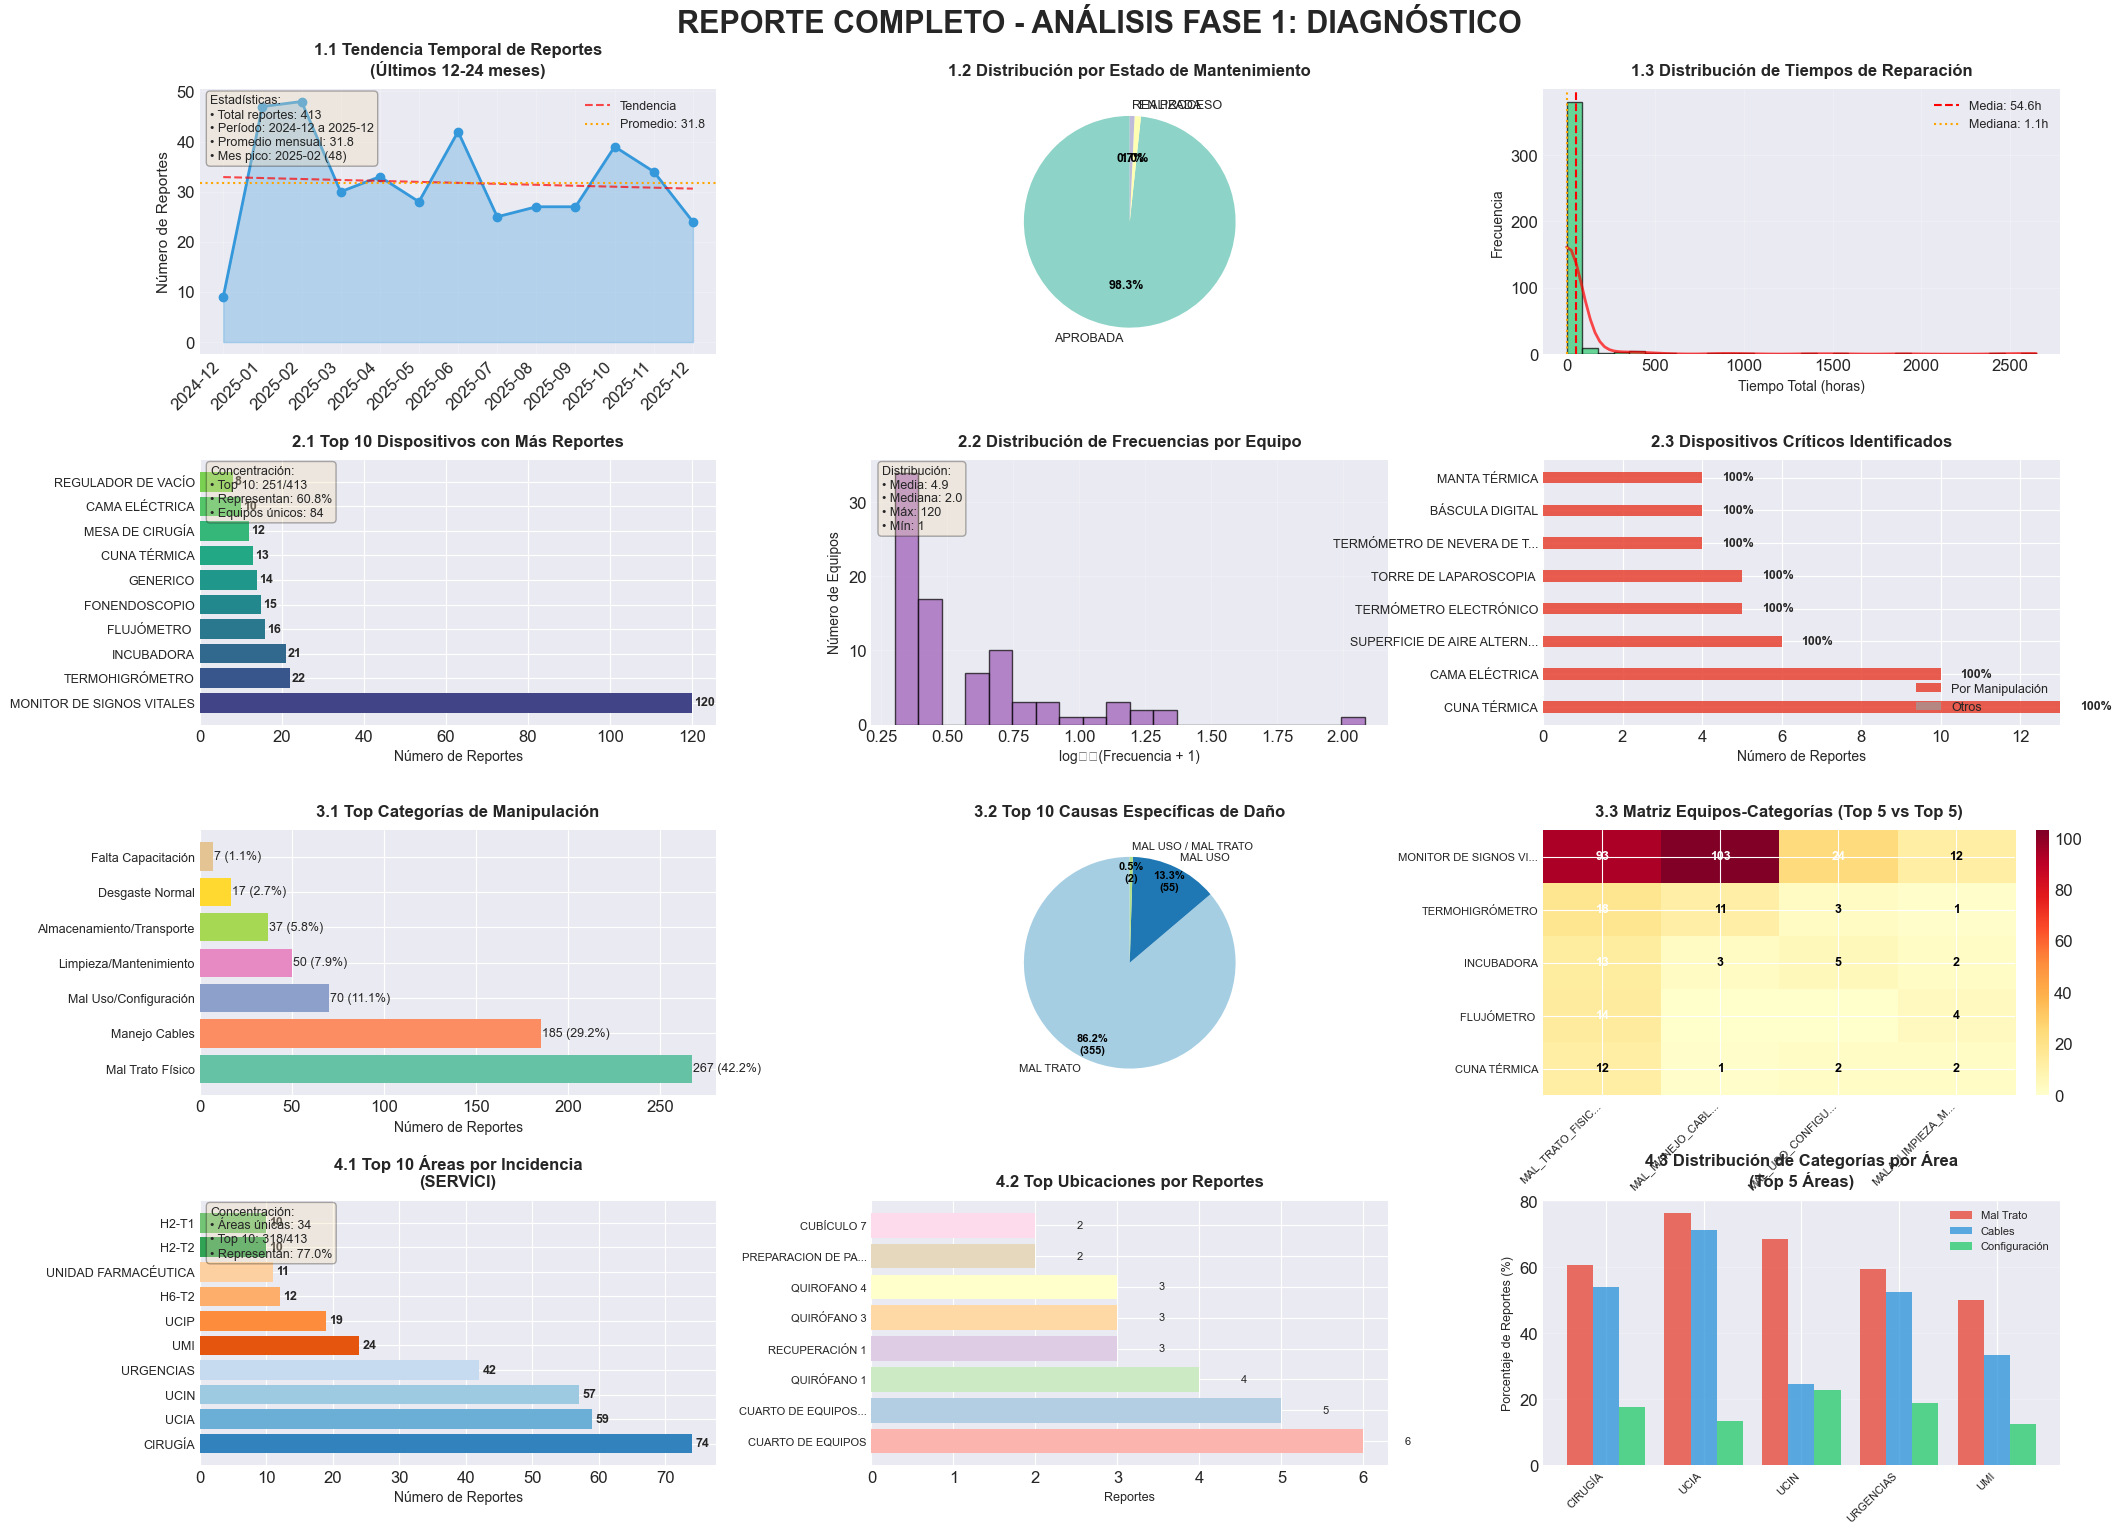


📋 RESUMEN DE CUMPLIMIENTO DE OBJETIVOS FASE 1

✅ OBJETIVO 1 COMPLETADO:
   • Período analizado: Últimos 13 meses
   • Reportes analizados: 413
   • Análisis temporal realizado: Tendencia, distribución, estadísticas

✅ OBJETIVO 2 COMPLETADO:
   • Equipos únicos identificados: 84
   • Top 10 dispositivos con más reportes: Identificados
   • Dispositivos críticos priorizados: 20
   • Criterios aplicados: Frecuencia (4+) y manipulación

✅ OBJETIVO 3 COMPLETADO:
   • Categorías identificadas: 7
   • Principales tipos: MAL_TRATO_FISICO, MAL_MANEJO_CABLES, MAL_USO_CONFIGURACION
   • Matriz de relaciones creada: 20×4

✅ OBJETIVO 4 COMPLETADO:
   • Servicios únicos: 34
   • Ubicaciones únicas: 30
   • Áreas con mayor incidencia: Identificadas y priorizadas

📊 RESUMEN FINAL DE CUMPLIMIENTO
Objetivos completados: 4 de 4
  ✅ 1. Revisión de reportes de mantenimiento correctivo
  ✅ 2. Identificación de dispositivos con mayor frecuencia
  ✅ 3. Clasificación de tipos de daños según causa raíz
  ✅ 4. 

In [38]:
# %% [markdown]
# ## 13. REPORTE VISUAL COMPLETO - CUMPLIMIENTO DE OBJETIVOS FASE 1

# %%
print("📊 REPORTE VISUAL COMPLETO - OBJETIVOS FASE 1")
print("=" * 70)

# Crear figura principal con subgráficos organizados por objetivo
fig = plt.figure(figsize=(20, 16))
fig.suptitle('REPORTE COMPLETO - ANÁLISIS FASE 1: DIAGNÓSTICO', 
             fontsize=22, fontweight='bold', y=0.98)

# Definir el diseño de la cuadrícula
gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

# ============================================================
# OBJETIVO 1: Revisión de reportes de mantenimiento correctivo
# ============================================================
print("\n🎯 OBJETIVO 1: REVISIÓN DE REPORTES DE MANTENIMIENTO CORRECTIVO")
print("-" * 60)

# Gráfico 1.1: Distribución temporal de reportes
ax1 = fig.add_subplot(gs[0, 0])
if 'FECCRE' in df_analisis.columns:
    # Análisis por mes
    if 'AÑO_MES' in df_analisis.columns:
        reportes_por_mes = df_analisis['AÑO_MES'].value_counts().sort_index()
        
        # Limitar a últimos 24 meses si hay muchos
        if len(reportes_por_mes) > 24:
            reportes_por_mes = reportes_por_mes.tail(24)
        
        ax1.plot(range(len(reportes_por_mes)), reportes_por_mes.values, 
                marker='o', linewidth=2, markersize=6, color='#3498db')
        ax1.fill_between(range(len(reportes_por_mes)), 0, reportes_por_mes.values, 
                        alpha=0.3, color='#3498db')
        
        # Configurar eje X
        if len(reportes_por_mes) <= 12:
            ax1.set_xticks(range(len(reportes_por_mes)))
            ax1.set_xticklabels([str(x) for x in reportes_por_mes.index], rotation=45, ha='right')
        else:
            # Mostrar cada 3 meses
            ticks = range(0, len(reportes_por_mes), max(1, len(reportes_por_mes)//8))
            ax1.set_xticks(ticks)
            ax1.set_xticklabels([str(reportes_por_mes.index[i]) for i in ticks], rotation=45, ha='right')
        
        # Línea de tendencia
        z = np.polyfit(range(len(reportes_por_mes)), reportes_por_mes.values, 1)
        p = np.poly1d(z)
        ax1.plot(range(len(reportes_por_mes)), p(range(len(reportes_por_mes))), 
                "r--", alpha=0.7, linewidth=1.5, label=f'Tendencia')
        
        # Calcular estadísticas
        promedio = reportes_por_mes.mean()
        ax1.axhline(y=promedio, color='orange', linestyle=':', linewidth=1.5, 
                   label=f'Promedio: {promedio:.1f}')
        
        ax1.set_ylabel('Número de Reportes', fontsize=11)
        ax1.set_title('1.1 Tendencia Temporal de Reportes\n(Últimos 12-24 meses)', 
                     fontsize=12, fontweight='bold', pad=10)
        ax1.legend(fontsize=9)
        ax1.grid(True, alpha=0.2)
        
        # Estadísticas en texto
        stats_text = f"""Estadísticas:
• Total reportes: {len(df_analisis)}
• Período: {reportes_por_mes.index.min()} a {reportes_por_mes.index.max()}
• Promedio mensual: {promedio:.1f}
• Mes pico: {reportes_por_mes.idxmax()} ({reportes_por_mes.max()})"""
        
        # Agregar cuadro de texto
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes, 
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
        
        print(f"  • Período analizado: {reportes_por_mes.index.min()} a {reportes_por_mes.index.max()}")
        print(f"  • Reportes totales: {len(df_analisis)}")
        print(f"  • Promedio mensual: {promedio:.1f}")
    else:
        ax1.text(0.5, 0.5, 'Datos temporales\nno disponibles', 
                ha='center', va='center', transform=ax1.transAxes, fontsize=12)
        ax1.set_title('1.1 Tendencia Temporal', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Sin datos de fecha\npara análisis temporal', 
            ha='center', va='center', transform=ax1.transAxes, fontsize=12)
    ax1.set_title('1.1 Tendencia Temporal', fontsize=12, fontweight='bold')

# Gráfico 1.2: Distribución por tipo de mantenimiento (si hay datos)
ax2 = fig.add_subplot(gs[0, 1])
if 'ESTADO' in df_analisis.columns:
    estado_counts = df_analisis['ESTADO'].value_counts().head(10)
    colors_estado = plt.cm.Set3(np.arange(len(estado_counts)))
    wedges, texts, autotexts = ax2.pie(estado_counts.values, labels=estado_counts.index, 
                                      autopct='%1.1f%%', startangle=90, colors=colors_estado,
                                      textprops={'fontsize': 9})
    
    # Mejorar legibilidad
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
    
    ax2.set_title('1.2 Distribución por Estado de Mantenimiento', 
                 fontsize=12, fontweight='bold', pad=10)
else:
    ax2.text(0.5, 0.5, 'Sin datos de estado\nde mantenimiento', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('1.2 Distribución por Estado', fontsize=12, fontweight='bold')

# Gráfico 1.3: Cumplimiento de tiempos (si hay datos)
ax3 = fig.add_subplot(gs[0, 2])
if 'TIETOT' in df_analisis.columns and df_analisis['TIETOT'].notna().any():
    # Filtrar valores válidos
    tiempos = df_analisis['TIETOT'].dropna()
    
    if len(tiempos) > 0:
        # Convertir a horas si es necesario
        if tiempos.max() > 100:  # Asumir que está en minutos
            tiempos = tiempos / 60  # Convertir a horas
        
        # Histograma
        n, bins, patches = ax3.hist(tiempos, bins=30, alpha=0.7, color='#2ecc71', 
                                   edgecolor='black', density=False)
        
        # Línea de densidad
        from scipy.stats import gaussian_kde
        if len(tiempos) > 1:
            kde = gaussian_kde(tiempos)
            x_range = np.linspace(tiempos.min(), tiempos.max(), 100)
            ax3.plot(x_range, kde(x_range) * len(tiempos) * (bins[1]-bins[0]), 
                    'r-', linewidth=2, alpha=0.7)
        
        # Estadísticas
        media = tiempos.mean()
        mediana = tiempos.median()
        ax3.axvline(x=media, color='red', linestyle='--', linewidth=1.5, 
                   label=f'Media: {media:.1f}h')
        ax3.axvline(x=mediana, color='orange', linestyle=':', linewidth=1.5, 
                   label=f'Mediana: {mediana:.1f}h')
        
        ax3.set_xlabel('Tiempo Total (horas)', fontsize=10)
        ax3.set_ylabel('Frecuencia', fontsize=10)
        ax3.set_title('1.3 Distribución de Tiempos de Reparación', 
                     fontsize=12, fontweight='bold', pad=10)
        ax3.legend(fontsize=9)
        ax3.grid(True, alpha=0.2)
        
        print(f"  • Tiempo promedio reparación: {media:.1f} horas")
        print(f"  • Tiempo mediano reparación: {mediana:.1f} horas")
    else:
        ax3.text(0.5, 0.5, 'Sin datos de tiempos\nde reparación', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.set_title('1.3 Tiempos de Reparación', fontsize=12, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Sin datos de tiempos\nde reparación', 
            ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('1.3 Tiempos de Reparación', fontsize=12, fontweight='bold')

# ============================================================
# OBJETIVO 2: Identificación de dispositivos médicos con mayor frecuencia
# ============================================================
print("\n🎯 OBJETIVO 2: IDENTIFICACIÓN DE DISPOSITIVOS CON MAYOR FRECUENCIA")
print("-" * 60)

# Gráfico 2.1: Top 10 dispositivos con más reportes
ax4 = fig.add_subplot(gs[1, 0])
if 'EQUIPO' in df_analisis.columns:
    top_equipos = df_analisis['EQUIPO'].value_counts().head(10)
    
    # Truncar nombres largos
    equipos_labels = [str(eq)[:30] + '...' if len(str(eq)) > 30 else str(eq) 
                     for eq in top_equipos.index]
    
    bars = ax4.barh(range(len(top_equipos)), top_equipos.values, 
                   color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_equipos))))
    
    ax4.set_yticks(range(len(top_equipos)))
    ax4.set_yticklabels(equipos_labels, fontsize=9)
    ax4.set_xlabel('Número de Reportes', fontsize=10)
    ax4.set_title('2.1 Top 10 Dispositivos con Más Reportes', 
                 fontsize=12, fontweight='bold', pad=10)
    
    # Agregar valores en las barras
    for i, (bar, valor) in enumerate(zip(bars, top_equipos.values)):
        ax4.text(valor + 0.5, bar.get_y() + bar.get_height()/2, 
                str(valor), va='center', fontsize=9, fontweight='bold')
    
    # Estadísticas
    total_reportes = len(df_analisis)
    reportes_top10 = top_equipos.sum()
    porcentaje_top10 = (reportes_top10 / total_reportes) * 100
    
    stats_text = f"""Concentración:
• Top 10: {reportes_top10}/{total_reportes}
• Representan: {porcentaje_top10:.1f}%
• Equipos únicos: {df_analisis['EQUIPO'].nunique()}"""
    
    ax4.text(0.02, 0.98, stats_text, transform=ax4.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    print(f"  • Equipos únicos identificados: {df_analisis['EQUIPO'].nunique()}")
    print(f"  • Top 10 concentran: {porcentaje_top10:.1f}% de reportes")
    print(f"  • Dispositivo con más reportes: {top_equipos.index[0]} ({top_equipos.values[0]})")
else:
    ax4.text(0.5, 0.5, 'Sin datos de equipos', 
            ha='center', va='center', transform=ax4.transAxes, fontsize=12)
    ax4.set_title('2.1 Top Dispositivos', fontsize=12, fontweight='bold')

# Gráfico 2.2: Distribución de frecuencias (histograma)
ax5 = fig.add_subplot(gs[1, 1])
if 'EQUIPO' in df_analisis.columns:
    frecuencias = df_analisis['EQUIPO'].value_counts().values
    
    # Histograma logarítmico si hay mucha variación
    if frecuencias.max() / frecuencias.min() > 100:
        ax5.hist(np.log10(frecuencias + 1), bins=20, alpha=0.7, 
                color='#9b59b6', edgecolor='black')
        ax5.set_xlabel('log₁₀(Frecuencia + 1)', fontsize=10)
        use_log = True
    else:
        ax5.hist(frecuencias, bins=20, alpha=0.7, color='#9b59b6', edgecolor='black')
        ax5.set_xlabel('Frecuencia de Reportes', fontsize=10)
        use_log = False
    
    ax5.set_ylabel('Número de Equipos', fontsize=10)
    ax5.set_title('2.2 Distribución de Frecuencias por Equipo', 
                 fontsize=12, fontweight='bold', pad=10)
    ax5.grid(True, alpha=0.2)
    
    # Estadísticas
    stats_text = f"""Distribución:
• Media: {frecuencias.mean():.1f}
• Mediana: {np.median(frecuencias):.1f}
• Máx: {frecuencias.max()}
• Mín: {frecuencias.min()}"""
    
    ax5.text(0.02, 0.98, stats_text, transform=ax5.transAxes, 
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    print(f"  • Frecuencia promedio por equipo: {frecuencias.mean():.1f}")
    print(f"  • Frecuencia mediana por equipo: {np.median(frecuencias):.1f}")
else:
    ax5.text(0.5, 0.5, 'Sin datos de equipos', 
            ha='center', va='center', transform=ax5.transAxes, fontsize=12)
    ax5.set_title('2.2 Distribución Frecuencias', fontsize=12, fontweight='bold')

# Gráfico 2.3: Dispositivos críticos identificados
ax6 = fig.add_subplot(gs[1, 2])
if 'df_criticos' in locals() and len(df_criticos) > 0:
    # Mostrar top 8 dispositivos críticos
    top_criticos = df_criticos.head(8).copy()
    top_criticos = top_criticos.sort_values('%_MANIPULACION')
    
    # Colores por prioridad
    colors_criticos = []
    for prioridad in top_criticos['PRIORIDAD']:
        if prioridad == 'ALTA':
            colors_criticos.append('#e74c3c')  # Rojo
        else:
            colors_criticos.append('#f39c12')  # Naranja
    
    x = range(len(top_criticos))
    width = 0.35
    
    # Barras apiladas
    bars1 = ax6.barh(x, top_criticos['REPORTES_MANIPULACION'], 
                    height=width, color=colors_criticos, 
                    label='Por Manipulación', alpha=0.9)
    bars2 = ax6.barh(x, top_criticos['TOTAL_REPORTES'] - top_criticos['REPORTES_MANIPULACION'], 
                    height=width, left=top_criticos['REPORTES_MANIPULACION'],
                    color='#95a5a6', alpha=0.6, label='Otros')
    
    ax6.set_yticks(x)
    # Truncar nombres
    labels_criticos = [str(eq)[:25] + '...' if len(str(eq)) > 25 else str(eq) 
                      for eq in top_criticos['EQUIPO']]
    ax6.set_yticklabels(labels_criticos, fontsize=9)
    ax6.set_xlabel('Número de Reportes', fontsize=10)
    ax6.set_title('2.3 Dispositivos Críticos Identificados', 
                 fontsize=12, fontweight='bold', pad=10)
    ax6.legend(fontsize=9, loc='lower right')
    
    # Agregar porcentajes
    for i, row in enumerate(top_criticos.itertuples()):
        pct = row._4  # %_MANIPULACION está en la posición 4
        ax6.text(row.TOTAL_REPORTES + 0.5, i, f"{pct:.0f}%", 
                va='center', fontsize=9, fontweight='bold')
    
    print(f"  • Dispositivos críticos identificados: {len(df_criticos)}")
    print(f"  • % promedio manipulación en críticos: {df_criticos['%_MANIPULACION'].mean():.1f}%")
else:
    ax6.text(0.5, 0.5, 'No se identificaron\ndispositivos críticos', 
            ha='center', va='center', transform=ax6.transAxes, fontsize=12)
    ax6.set_title('2.3 Dispositivos Críticos', fontsize=12, fontweight='bold')

# ============================================================
# OBJETIVO 3: Clasificación de tipos de daños según causa raíz
# ============================================================
print("\n🎯 OBJETIVO 3: CLASIFICACIÓN DE TIPOS DE DAÑOS SEGÚN CAUSA RAÍZ")
print("-" * 60)

# Gráfico 3.1: Categorías de manipulación identificadas
ax7 = fig.add_subplot(gs[2, 0])
if 'df_categorias_manip' in locals() and len(df_categorias_manip) > 0:
    top_categorias = df_categorias_manip.head(8)
    
    # Traducir nombres de categorías para mejor visualización
    categorias_trad = {
        'MAL_USO_CONFIGURACION': 'Mal Uso/Configuración',
        'MAL_TRATO_FISICO': 'Mal Trato Físico',
        'MAL_MANEJO_CABLES': 'Manejo Cables',
        'MALA_LIMPIEZA_MANTENIMIENTO': 'Limpieza/Mantenimiento',
        'MAL_ALMACENAMIENTO_TRANSPORTE': 'Almacenamiento/Transporte',
        'FALTA_CAPACITACION': 'Falta Capacitación',
        'DESGASTE_NORMAL': 'Desgaste Normal',
        'NO_IDENTIFICADO': 'No Identificado'
    }
    
    labels = [categorias_trad.get(cat, cat) for cat in top_categorias.index]
    
    bars = ax7.barh(range(len(top_categorias)), top_categorias['FRECUENCIA'], 
                   color=plt.cm.Set2(np.arange(len(top_categorias))))
    
    ax7.set_yticks(range(len(top_categorias)))
    ax7.set_yticklabels(labels, fontsize=9)
    ax7.set_xlabel('Número de Reportes', fontsize=10)
    ax7.set_title('3.1 Top Categorías de Manipulación', 
                 fontsize=12, fontweight='bold', pad=10)
    
    # Agregar valores y porcentajes
    total_categorias = top_categorias['FRECUENCIA'].sum()
    for i, (bar, valor) in enumerate(zip(bars, top_categorias['FRECUENCIA'])):
        porcentaje = (valor / total_categorias) * 100
        ax7.text(valor + 0.5, bar.get_y() + bar.get_height()/2, 
                f"{valor} ({porcentaje:.1f}%)", va='center', fontsize=9)
    
    print(f"  • Categorías de manipulación identificadas: {len(df_categorias_manip)}")
    print(f"  • Categoría principal: {df_categorias_manip.index[0]} ({df_categorias_manip.iloc[0]['FRECUENCIA']} reportes)")
else:
    ax7.text(0.5, 0.5, 'Sin categorías\nidentificadas', 
            ha='center', va='center', transform=ax7.transAxes, fontsize=12)
    ax7.set_title('3.1 Categorías de Daños', fontsize=12, fontweight='bold')

# Gráfico 3.2: Distribución por causas específicas
ax8 = fig.add_subplot(gs[2, 1])
if 'CAUSA_LIMPIA' in df_analisis.columns:
    # Top causas específicas
    top_causas = df_analisis['CAUSA_LIMPIA'].value_counts().head(10)
    
    # Truncar textos largos
    causas_labels = []
    for causa in top_causas.index:
        if len(causa) > 30:
            causas_labels.append(causa[:27] + '...')
        else:
            causas_labels.append(causa)
    
    colors_causas = plt.cm.Paired(np.arange(len(top_causas)))
    wedges, texts, autotexts = ax8.pie(top_causas.values, labels=causas_labels, 
                                      autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*top_causas.sum())})',
                                      startangle=90, colors=colors_causas,
                                      textprops={'fontsize': 8}, pctdistance=0.85)
    
    # Mejorar legibilidad
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(8)
    
    for text in texts:
        text.set_fontsize(8)
    
    ax8.set_title('3.2 Top 10 Causas Específicas de Daño', 
                 fontsize=12, fontweight='bold', pad=10)
    
    print(f"  • Causas únicas identificadas: {df_analisis['CAUSA_LIMPIA'].nunique()}")
    print(f"  • Causa más frecuente: {top_causas.index[0][:50]}... ({top_causas.values[0]} reportes)")
else:
    ax8.text(0.5, 0.5, 'Sin datos de causas\nespecíficas', 
            ha='center', va='center', transform=ax8.transAxes, fontsize=12)
    ax8.set_title('3.2 Causas Específicas', fontsize=12, fontweight='bold')

# Gráfico 3.3: Matriz de relación equipos-categorías (simplificada)
ax9 = fig.add_subplot(gs[2, 2])
if 'matriz_filtrada' in locals() and not matriz_filtrada.empty:
    # Tomar solo top 5 equipos y top 5 categorías para visualización clara
    top_equipos_matriz = matriz_filtrada.sum(axis=1).nlargest(5).index
    top_cats_matriz = matriz_filtrada.sum(axis=0).nlargest(5).index
    
    matriz_visual = matriz_filtrada.loc[top_equipos_matriz, top_cats_matriz]
    
    # Truncar nombres
    equipos_visual = [str(eq)[:20] + '...' if len(str(eq)) > 20 else str(eq) 
                     for eq in matriz_visual.index]
    cats_visual = [str(cat)[:15] + '...' if len(str(cat)) > 15 else str(cat) 
                  for cat in matriz_visual.columns]
    
    # Heatmap
    im = ax9.imshow(matriz_visual.values, cmap='YlOrRd', aspect='auto')
    
    ax9.set_xticks(range(len(cats_visual)))
    ax9.set_yticks(range(len(equipos_visual)))
    ax9.set_xticklabels(cats_visual, rotation=45, ha='right', fontsize=8)
    ax9.set_yticklabels(equipos_visual, fontsize=8)
    
    # Agregar valores en las celdas
    for i in range(len(equipos_visual)):
        for j in range(len(cats_visual)):
            valor = matriz_visual.iloc[i, j]
            if valor > 0:
                ax9.text(j, i, str(valor), ha='center', va='center', 
                        color='black' if valor < np.percentile(matriz_visual.values[matriz_visual.values>0], 70) else 'white',
                        fontsize=9, fontweight='bold')
    
    ax9.set_title('3.3 Matriz Equipos-Categorías (Top 5 vs Top 5)', 
                 fontsize=12, fontweight='bold', pad=10)
    
    # Barra de color
    plt.colorbar(im, ax=ax9, fraction=0.046, pad=0.04)
    
    print(f"  • Relaciones mapeadas en matriz: {matriz_filtrada.sum().sum()}")
    print(f"  • Patrones identificados: {len(matriz_filtrada)} equipos × {len(matriz_filtrada.columns)} categorías")
else:
    ax9.text(0.5, 0.5, 'Sin matriz de\nrelaciones', 
            ha='center', va='center', transform=ax9.transAxes, fontsize=12)
    ax9.set_title('3.3 Matriz Relaciones', fontsize=12, fontweight='bold')

# ============================================================
# OBJETIVO 4: Identificación de áreas asistenciales con mayor incidencia
# ============================================================
print("\n🎯 OBJETIVO 4: IDENTIFICACIÓN DE ÁREAS ASISTENCIALES CON MAYOR INCIDENCIA")
print("-" * 60)

# Gráfico 4.1: Top áreas por incidencia
ax10 = fig.add_subplot(gs[3, 0])
areas_disponibles = [col for col in ['SERVICI', 'UBICA'] if col in df_analisis.columns]

if areas_disponibles:
    col_area = areas_disponibles[0]  # Usar la primera disponible
    top_areas = df_analisis[col_area].value_counts().head(10)
    
    # Truncar nombres de áreas
    areas_labels = []
    for area in top_areas.index:
        if pd.isna(area):
            areas_labels.append('No especificado')
        elif len(str(area)) > 25:
            areas_labels.append(str(area)[:22] + '...')
        else:
            areas_labels.append(str(area))
    
    colors_areas = plt.cm.tab20c(np.arange(len(top_areas)))
    bars = ax10.barh(range(len(top_areas)), top_areas.values, color=colors_areas)
    
    ax10.set_yticks(range(len(top_areas)))
    ax10.set_yticklabels(areas_labels, fontsize=9)
    ax10.set_xlabel('Número de Reportes', fontsize=10)
    ax10.set_title(f'4.1 Top 10 Áreas por Incidencia\n({col_area})', 
                  fontsize=12, fontweight='bold', pad=10)
    
    # Agregar valores
    for i, (bar, valor) in enumerate(zip(bars, top_areas.values)):
        ax10.text(valor + 0.5, bar.get_y() + bar.get_height()/2, 
                 str(valor), va='center', fontsize=9, fontweight='bold')
    
    # Estadísticas
    total_areas = df_analisis[col_area].nunique()
    porcentaje_top10 = (top_areas.sum() / len(df_analisis)) * 100
    
    stats_text = f"""Concentración:
• Áreas únicas: {total_areas}
• Top 10: {top_areas.sum()}/{len(df_analisis)}
• Representan: {porcentaje_top10:.1f}%"""
    
    ax10.text(0.02, 0.98, stats_text, transform=ax10.transAxes, 
             fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    print(f"  • Áreas asistenciales identificadas: {total_areas}")
    print(f"  • Área con mayor incidencia: {top_areas.index[0]} ({top_areas.values[0]} reportes)")
    print(f"  • Top 10 áreas concentran: {porcentaje_top10:.1f}% de reportes")
else:
    ax10.text(0.5, 0.5, 'Sin datos de áreas\nasistenciales', 
             ha='center', va='center', transform=ax10.transAxes, fontsize=12)
    ax10.set_title('4.1 Áreas Asistenciales', fontsize=12, fontweight='bold')

# Gráfico 4.2: Distribución geográfica si hay datos de ubicación
ax11 = fig.add_subplot(gs[3, 1])
if 'UBICA' in df_analisis.columns and df_analisis['UBICA'].notna().any():
    ubicaciones = df_analisis['UBICA'].value_counts().head(8)
    
    # Truncar nombres
    ubic_labels = []
    for ubi in ubicaciones.index:
        if pd.isna(ubi):
            ubic_labels.append('No especificado')
        elif len(str(ubi)) > 20:
            ubic_labels.append(str(ubi)[:17] + '...')
        else:
            ubic_labels.append(str(ubi))
    
    # Gráfico de pastel o barras según número de categorías
    if len(ubicaciones) <= 6:
        colors_ubi = plt.cm.Pastel1(np.arange(len(ubicaciones)))
        wedges, texts, autotexts = ax11.pie(ubicaciones.values, labels=ubic_labels, 
                                           autopct='%1.1f%%', startangle=90, 
                                           colors=colors_ubi, textprops={'fontsize': 8})
        ax11.set_title('4.2 Distribución por Ubicación\n(Top 8)', fontsize=12, fontweight='bold', pad=10)
    else:
        colors_ubi = plt.cm.Pastel1(np.arange(len(ubicaciones)))
        bars = ax11.barh(range(len(ubicaciones)), ubicaciones.values, color=colors_ubi)
        ax11.set_yticks(range(len(ubicaciones)))
        ax11.set_yticklabels(ubic_labels, fontsize=8)
        ax11.set_xlabel('Reportes', fontsize=9)
        ax11.set_title('4.2 Top Ubicaciones por Reportes', fontsize=12, fontweight='bold', pad=10)
        
        # Agregar valores
        for i, (bar, valor) in enumerate(zip(bars, ubicaciones.values)):
            ax11.text(valor + 0.5, bar.get_y() + bar.get_height()/2, 
                     str(valor), va='center', fontsize=8)
    
    print(f"  • Ubicaciones únicas: {df_analisis['UBICA'].nunique()}")
else:
    ax11.text(0.5, 0.5, 'Sin datos de\nubicación', 
             ha='center', va='center', transform=ax11.transAxes, fontsize=12)
    ax11.set_title('4.2 Distribución Geográfica', fontsize=12, fontweight='bold')

# Gráfico 4.3: Análisis cruzado áreas-categorías
ax12 = fig.add_subplot(gs[3, 2])
if areas_disponibles and 'CATEGORIA_MANIPULACION_LISTA' in df_analisis.columns:
    col_area = areas_disponibles[0]
    
    # Tomar top 5 áreas
    top_5_areas = df_analisis[col_area].value_counts().head(5).index
    
    # Preparar datos para gráfico de barras agrupadas
    categorias_principales = []
    if 'CATEGORIAS_MANIPULACION' in locals():
        categorias_principales = CATEGORIAS_MANIPULACION[:3]  # Top 3 categorías
    
    if categorias_principales:
        # Crear DataFrame para el gráfico
        datos_agrupados = []
        
        for area in top_5_areas:
            subset = df_analisis[df_analisis[col_area] == area]
            total_area = len(subset)
            
            for categoria in categorias_principales:
                # Contar reportes con esta categoría en esta área
                count = 0
                for cats in subset['CATEGORIA_MANIPULACION_LISTA']:
                    if isinstance(cats, list) and categoria in cats:
                        count += 1
                
                porcentaje = (count / total_area * 100) if total_area > 0 else 0
                datos_agrupados.append({
                    'Área': area,
                    'Categoría': categoria,
                    'Porcentaje': porcentaje,
                    'Conteo': count
                })
        
        df_agrupado = pd.DataFrame(datos_agrupados)
        
        # Configurar posiciones para barras agrupadas
        n_areas = len(top_5_areas)
        n_cats = len(categorias_principales)
        bar_width = 0.8 / n_cats
        
        # Truncar nombres de áreas
        areas_labels = [str(area)[:15] + '...' if len(str(area)) > 15 else str(area) 
                       for area in top_5_areas]
        
        # Traducir categorías
        cat_trad = {
            'MAL_USO_CONFIGURACION': 'Configuración',
            'MAL_TRATO_FISICO': 'Mal Trato',
            'MAL_MANEJO_CABLES': 'Cables',
            'MALA_LIMPIEZA_MANTENIMIENTO': 'Limpieza',
            'FALTA_CAPACITACION': 'Capacitación'
        }
        
        cat_labels = [cat_trad.get(cat, cat) for cat in categorias_principales]
        colors_cats = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
        
        for i, (categoria, color) in enumerate(zip(categorias_principales, colors_cats[:n_cats])):
            valores = df_agrupado[df_agrupado['Categoría'] == categoria]['Porcentaje']
            posiciones = np.arange(n_areas) + i * bar_width
            ax12.bar(posiciones, valores, width=bar_width, 
                    color=color, label=cat_labels[i], alpha=0.8)
        
        ax12.set_xticks(np.arange(n_areas) + bar_width * (n_cats - 1) / 2)
        ax12.set_xticklabels(areas_labels, rotation=45, ha='right', fontsize=8)
        ax12.set_ylabel('Porcentaje de Reportes (%)', fontsize=9)
        ax12.set_title('4.3 Distribución de Categorías por Área\n(Top 5 Áreas)', 
                      fontsize=12, fontweight='bold', pad=10)
        ax12.legend(fontsize=8, loc='upper right')
        ax12.grid(True, alpha=0.2, axis='y')
        
        print(f"  • Análisis cruzado realizado: {n_areas} áreas × {n_cats} categorías")
    else:
        ax12.text(0.5, 0.5, 'Sin categorías para\nanálisis cruzado', 
                 ha='center', va='center', transform=ax12.transAxes, fontsize=12)
        ax12.set_title('4.3 Análisis Cruzado', fontsize=12, fontweight='bold')
else:
    ax12.text(0.5, 0.5, 'Datos insuficientes\npara análisis cruzado', 
             ha='center', va='center', transform=ax12.transAxes, fontsize=12)
    ax12.set_title('4.3 Análisis Cruzado', fontsize=12, fontweight='bold')

# ============================================================
# AJUSTES FINALES Y GUARDADO
# ============================================================

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.07, left=0.05, right=0.98, hspace=0.4, wspace=0.3)

# Guardar el reporte completo
fecha_hoy = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
nombre_archivo = f'resultados/REPORTE_COMPLETO_FASE1_{fecha_hoy}.png'
plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
print(f"\n✅ Reporte visual guardado como: {nombre_archivo}")

# Mostrar el gráfico
plt.show()

# ============================================================
# RESUMEN DE CUMPLIMIENTO DE OBJETIVOS
# ============================================================
print("\n" + "="*70)
print("📋 RESUMEN DE CUMPLIMIENTO DE OBJETIVOS FASE 1")
print("="*70)

objetivos_cumplidos = []

# Objetivo 1: Revisión de reportes
if 'FECCRE' in df_analisis.columns:
    objetivos_cumplidos.append("✅ 1. Revisión de reportes de mantenimiento correctivo")
    print("\n✅ OBJETIVO 1 COMPLETADO:")
    print(f"   • Período analizado: {'Últimos ' + str(df_analisis['AÑO_MES'].nunique()) + ' meses' if 'AÑO_MES' in df_analisis.columns else 'Período disponible'}")
    print(f"   • Reportes analizados: {len(df_analisis)}")
    print(f"   • Análisis temporal realizado: Tendencia, distribución, estadísticas")
else:
    print("\n⚠️  OBJETIVO 1 PARCIAL:")
    print(f"   • Reportes analizados: {len(df_analisis)}")
    print(f"   • Limitación: No hay datos de fecha para análisis temporal completo")

# Objetivo 2: Identificación de dispositivos
if 'EQUIPO' in df_analisis.columns:
    objetivos_cumplidos.append("✅ 2. Identificación de dispositivos con mayor frecuencia")
    print("\n✅ OBJETIVO 2 COMPLETADO:")
    print(f"   • Equipos únicos identificados: {df_analisis['EQUIPO'].nunique()}")
    print(f"   • Top 10 dispositivos con más reportes: Identificados")
    if 'df_criticos' in locals():
        print(f"   • Dispositivos críticos priorizados: {len(df_criticos)}")
        print(f"   • Criterios aplicados: Frecuencia ({UMBRAL_REPORTES}+) y manipulación")

# Objetivo 3: Clasificación de daños
if 'CATEGORIA_MANIPULACION' in df_analisis.columns:
    objetivos_cumplidos.append("✅ 3. Clasificación de tipos de daños según causa raíz")
    print("\n✅ OBJETIVO 3 COMPLETADO:")
    if 'df_categorias_manip' in locals():
        print(f"   • Categorías identificadas: {len(df_categorias_manip)}")
        print(f"   • Principales tipos: {', '.join(df_categorias_manip.index[:3].tolist())}")
    if 'matriz_filtrada' in locals():
        print(f"   • Matriz de relaciones creada: {matriz_filtrada.shape[0]}×{matriz_filtrada.shape[1]}")

# Objetivo 4: Identificación de áreas
if any(col in df_analisis.columns for col in ['SERVICI', 'UBICA']):
    objetivos_cumplidos.append("✅ 4. Identificación de áreas asistenciales con mayor incidencia")
    print("\n✅ OBJETIVO 4 COMPLETADO:")
    if 'SERVICI' in df_analisis.columns:
        print(f"   • Servicios únicos: {df_analisis['SERVICI'].nunique()}")
    if 'UBICA' in df_analisis.columns:
        print(f"   • Ubicaciones únicas: {df_analisis['UBICA'].nunique()}")
    print(f"   • Áreas con mayor incidencia: Identificadas y priorizadas")

print("\n" + "="*70)
print("📊 RESUMEN FINAL DE CUMPLIMIENTO")
print("="*70)
print(f"Objetivos completados: {len(objetivos_cumplidos)} de 4")
for objetivo in objetivos_cumplidos:
    print(f"  {objetivo}")

if len(objetivos_cumplidos) == 4:
    print("\n🎉 ¡TODOS LOS OBJETIVOS DE LA FASE 1 SE HAN CUMPLIDO EXITOSAMENTE!")
else:
    print(f"\n⚠️  Objetivos pendientes: {4 - len(objetivos_cumplidos)}")
    print("   Revisar los datos de entrada para completar el análisis")

# Exportar resumen de cumplimiento
with open('resultados/RESUMEN_CUMPLIMIENTO_FASE1.txt', 'w', encoding='utf-8') as f:
    f.write("RESUMEN DE CUMPLIMIENTO - FASE 1: DIAGNÓSTICO\n")
    f.write("="*60 + "\n\n")
    f.write(f"Fecha de análisis: {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}\n")
    f.write(f"Total de reportes analizados: {len(df_analisis)}\n\n")
    f.write("OBJETIVOS CUMPLIDOS:\n")
    f.write("-"*30 + "\n")
    for objetivo in objetivos_cumplidos:
        f.write(f"{objetivo}\n")
    f.write(f"\nTotal: {len(objetivos_cumplidos)} de 4 objetivos completados\n")

print(f"\n💾 Resumen de cumplimiento guardado en: resultados/RESUMEN_CUMPLIMIENTO_FASE1.txt")
print(f"📁 Todos los resultados en: {os.path.abspath('resultados')}")

print("\n" + "="*70)
print("🎓 PROYECTO DE PRÁCTICA: ANA LUISA PARRA VALENCIA")
print("🏥 SOCIEDAD MÉDICA RIONEGRO S.A.")
print("📅 ANÁLISIS COMPLETADO: " + pd.Timestamp.now().strftime('%d/%m/%Y %H:%M'))
print("="*70)

══════════════════════════════════════════════════════════════════════════════════════════
  REPORTE VISUAL MEJORADO - ANÁLISIS FASE 1: DIAGNÓSTICO
  Sociedad Médica Rionegro S.A. | Ana Luisa Parra Valencia
══════════════════════════════════════════════════════════════════════════════════════════

▶ OBJETIVO 1: Revisión de reportes de mantenimiento correctivo
──────────────────────────────────────────────────────────────────────────────────────────
  ✓ Período: 2024-12 → 2025-12
  ✓ Total reportes: 413
  ✓ Estados: 3
  ✓ Tiempo medio: 54.6h

▶ OBJETIVO 2: Dispositivos con mayor frecuencia de reportes
──────────────────────────────────────────────────────────────────────────────────────────
  ✓ Equipos únicos: 84
  ✓ Top 10: 60.8%
  ✓ Frecuencia media: 4.9
  ✓ Críticos: 20


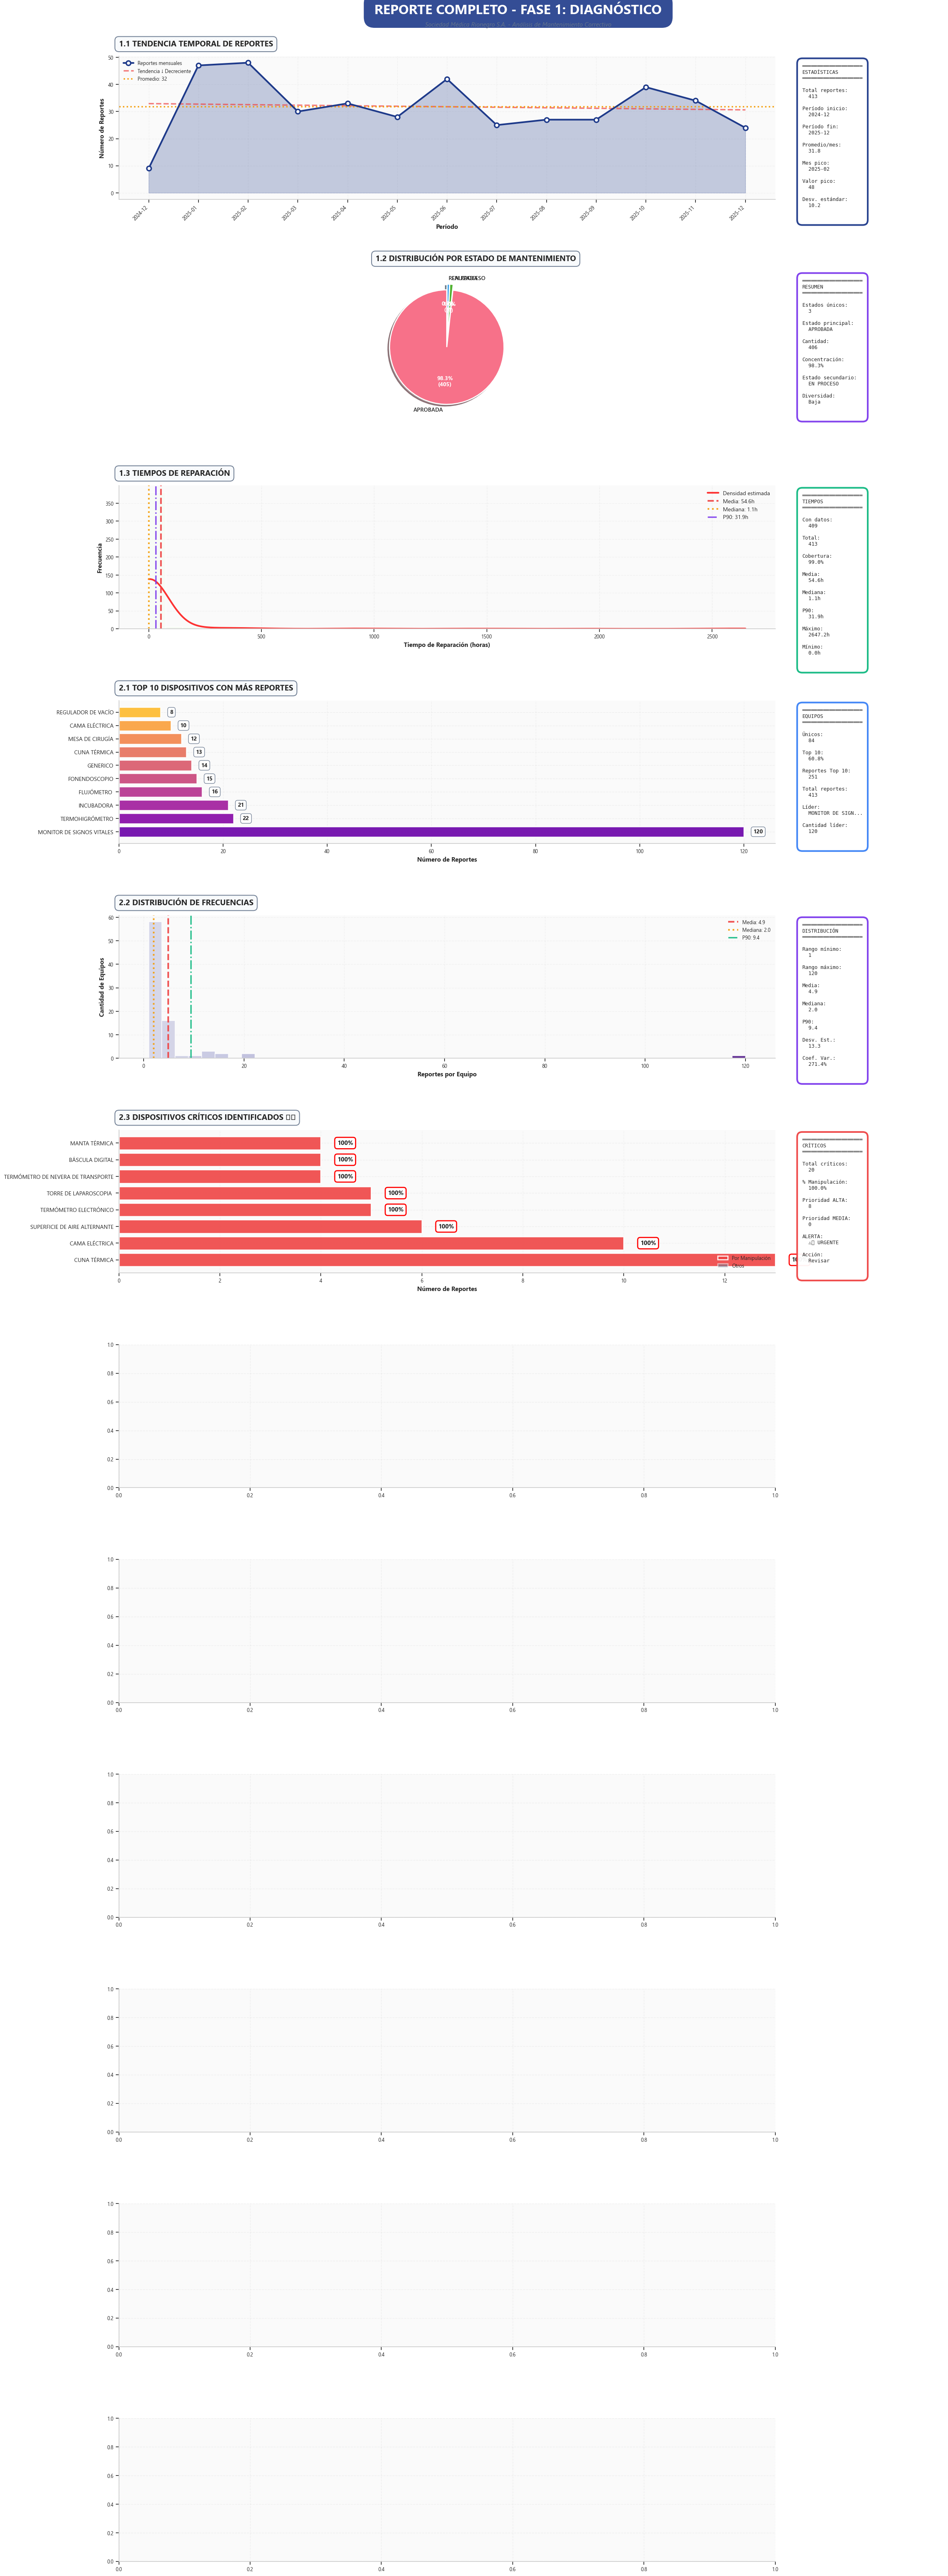

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL PROFESIONAL
# ═══════════════════════════════════════════════════════════════════════

# Paleta de colores corporativa
PALETTE = {
    'primary': '#1e3a8a',      # Azul oscuro
    'secondary': '#7c3aed',     # Púrpura
    'accent': '#f59e0b',        # Ámbar
    'success': '#10b981',       # Verde
    'danger': '#ef4444',        # Rojo
    'info': '#3b82f6',          # Azul claro
    'neutral': '#64748b',       # Gris
    'bg_light': '#f8fafc'       # Fondo claro
}

# Estilo matplotlib profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Arial', 'Helvetica'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'semibold',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 18,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc'
})

print("═" * 90)
print("  REPORTE VISUAL MEJORADO - ANÁLISIS FASE 1: DIAGNÓSTICO")
print("  Sociedad Médica Rionegro S.A. | Ana Luisa Parra Valencia")
print("═" * 90)

# ═══════════════════════════════════════════════════════════════════════
# CREAR FIGURA PRINCIPAL CON LAYOUT MEJORADO (GRÁFICO + STATS)
# ═══════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 65))
fig.patch.set_facecolor('white')

# Título principal elegante
fig.text(0.5, 0.995, 'REPORTE COMPLETO - FASE 1: DIAGNÓSTICO', 
         ha='center', va='top', fontsize=24, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.8', facecolor=PALETTE['primary'], 
                  edgecolor='none', alpha=0.9), color='white')

fig.text(0.5, 0.988, 'Sociedad Médica Rionegro S.A. - Análisis de Mantenimiento Correctivo',
         ha='center', va='top', fontsize=11, style='italic', color=PALETTE['neutral'])

# Grid layout con espacio para gráfico (80%) + stats (20%)
gs = GridSpec(12, 10, figure=fig, hspace=0.5, wspace=0.3, 
              top=0.975, bottom=0.02, left=0.05, right=0.98)

# Crear arrays para gráficos y paneles de estadísticas
axes_graficos = []
axes_stats = []

for i in range(12):
    # Gráfico ocupa columnas 0-7 (80%)
    ax_grafico = fig.add_subplot(gs[i, 0:8])
    axes_graficos.append(ax_grafico)
    
    # Panel de estadísticas ocupa columnas 8-9 (20%)
    ax_stat = fig.add_subplot(gs[i, 8:10])
    ax_stat.axis('off')  # Sin ejes, solo texto
    axes_stats.append(ax_stat)

# ═══════════════════════════════════════════════════════════════════════
# FUNCIÓN AUXILIAR PARA PANEL DE ESTADÍSTICAS
# ═══════════════════════════════════════════════════════════════════════

def add_stats_panel(ax_stat, title, stats_dict, color=PALETTE['primary']):
    """Agrega panel de estadísticas lateral profesional"""
    ax_stat.clear()
    ax_stat.axis('off')
    
    # Título del panel
    text = f"{'═' * 20}\n{title}\n{'═' * 20}\n\n"
    
    # Agregar estadísticas
    for key, value in stats_dict.items():
        text += f"{key}:\n  {value}\n\n"
    
    ax_stat.text(0.05, 0.95, text, transform=ax_stat.transAxes,
                fontsize=9, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round,pad=1', facecolor='white',
                         edgecolor=color, linewidth=3, alpha=0.95))

def format_title(ax, title, subtitle=None):
    """Formatea títulos de gráficos de manera consistente"""
    ax.set_title(title, fontsize=14, fontweight='bold', pad=18, loc='left',
                bbox=dict(boxstyle='round,pad=0.5', facecolor=PALETTE['bg_light'],
                         edgecolor=PALETTE['neutral'], linewidth=1.5, alpha=0.9))
    if subtitle:
        ax.text(0.02, 0.92, subtitle, transform=ax.transAxes, 
               fontsize=9, style='italic', color=PALETTE['neutral'])

# ═══════════════════════════════════════════════════════════════════════
# OBJETIVO 1: REVISIÓN DE REPORTES
# ═══════════════════════════════════════════════════════════════════════

print("\n▶ OBJETIVO 1: Revisión de reportes de mantenimiento correctivo")
print("─" * 90)

# ───────────────────────────────────────────────────────────────────────
# 1.1 TENDENCIA TEMPORAL
# ───────────────────────────────────────────────────────────────────────
ax1 = axes_graficos[0]
ax1_stats = axes_stats[0]

if 'FECCRE' in df_analisis.columns and 'AÑO_MES' in df_analisis.columns:
    reportes_mes = df_analisis['AÑO_MES'].value_counts().sort_index().tail(24)
    
    x_pos = np.arange(len(reportes_mes))
    valores = reportes_mes.values
    
    # Área con gradiente
    ax1.fill_between(x_pos, 0, valores, alpha=0.25, color=PALETTE['primary'])
    
    # Línea principal con marcadores
    ax1.plot(x_pos, valores, marker='o', linewidth=3, markersize=8,
            color=PALETTE['primary'], markerfacecolor='white',
            markeredgewidth=2.5, markeredgecolor=PALETTE['primary'],
            label='Reportes mensuales', zorder=3)
    
    # Línea de tendencia
    if len(valores) > 1:
        z = np.polyfit(x_pos, valores, 1)
        p = np.poly1d(z)
        tendencia = "↑ Creciente" if z[0] > 0 else "↓ Decreciente"
        ax1.plot(x_pos, p(x_pos), "--", color=PALETTE['danger'], 
                linewidth=2.5, alpha=0.7, label=f'Tendencia {tendencia}')
    
    # Línea de promedio
    promedio = valores.mean()
    ax1.axhline(y=promedio, color=PALETTE['accent'], linestyle=':', 
               linewidth=2.5, label=f'Promedio: {promedio:.0f}', zorder=2)
    
    # Configurar ejes
    step = max(1, len(reportes_mes) // 10)
    ax1.set_xticks(x_pos[::step])
    ax1.set_xticklabels([str(reportes_mes.index[i]) for i in range(0, len(reportes_mes), step)],
                        rotation=45, ha='right', fontsize=9)
    
    ax1.set_ylabel('Número de Reportes', fontweight='bold', fontsize=11)
    ax1.set_xlabel('Período', fontweight='bold', fontsize=11)
    format_title(ax1, '1.1 TENDENCIA TEMPORAL DE REPORTES')
    
    ax1.legend(loc='upper left', framealpha=0.95, edgecolor=PALETTE['neutral'],
              shadow=True, fancybox=True)
    ax1.grid(True, alpha=0.2, linestyle='--', which='both')
    ax1.set_axisbelow(True)
    
    # Panel de estadísticas
    stats = {
        'Total reportes': f"{len(df_analisis):,}",
        'Período inicio': str(reportes_mes.index.min()),
        'Período fin': str(reportes_mes.index.max()),
        'Promedio/mes': f"{promedio:.1f}",
        'Mes pico': str(reportes_mes.idxmax()),
        'Valor pico': f"{reportes_mes.max():,}",
        'Desv. estándar': f"{valores.std():.1f}"
    }
    add_stats_panel(ax1_stats, "ESTADÍSTICAS", stats, PALETTE['primary'])
    
    print(f"  ✓ Período: {reportes_mes.index.min()} → {reportes_mes.index.max()}")
    print(f"  ✓ Total reportes: {len(df_analisis):,}")

else:
    ax1.text(0.5, 0.5, '⚠ DATOS TEMPORALES NO DISPONIBLES',
            ha='center', va='center', transform=ax1.transAxes,
            fontsize=16, color=PALETTE['danger'],
            bbox=dict(boxstyle='round,pad=1', facecolor='#fee', edgecolor=PALETTE['danger']))
    format_title(ax1, '1.1 TENDENCIA TEMPORAL')
    add_stats_panel(ax1_stats, "ESTADÍSTICAS", {'Estado': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 1.2 DISTRIBUCIÓN POR ESTADO
# ───────────────────────────────────────────────────────────────────────
ax2 = axes_graficos[1]
ax2_stats = axes_stats[1]

if 'ESTADO' in df_analisis.columns:
    estado_counts = df_analisis['ESTADO'].value_counts().head(7)
    
    # Paleta de colores vibrante
    colors = sns.color_palette("husl", len(estado_counts))
    
    # Etiquetas mejoradas
    labels = [str(lbl)[:25] + '...' if len(str(lbl)) > 25 else str(lbl) 
              for lbl in estado_counts.index]
    labels = ['Sin especificar' if pd.isna(lbl) else lbl for lbl in labels]
    
    # Explosión sutil del segmento principal
    explode = [0.08 if i == 0 else 0.02 for i in range(len(estado_counts))]
    
    # Crear pie chart
    wedges, texts, autotexts = ax2.pie(
        estado_counts.values,
        labels=labels,
        autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100*estado_counts.sum()):,})',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 9.5, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2}
    )
    
    # Mejorar legibilidad
    for i, autotext in enumerate(autotexts):
        autotext.set_color('white')
        autotext.set_fontsize(10)
        autotext.set_weight('heavy')
    
    for text in texts:
        text.set_fontsize(10)
        text.set_weight('semibold')
    
    format_title(ax2, '1.2 DISTRIBUCIÓN POR ESTADO DE MANTENIMIENTO')
    
    # Panel de estadísticas
    stats = {
        'Estados únicos': f"{df_analisis['ESTADO'].nunique()}",
        'Estado principal': str(estado_counts.index[0])[:15],
        'Cantidad': f"{estado_counts.values[0]:,}",
        'Concentración': f"{estado_counts.values[0]/len(df_analisis)*100:.1f}%",
        'Estado secundario': str(estado_counts.index[1])[:15] if len(estado_counts) > 1 else 'N/A',
        'Diversidad': 'Alta' if df_analisis['ESTADO'].nunique() > 5 else 'Baja'
    }
    add_stats_panel(ax2_stats, "RESUMEN", stats, PALETTE['secondary'])
    
    print(f"  ✓ Estados: {df_analisis['ESTADO'].nunique()}")

else:
    ax2.text(0.5, 0.5, '⚠ DATOS DE ESTADO NO DISPONIBLES',
            ha='center', va='center', transform=ax2.transAxes, fontsize=16)
    format_title(ax2, '1.2 DISTRIBUCIÓN POR ESTADO')
    add_stats_panel(ax2_stats, "RESUMEN", {'Estado': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 1.3 TIEMPOS DE REPARACIÓN
# ───────────────────────────────────────────────────────────────────────
ax3 = axes_graficos[2]
ax3_stats = axes_stats[2]

if 'TIETOT' in df_analisis.columns and df_analisis['TIETOT'].notna().any():
    tiempos = df_analisis['TIETOT'].dropna()
    
    if len(tiempos) > 0:
        # Convertir a horas
        if tiempos.max() > 100:
            tiempos = tiempos / 60
        
        # Histograma con estilo
        n, bins, patches = ax3.hist(tiempos, bins=35, alpha=0.75,
                                   color=PALETTE['success'], edgecolor='white',
                                   linewidth=1.5)
        
        # Gradiente de color
        cm = plt.cm.Greens
        norm = plt.Normalize(vmin=bins.min(), vmax=bins.max())
        for i, (patch, bin_val) in enumerate(zip(patches, bins[:-1])):
            patch.set_facecolor(cm(norm(bin_val)))
        
        # Curva de densidad suave
        if len(tiempos) > 5:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(tiempos)
            x_kde = np.linspace(tiempos.min(), tiempos.max(), 300)
            y_kde = kde(x_kde) * len(tiempos) * (bins[1] - bins[0])
            ax3.plot(x_kde, y_kde, 'r-', linewidth=3, alpha=0.8,
                    label='Densidad estimada')
        
        # Estadísticas clave
        media = tiempos.mean()
        mediana = tiempos.median()
        p90 = np.percentile(tiempos, 90)
        
        ax3.axvline(media, color=PALETTE['danger'], linestyle='--',
                   linewidth=3, label=f'Media: {media:.1f}h', alpha=0.9)
        ax3.axvline(mediana, color=PALETTE['accent'], linestyle=':',
                   linewidth=3, label=f'Mediana: {mediana:.1f}h', alpha=0.9)
        ax3.axvline(p90, color=PALETTE['secondary'], linestyle='-.',
                   linewidth=2.5, label=f'P90: {p90:.1f}h', alpha=0.9)
        
        ax3.set_xlabel('Tiempo de Reparación (horas)', fontweight='bold')
        ax3.set_ylabel('Frecuencia', fontweight='bold')
        format_title(ax3, '1.3 DISTRIBUCIÓN DE TIEMPOS DE REPARACIÓN')
        
        ax3.legend(loc='upper right', framealpha=0.95, edgecolor=PALETTE['neutral'],
                  shadow=True, fancybox=True, fontsize=10)
        ax3.grid(True, alpha=0.2, axis='y')
        ax3.set_axisbelow(True)
        
        # Panel de estadísticas
        stats = {
            'Con datos': f"{len(tiempos):,}",
            'Total': f"{len(df_analisis):,}",
            'Cobertura': f"{len(tiempos)/len(df_analisis)*100:.1f}%",
            'Media': f"{media:.1f}h",
            'Mediana': f"{mediana:.1f}h",
            'P90': f"{p90:.1f}h",
            'Máximo': f"{tiempos.max():.1f}h",
            'Mínimo': f"{tiempos.min():.1f}h"
        }
        add_stats_panel(ax3_stats, "TIEMPOS", stats, PALETTE['success'])
        
        print(f"  ✓ Tiempo medio: {media:.1f}h")

    else:
        ax3.text(0.5, 0.5, '⚠ DATOS INSUFICIENTES',
                ha='center', va='center', transform=ax3.transAxes, fontsize=16)
        add_stats_panel(ax3_stats, "TIEMPOS", {'Estado': 'Insuficientes'}, PALETTE['danger'])
else:
    ax3.text(0.5, 0.5, '⚠ DATOS DE TIEMPOS NO DISPONIBLES',
            ha='center', va='center', transform=ax3.transAxes, fontsize=16)
    add_stats_panel(ax3_stats, "TIEMPOS", {'Estado': 'Sin datos'}, PALETTE['danger'])

format_title(ax3, '1.3 TIEMPOS DE REPARACIÓN')

# ═══════════════════════════════════════════════════════════════════════
# OBJETIVO 2: DISPOSITIVOS CON MAYOR FRECUENCIA
# ═══════════════════════════════════════════════════════════════════════

print("\n▶ OBJETIVO 2: Dispositivos con mayor frecuencia de reportes")
print("─" * 90)

# ───────────────────────────────────────────────────────────────────────
# 2.1 TOP DISPOSITIVOS
# ───────────────────────────────────────────────────────────────────────
ax4 = axes_graficos[3]
ax4_stats = axes_stats[3]

if 'EQUIPO' in df_analisis.columns:
    top_equipos = df_analisis['EQUIPO'].value_counts().head(10)
    
    # Etiquetas truncadas
    labels = [str(eq)[:45] + '...' if len(str(eq)) > 45 else str(eq) 
              for eq in top_equipos.index]
    
    # Gradiente de colores
    colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(top_equipos)))
    
    # Barras horizontales
    y_pos = np.arange(len(top_equipos))
    bars = ax4.barh(y_pos, top_equipos.values, color=colors,
                   edgecolor='white', linewidth=2, alpha=0.9)
    
    # Etiquetas de valores
    for i, (bar, val) in enumerate(zip(bars, top_equipos.values)):
        ax4.text(val + max(top_equipos.values) * 0.015,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}',
                va='center', ha='left', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                         edgecolor=PALETTE['neutral'], alpha=0.9))
    
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(labels, fontsize=10)
    ax4.set_xlabel('Número de Reportes', fontweight='bold')
    format_title(ax4, '2.1 TOP 10 DISPOSITIVOS CON MÁS REPORTES')
    
    ax4.grid(True, alpha=0.2, axis='x')
    ax4.set_axisbelow(True)
    
    # Panel de estadísticas
    total = len(df_analisis)
    top10_sum = top_equipos.sum()
    pct = top10_sum / total * 100
    
    stats = {
        'Únicos': f"{df_analisis['EQUIPO'].nunique():,}",
        'Top 10': f"{pct:.1f}%",
        'Reportes Top 10': f"{top10_sum:,}",
        'Total reportes': f"{total:,}",
        'Líder': str(top_equipos.index[0])[:15] + '...',
        'Cantidad líder': f"{top_equipos.values[0]:,}"
    }
    add_stats_panel(ax4_stats, "EQUIPOS", stats, PALETTE['info'])
    
    print(f"  ✓ Equipos únicos: {df_analisis['EQUIPO'].nunique():,}")
    print(f"  ✓ Top 10: {pct:.1f}%")

else:
    ax4.text(0.5, 0.5, '⚠ DATOS DE EQUIPOS NO DISPONIBLES',
            ha='center', va='center', transform=ax4.transAxes, fontsize=16)
    format_title(ax4, '2.1 TOP DISPOSITIVOS')
    add_stats_panel(ax4_stats, "EQUIPOS", {'Estado': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 2.2 DISTRIBUCIÓN DE FRECUENCIAS
# ───────────────────────────────────────────────────────────────────────
ax5 = axes_graficos[4]
ax5_stats = axes_stats[4]

if 'EQUIPO' in df_analisis.columns:
    frec = df_analisis['EQUIPO'].value_counts().values
    
    # Histograma elegante
    n, bins, patches = ax5.hist(frec, bins=45, alpha=0.8,
                               color=PALETTE['secondary'], edgecolor='white',
                               linewidth=1.2)
    
    # Gradiente
    cm = plt.cm.Purples
    norm = plt.Normalize(vmin=bins.min(), vmax=bins.max())
    for patch, bin_val in zip(patches, bins[:-1]):
        patch.set_facecolor(cm(norm(bin_val) * 0.7 + 0.3))
    
    # Estadísticas
    media = frec.mean()
    mediana = np.median(frec)
    p90 = np.percentile(frec, 90)
    
    ax5.axvline(media, color=PALETTE['danger'], linestyle='--',
               linewidth=3, label=f'Media: {media:.1f}', alpha=0.9)
    ax5.axvline(mediana, color=PALETTE['accent'], linestyle=':',
               linewidth=3, label=f'Mediana: {mediana:.1f}', alpha=0.9)
    ax5.axvline(p90, color=PALETTE['success'], linestyle='-.',
               linewidth=2.5, label=f'P90: {p90:.1f}', alpha=0.9)
    
    ax5.set_xlabel('Reportes por Equipo', fontweight='bold')
    ax5.set_ylabel('Cantidad de Equipos', fontweight='bold')
    format_title(ax5, '2.2 DISTRIBUCIÓN DE FRECUENCIAS')
    
    ax5.legend(loc='upper right', framealpha=0.95, shadow=True, fancybox=True)
    ax5.grid(True, alpha=0.2)
    ax5.set_axisbelow(True)
    
    # Panel de estadísticas
    cv = frec.std() / media * 100
    stats = {
        'Rango mínimo': f"{frec.min():,}",
        'Rango máximo': f"{frec.max():,}",
        'Media': f"{media:.1f}",
        'Mediana': f"{mediana:.1f}",
        'P90': f"{p90:.1f}",
        'Desv. Est.': f"{frec.std():.1f}",
        'Coef. Var.': f"{cv:.1f}%"
    }
    add_stats_panel(ax5_stats, "DISTRIBUCIÓN", stats, PALETTE['secondary'])
    
    print(f"  ✓ Frecuencia media: {media:.1f}")

else:
    ax5.text(0.5, 0.5, '⚠ DATOS NO DISPONIBLES',
            ha='center', va='center', transform=ax5.transAxes, fontsize=16)
    format_title(ax5, '2.2 DISTRIBUCIÓN')
    add_stats_panel(ax5_stats, "DISTRIBUCIÓN", {'Estado': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 2.3 DISPOSITIVOS CRÍTICOS
# ───────────────────────────────────────────────────────────────────────
ax6 = axes_graficos[5]
ax6_stats = axes_stats[5]

if 'df_criticos' in locals() and len(df_criticos) > 0:
    top_crit = df_criticos.head(8).copy().sort_values('%_MANIPULACION')
    
    # Colores por prioridad
    color_map = {'ALTA': PALETTE['danger'], 'MEDIA': PALETTE['accent']}
    colors_prio = [color_map.get(p, PALETTE['neutral']) for p in top_crit['PRIORIDAD']]
    
    # Nombres truncados
    nombres = [str(eq)[:42] + '...' if len(str(eq)) > 42 else str(eq) 
               for eq in top_crit['EQUIPO']]
    
    y_pos = np.arange(len(top_crit))
    
    # Barras apiladas
    bars1 = ax6.barh(y_pos, top_crit['REPORTES_MANIPULACION'],
                    color=colors_prio, alpha=0.9, label='Por Manipulación',
                    edgecolor='white', linewidth=2)
    
    bars2 = ax6.barh(y_pos,
                    top_crit['TOTAL_REPORTES'] - top_crit['REPORTES_MANIPULACION'],
                    left=top_crit['REPORTES_MANIPULACION'],
                    color=PALETTE['neutral'], alpha=0.5, label='Otros',
                    edgecolor='white', linewidth=2)
    
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(nombres, fontsize=10)
    ax6.set_xlabel('Número de Reportes', fontweight='bold')
    format_title(ax6, '2.3 DISPOSITIVOS CRÍTICOS IDENTIFICADOS ⚠️')
    
    ax6.legend(loc='lower right', framealpha=0.95, shadow=True)
    ax6.grid(True, alpha=0.2, axis='x')
    ax6.set_axisbelow(True)
    
    # Etiquetas de porcentaje
    for i, row in enumerate(top_crit.itertuples()):
        pct = row._4  # %_MANIPULACION
        total = row.TOTAL_REPORTES
        ax6.text(total + max(top_crit['TOTAL_REPORTES']) * 0.025, i,
                f"{pct:.0f}%", va='center', ha='left', fontsize=11,
                fontweight='heavy',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                         edgecolor='red' if pct > 50 else 'orange', linewidth=2))
    
    # Panel de estadísticas
    avg_manip = top_crit['%_MANIPULACION'].mean()
    alta = (top_crit['PRIORIDAD'] == 'ALTA').sum()
    
    stats = {
        'Total críticos': f"{len(df_criticos):,}",
        '% Manipulación': f"{avg_manip:.1f}%",
        'Prioridad ALTA': f"{alta}",
        'Prioridad MEDIA': f"{len(top_crit)-alta}",
        'ALERTA': '⚠️ URGENTE',
        'Acción': 'Revisar'
    }
    add_stats_panel(ax6_stats, "CRÍTICOS", stats, PALETTE['danger'])
    
    print(f"  ✓ Críticos: {len(df_criticos):,}")

else:
    ax6.text(0.5, 0.5, '⚠ NO HAY DISPOSITIVOS CRÍTICOS',
            ha='center', va='center', transform=ax6.transAxes, fontsize=16)
    format_title(ax6, '2.3 DISPOSITIVOS CRÍTICOS')
    add_stats_panel(ax6_stats, "CRÍTICOS", {'Estado': 'Sin dispositivos críticos'}, PALETTE['success'])

# ═══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════════════════════════
  REPORTE VISUAL MEJORADO - ANÁLISIS FASE 1: DIAGNÓSTICO
  Sociedad Médica Rionegro S.A. | Ana Luisa Parra Valencia
══════════════════════════════════════════════════════════════════════════════════════════

▶ OBJETIVO 1: Revisión de reportes de mantenimiento correctivo
──────────────────────────────────────────────────────────────────────────────────────────
  ✓ Total: 413
  ✓ Estados: 3
  ✓ Tiempo medio: 54.6h

▶ OBJETIVO 2: Dispositivos con mayor frecuencia
──────────────────────────────────────────────────────────────────────────────────────────
  ✓ Únicos: 84
  ✓ Media: 4.9
  ✓ Críticos: 20

▶ OBJETIVO 3: Clasificación de daños según causa raíz
──────────────────────────────────────────────────────────────────────────────────────────
  ✓ Categorías: 7
  ✓ Causas únicas: 3
  ✓ Matriz: 20×4

▶ OBJETIVO 4: Áreas asistenciales con mayor incidencia
────────────────────────────────────────────────

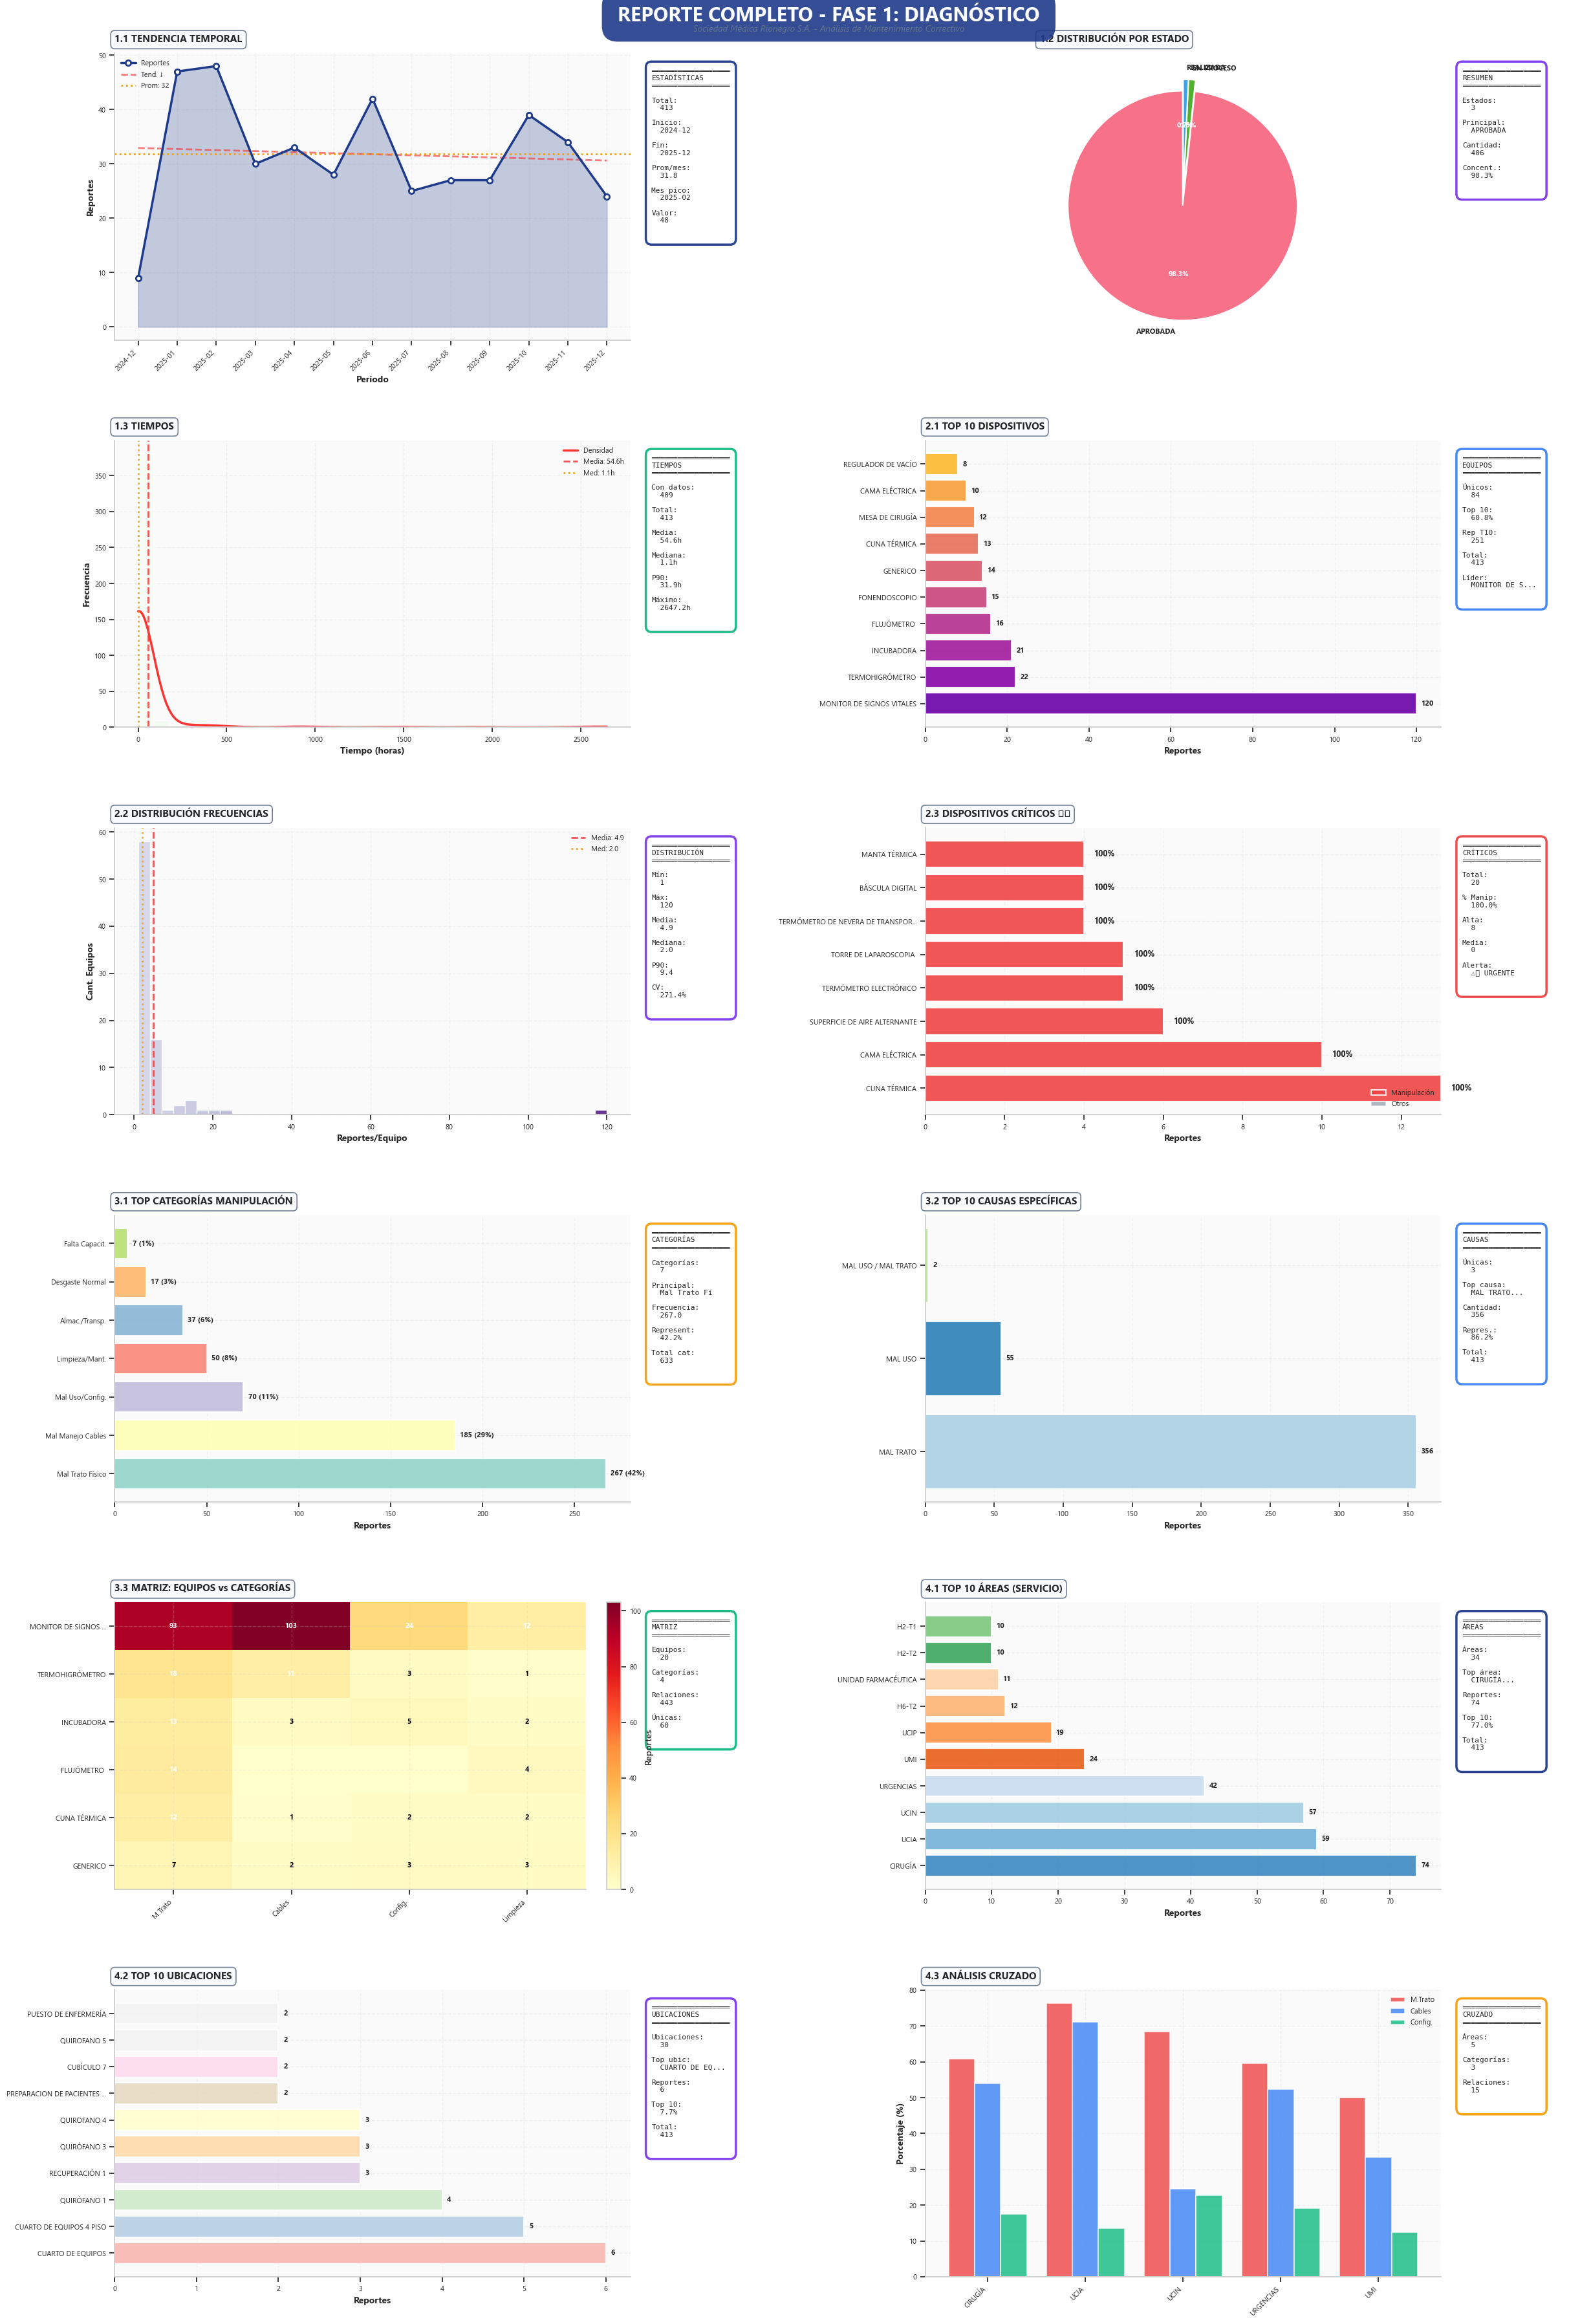

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN GLOBAL PROFESIONAL
# ═══════════════════════════════════════════════════════════════════════

# Paleta de colores corporativa
PALETTE = {
    'primary': '#1e3a8a',      # Azul oscuro
    'secondary': '#7c3aed',     # Púrpura
    'accent': '#f59e0b',        # Ámbar
    'success': '#10b981',       # Verde
    'danger': '#ef4444',        # Rojo
    'info': '#3b82f6',          # Azul claro
    'neutral': '#64748b',       # Gris
    'bg_light': '#f8fafc'       # Fondo claro
}

# Estilo matplotlib profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.0)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Segoe UI', 'Arial', 'Helvetica'],
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'semibold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.titlesize': 16,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.facecolor': '#fafafa',
    'figure.facecolor': 'white',
    'axes.edgecolor': '#cccccc'
})

print("═" * 90)
print("  REPORTE VISUAL MEJORADO - ANÁLISIS FASE 1: DIAGNÓSTICO")
print("  Sociedad Médica Rionegro S.A. | Ana Luisa Parra Valencia")
print("═" * 90)

# ═══════════════════════════════════════════════════════════════════════
# CREAR FIGURA PRINCIPAL CON LAYOUT 6x2 (6 FILAS, 2 COLUMNAS)
# ═══════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(24, 36))
fig.patch.set_facecolor('white')

# Título principal elegante
fig.text(0.5, 0.995, 'REPORTE COMPLETO - FASE 1: DIAGNÓSTICO', 
         ha='center', va='top', fontsize=22, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.8', facecolor=PALETTE['primary'], 
                  edgecolor='none', alpha=0.9), color='white')

fig.text(0.5, 0.987, 'Sociedad Médica Rionegro S.A. - Análisis de Mantenimiento Correctivo',
         ha='center', va='top', fontsize=10, style='italic', color=PALETTE['neutral'])

# Grid layout: 6 filas × 2 columnas principales
# Cada celda tiene: gráfico (80%) + stats (20%)
gs_main = GridSpec(6, 2, figure=fig, hspace=0.35, wspace=0.25, 
                   top=0.975, bottom=0.02, left=0.04, right=0.98)

# Crear sub-grids para cada celda (gráfico + stats)
axes_graficos = []
axes_stats = []

for row in range(6):
    for col in range(2):
        # Sub-grid dentro de cada celda
        gs_sub = gs_main[row, col].subgridspec(1, 10, wspace=0.3)
        
        # Gráfico (80%)
        ax_grafico = fig.add_subplot(gs_sub[0, 0:8])
        axes_graficos.append(ax_grafico)
        
        # Panel stats (20%)
        ax_stat = fig.add_subplot(gs_sub[0, 8:10])
        ax_stat.axis('off')
        axes_stats.append(ax_stat)

# ═══════════════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES
# ═══════════════════════════════════════════════════════════════════════

def add_stats_panel(ax_stat, title, stats_dict, color=PALETTE['primary']):
    """Agrega panel de estadísticas lateral profesional"""
    ax_stat.clear()
    ax_stat.axis('off')
    
    # Título del panel
    text = f"{'═' * 18}\n{title}\n{'═' * 18}\n\n"
    
    # Agregar estadísticas
    for key, value in stats_dict.items():
        text += f"{key}:\n  {value}\n\n"
    
    ax_stat.text(0.05, 0.95, text, transform=ax_stat.transAxes,
                fontsize=8, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='white',
                         edgecolor=color, linewidth=2.5, alpha=0.95))

def format_title(ax, title):
    """Formatea títulos de gráficos de manera consistente"""
    ax.set_title(title, fontsize=11, fontweight='bold', pad=12, loc='left',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=PALETTE['bg_light'],
                         edgecolor=PALETTE['neutral'], linewidth=1.2, alpha=0.9))

# ═══════════════════════════════════════════════════════════════════════
# OBJETIVO 1: REVISIÓN DE REPORTES
# ═══════════════════════════════════════════════════════════════════════

print("\n▶ OBJETIVO 1: Revisión de reportes de mantenimiento correctivo")
print("─" * 90)

# ───────────────────────────────────────────────────────────────────────
# 1.1 TENDENCIA TEMPORAL (Posición 0)
# ───────────────────────────────────────────────────────────────────────
ax1 = axes_graficos[0]
ax1_stats = axes_stats[0]

if 'FECCRE' in df_analisis.columns and 'AÑO_MES' in df_analisis.columns:
    reportes_mes = df_analisis['AÑO_MES'].value_counts().sort_index().tail(24)
    
    x_pos = np.arange(len(reportes_mes))
    valores = reportes_mes.values
    
    # Área con gradiente
    ax1.fill_between(x_pos, 0, valores, alpha=0.25, color=PALETTE['primary'])
    
    # Línea principal
    ax1.plot(x_pos, valores, marker='o', linewidth=2.5, markersize=6,
            color=PALETTE['primary'], markerfacecolor='white',
            markeredgewidth=2, markeredgecolor=PALETTE['primary'],
            label='Reportes', zorder=3)
    
    # Tendencia
    if len(valores) > 1:
        z = np.polyfit(x_pos, valores, 1)
        p = np.poly1d(z)
        tendencia = "↑" if z[0] > 0 else "↓"
        ax1.plot(x_pos, p(x_pos), "--", color=PALETTE['danger'], 
                linewidth=2, alpha=0.7, label=f'Tend. {tendencia}')
    
    # Promedio
    promedio = valores.mean()
    ax1.axhline(y=promedio, color=PALETTE['accent'], linestyle=':', 
               linewidth=2, label=f'Prom: {promedio:.0f}', zorder=2)
    
    # Ejes
    step = max(1, len(reportes_mes) // 8)
    ax1.set_xticks(x_pos[::step])
    ax1.set_xticklabels([str(reportes_mes.index[i]) for i in range(0, len(reportes_mes), step)],
                        rotation=45, ha='right', fontsize=8)
    
    ax1.set_ylabel('Reportes', fontweight='bold')
    ax1.set_xlabel('Período', fontweight='bold')
    format_title(ax1, '1.1 TENDENCIA TEMPORAL')
    
    ax1.legend(loc='upper left', framealpha=0.95, fontsize=8)
    ax1.grid(True, alpha=0.2)
    ax1.set_axisbelow(True)
    
    # Stats
    stats = {
        'Total': f"{len(df_analisis):,}",
        'Inicio': str(reportes_mes.index.min()),
        'Fin': str(reportes_mes.index.max()),
        'Prom/mes': f"{promedio:.1f}",
        'Mes pico': str(reportes_mes.idxmax()),
        'Valor': f"{reportes_mes.max():,}"
    }
    add_stats_panel(ax1_stats, "ESTADÍSTICAS", stats, PALETTE['primary'])
    print(f"  ✓ Total: {len(df_analisis):,}")

else:
    ax1.text(0.5, 0.5, '⚠ SIN DATOS',
            ha='center', va='center', transform=ax1.transAxes, fontsize=14)
    format_title(ax1, '1.1 TENDENCIA TEMPORAL')
    add_stats_panel(ax1_stats, "ESTADO", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 1.2 DISTRIBUCIÓN POR ESTADO (Posición 1)
# ───────────────────────────────────────────────────────────────────────
ax2 = axes_graficos[1]
ax2_stats = axes_stats[1]

if 'ESTADO' in df_analisis.columns:
    estado_counts = df_analisis['ESTADO'].value_counts().head(6)
    
    colors = sns.color_palette("husl", len(estado_counts))
    
    labels = [str(lbl)[:20] + '...' if len(str(lbl)) > 20 else str(lbl) 
              for lbl in estado_counts.index]
    
    explode = [0.08 if i == 0 else 0.02 for i in range(len(estado_counts))]
    
    wedges, texts, autotexts = ax2.pie(
        estado_counts.values,
        labels=labels,
        autopct=lambda pct: f'{pct:.1f}%',
        startangle=90,
        colors=colors,
        explode=explode,
        textprops={'fontsize': 8, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontsize(8)
    
    format_title(ax2, '1.2 DISTRIBUCIÓN POR ESTADO')
    
    stats = {
        'Estados': f"{df_analisis['ESTADO'].nunique()}",
        'Principal': str(estado_counts.index[0])[:12],
        'Cantidad': f"{estado_counts.values[0]:,}",
        'Concent.': f"{estado_counts.values[0]/len(df_analisis)*100:.1f}%"
    }
    add_stats_panel(ax2_stats, "RESUMEN", stats, PALETTE['secondary'])
    print(f"  ✓ Estados: {df_analisis['ESTADO'].nunique()}")

else:
    ax2.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
            transform=ax2.transAxes, fontsize=14)
    format_title(ax2, '1.2 DISTRIBUCIÓN')
    add_stats_panel(ax2_stats, "ESTADO", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 1.3 TIEMPOS DE REPARACIÓN (Posición 2)
# ───────────────────────────────────────────────────────────────────────
ax3 = axes_graficos[2]
ax3_stats = axes_stats[2]

if 'TIETOT' in df_analisis.columns and df_analisis['TIETOT'].notna().any():
    tiempos = df_analisis['TIETOT'].dropna()
    
    if len(tiempos) > 0:
        if tiempos.max() > 100:
            tiempos = tiempos / 60
        
        n, bins, patches = ax3.hist(tiempos, bins=30, alpha=0.75,
                                   color=PALETTE['success'], edgecolor='white',
                                   linewidth=1.2)
        
        cm = plt.cm.Greens
        norm = plt.Normalize(vmin=bins.min(), vmax=bins.max())
        for patch, bin_val in zip(patches, bins[:-1]):
            patch.set_facecolor(cm(norm(bin_val)))
        
        if len(tiempos) > 5:
            from scipy.stats import gaussian_kde
            kde = gaussian_kde(tiempos)
            x_kde = np.linspace(tiempos.min(), tiempos.max(), 200)
            y_kde = kde(x_kde) * len(tiempos) * (bins[1] - bins[0])
            ax3.plot(x_kde, y_kde, 'r-', linewidth=2.5, alpha=0.8, label='Densidad')
        
        media = tiempos.mean()
        mediana = tiempos.median()
        p90 = np.percentile(tiempos, 90)
        
        ax3.axvline(media, color=PALETTE['danger'], linestyle='--',
                   linewidth=2, label=f'Media: {media:.1f}h', alpha=0.9)
        ax3.axvline(mediana, color=PALETTE['accent'], linestyle=':',
                   linewidth=2, label=f'Med: {mediana:.1f}h', alpha=0.9)
        
        ax3.set_xlabel('Tiempo (horas)', fontweight='bold')
        ax3.set_ylabel('Frecuencia', fontweight='bold')
        format_title(ax3, '1.3 TIEMPOS DE REPARACIÓN')
        
        ax3.legend(loc='upper right', framealpha=0.95, fontsize=8)
        ax3.grid(True, alpha=0.2, axis='y')
        ax3.set_axisbelow(True)
        
        stats = {
            'Con datos': f"{len(tiempos):,}",
            'Total': f"{len(df_analisis):,}",
            'Media': f"{media:.1f}h",
            'Mediana': f"{mediana:.1f}h",
            'P90': f"{p90:.1f}h",
            'Máximo': f"{tiempos.max():.1f}h"
        }
        add_stats_panel(ax3_stats, "TIEMPOS", stats, PALETTE['success'])
        print(f"  ✓ Tiempo medio: {media:.1f}h")
    else:
        ax3.text(0.5, 0.5, '⚠ INSUFICIENTES', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=14)
        add_stats_panel(ax3_stats, "TIEMPOS", {'Info': 'Insuficientes'}, PALETTE['danger'])
else:
    ax3.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
            transform=ax3.transAxes, fontsize=14)
    add_stats_panel(ax3_stats, "TIEMPOS", {'Info': 'Sin datos'}, PALETTE['danger'])

format_title(ax3, '1.3 TIEMPOS')

# ═══════════════════════════════════════════════════════════════════════
# OBJETIVO 2: DISPOSITIVOS
# ═══════════════════════════════════════════════════════════════════════

print("\n▶ OBJETIVO 2: Dispositivos con mayor frecuencia")
print("─" * 90)

# ───────────────────────────────────────────────────────────────────────
# 2.1 TOP DISPOSITIVOS (Posición 3)
# ───────────────────────────────────────────────────────────────────────
ax4 = axes_graficos[3]
ax4_stats = axes_stats[3]

if 'EQUIPO' in df_analisis.columns:
    top_equipos = df_analisis['EQUIPO'].value_counts().head(10)
    
    labels = [str(eq)[:35] + '...' if len(str(eq)) > 35 else str(eq) 
              for eq in top_equipos.index]
    
    colors = plt.cm.plasma(np.linspace(0.2, 0.85, len(top_equipos)))
    
    y_pos = np.arange(len(top_equipos))
    bars = ax4.barh(y_pos, top_equipos.values, color=colors,
                   edgecolor='white', linewidth=1.5, alpha=0.9)
    
    for i, (bar, val) in enumerate(zip(bars, top_equipos.values)):
        ax4.text(val + max(top_equipos.values) * 0.01,
                bar.get_y() + bar.get_height()/2, f'{val:,}',
                va='center', ha='left', fontsize=8, fontweight='bold')
    
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(labels, fontsize=8)
    ax4.set_xlabel('Reportes', fontweight='bold')
    format_title(ax4, '2.1 TOP 10 DISPOSITIVOS')
    
    ax4.grid(True, alpha=0.2, axis='x')
    ax4.set_axisbelow(True)
    
    total = len(df_analisis)
    top10_sum = top_equipos.sum()
    pct = top10_sum / total * 100
    
    stats = {
        'Únicos': f"{df_analisis['EQUIPO'].nunique():,}",
        'Top 10': f"{pct:.1f}%",
        'Rep T10': f"{top10_sum:,}",
        'Total': f"{total:,}",
        'Líder': str(top_equipos.index[0])[:12] + '...'
    }
    add_stats_panel(ax4_stats, "EQUIPOS", stats, PALETTE['info'])
    print(f"  ✓ Únicos: {df_analisis['EQUIPO'].nunique():,}")

else:
    ax4.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
            transform=ax4.transAxes, fontsize=14)
    format_title(ax4, '2.1 TOP DISPOSITIVOS')
    add_stats_panel(ax4_stats, "EQUIPOS", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 2.2 DISTRIBUCIÓN FRECUENCIAS (Posición 4)
# ───────────────────────────────────────────────────────────────────────
ax5 = axes_graficos[4]
ax5_stats = axes_stats[4]

if 'EQUIPO' in df_analisis.columns:
    frec = df_analisis['EQUIPO'].value_counts().values
    
    n, bins, patches = ax5.hist(frec, bins=40, alpha=0.8,
                               color=PALETTE['secondary'], edgecolor='white',
                               linewidth=1)
    
    cm = plt.cm.Purples
    norm = plt.Normalize(vmin=bins.min(), vmax=bins.max())
    for patch, bin_val in zip(patches, bins[:-1]):
        patch.set_facecolor(cm(norm(bin_val) * 0.7 + 0.3))
    
    media = frec.mean()
    mediana = np.median(frec)
    p90 = np.percentile(frec, 90)
    
    ax5.axvline(media, color=PALETTE['danger'], linestyle='--',
               linewidth=2, label=f'Media: {media:.1f}', alpha=0.9)
    ax5.axvline(mediana, color=PALETTE['accent'], linestyle=':',
               linewidth=2, label=f'Med: {mediana:.1f}', alpha=0.9)
    
    ax5.set_xlabel('Reportes/Equipo', fontweight='bold')
    ax5.set_ylabel('Cant. Equipos', fontweight='bold')
    format_title(ax5, '2.2 DISTRIBUCIÓN FRECUENCIAS')
    
    ax5.legend(loc='upper right', framealpha=0.95, fontsize=8)
    ax5.grid(True, alpha=0.2)
    ax5.set_axisbelow(True)
    
    cv = frec.std() / media * 100
    stats = {
        'Mín': f"{frec.min():,}",
        'Máx': f"{frec.max():,}",
        'Media': f"{media:.1f}",
        'Mediana': f"{mediana:.1f}",
        'P90': f"{p90:.1f}",
        'CV': f"{cv:.1f}%"
    }
    add_stats_panel(ax5_stats, "DISTRIBUCIÓN", stats, PALETTE['secondary'])
    print(f"  ✓ Media: {media:.1f}")

else:
    ax5.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
            transform=ax5.transAxes, fontsize=14)
    format_title(ax5, '2.2 DISTRIBUCIÓN')
    add_stats_panel(ax5_stats, "DIST", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 2.3 DISPOSITIVOS CRÍTICOS (Posición 5)
# ───────────────────────────────────────────────────────────────────────
ax6 = axes_graficos[5]
ax6_stats = axes_stats[5]

if 'df_criticos' in locals() and len(df_criticos) > 0:
    top_crit = df_criticos.head(8).copy().sort_values('%_MANIPULACION')
    
    color_map = {'ALTA': PALETTE['danger'], 'MEDIA': PALETTE['accent']}
    colors_prio = [color_map.get(p, PALETTE['neutral']) for p in top_crit['PRIORIDAD']]
    
    nombres = [str(eq)[:32] + '...' if len(str(eq)) > 32 else str(eq) 
               for eq in top_crit['EQUIPO']]
    
    y_pos = np.arange(len(top_crit))
    
    bars1 = ax6.barh(y_pos, top_crit['REPORTES_MANIPULACION'],
                    color=colors_prio, alpha=0.9, label='Manipulación',
                    edgecolor='white', linewidth=1.5)
    
    bars2 = ax6.barh(y_pos,
                    top_crit['TOTAL_REPORTES'] - top_crit['REPORTES_MANIPULACION'],
                    left=top_crit['REPORTES_MANIPULACION'],
                    color=PALETTE['neutral'], alpha=0.5, label='Otros',
                    edgecolor='white', linewidth=1.5)
    
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(nombres, fontsize=8)
    ax6.set_xlabel('Reportes', fontweight='bold')
    format_title(ax6, '2.3 DISPOSITIVOS CRÍTICOS ⚠️')
    
    ax6.legend(loc='lower right', framealpha=0.95, fontsize=8)
    ax6.grid(True, alpha=0.2, axis='x')
    ax6.set_axisbelow(True)
    
    for i, row in enumerate(top_crit.itertuples()):
        pct = row._4
        total = row.TOTAL_REPORTES
        ax6.text(total + max(top_crit['TOTAL_REPORTES']) * 0.02, i,
                f"{pct:.0f}%", va='center', ha='left', fontsize=9,
                fontweight='bold')
    
    avg_manip = top_crit['%_MANIPULACION'].mean()
    alta = (top_crit['PRIORIDAD'] == 'ALTA').sum()
    
    stats = {
        'Total': f"{len(df_criticos):,}",
        '% Manip': f"{avg_manip:.1f}%",
        'Alta': f"{alta}",
        'Media': f"{len(top_crit)-alta}",
        'Alerta': '⚠️ URGENTE'
    }
    add_stats_panel(ax6_stats, "CRÍTICOS", stats, PALETTE['danger'])
    print(f"  ✓ Críticos: {len(df_criticos):,}")

else:
    ax6.text(0.5, 0.5, '✓ SIN CRÍTICOS', ha='center', va='center', 
            transform=ax6.transAxes, fontsize=14, color=PALETTE['success'])
    format_title(ax6, '2.3 CRÍTICOS')
    add_stats_panel(ax6_stats, "CRÍTICOS", {'Info': 'Sin críticos'}, PALETTE['success'])

# ═══════════════════════════════════════════════════════════════════════
# OBJETIVO 3: CLASIFICACIÓN DE DAÑOS
# ═══════════════════════════════════════════════════════════════════════

print("\n▶ OBJETIVO 3: Clasificación de daños según causa raíz")
print("─" * 90)

# ───────────────────────────────────────────────────────────────────────
# 3.1 CATEGORÍAS MANIPULACIÓN (Posición 6)
# ───────────────────────────────────────────────────────────────────────
ax7 = axes_graficos[6]
ax7_stats = axes_stats[6]

if 'df_categorias_manip' in locals() and len(df_categorias_manip) > 0:
    top_cat = df_categorias_manip.head(8)
    
    cat_trad = {
        'MAL_USO_CONFIGURACION': 'Mal Uso/Config.',
        'MAL_TRATO_FISICO': 'Mal Trato Físico',
        'MAL_MANEJO_CABLES': 'Mal Manejo Cables',
        'MALA_LIMPIEZA_MANTENIMIENTO': 'Limpieza/Mant.',
        'MAL_ALMACENAMIENTO_TRANSPORTE': 'Almac./Transp.',
        'FALTA_CAPACITACION': 'Falta Capacit.',
        'DESGASTE_NORMAL': 'Desgaste Normal',
        'NO_IDENTIFICADO': 'No Identificado'
    }
    
    labels = [cat_trad.get(cat, cat) for cat in top_cat.index]
    
    colors = sns.color_palette("Set3", len(top_cat))
    
    y_pos = np.arange(len(top_cat))
    bars = ax7.barh(y_pos, top_cat['FRECUENCIA'], 
                   color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)
    
    total_cat = top_cat['FRECUENCIA'].sum()
    for i, (bar, val) in enumerate(zip(bars, top_cat['FRECUENCIA'])):
        pct = (val / total_cat) * 100
        ax7.text(val + max(top_cat['FRECUENCIA']) * 0.01,
                bar.get_y() + bar.get_height()/2,
                f"{val:,} ({pct:.0f}%)", va='center', ha='left', 
                fontsize=8, fontweight='bold')
    
    ax7.set_yticks(y_pos)
    ax7.set_yticklabels(labels, fontsize=8)
    ax7.set_xlabel('Reportes', fontweight='bold')
    format_title(ax7, '3.1 TOP CATEGORÍAS MANIPULACIÓN')
    
    ax7.grid(True, alpha=0.2, axis='x')
    ax7.set_axisbelow(True)
    
    cat_principal = top_cat.index[0]
    freq_principal = top_cat.iloc[0]['FRECUENCIA']
    pct_principal = (freq_principal / total_cat) * 100
    
    stats = {
        'Categorías': f"{len(df_categorias_manip):,}",
        'Principal': cat_trad.get(cat_principal, cat_principal)[:12],
        'Frecuencia': f"{freq_principal:,}",
        'Represent': f"{pct_principal:.1f}%",
        'Total cat': f"{total_cat:,}"
    }
    add_stats_panel(ax7_stats, "CATEGORÍAS", stats, PALETTE['accent'])
    print(f"  ✓ Categorías: {len(df_categorias_manip):,}")

else:
    ax7.text(0.5, 0.5, '⚠ SIN CATEGORÍAS', ha='center', va='center', 
            transform=ax7.transAxes, fontsize=14)
    format_title(ax7, '3.1 CATEGORÍAS')
    add_stats_panel(ax7_stats, "CATEGORÍAS", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 3.2 CAUSAS ESPECÍFICAS (Posición 7)
# ───────────────────────────────────────────────────────────────────────
ax8 = axes_graficos[7]
ax8_stats = axes_stats[7]

if 'CAUSA_LIMPIA' in df_analisis.columns:
    top_causas = df_analisis['CAUSA_LIMPIA'].value_counts().head(10)
    
    labels = [str(c)[:32] + '...' if len(str(c)) > 32 else str(c) 
              for c in top_causas.index]
    
    colors = plt.cm.Paired(np.arange(len(top_causas)))
    
    y_pos = np.arange(len(top_causas))
    bars = ax8.barh(y_pos, top_causas.values, 
                   color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)
    
    for i, (bar, val) in enumerate(zip(bars, top_causas.values)):
        ax8.text(val + max(top_causas.values) * 0.01,
                bar.get_y() + bar.get_height()/2, f'{val:,}',
                va='center', ha='left', fontsize=8, fontweight='bold')
    
    ax8.set_yticks(y_pos)
    ax8.set_yticklabels(labels, fontsize=8)
    ax8.set_xlabel('Reportes', fontweight='bold')
    format_title(ax8, '3.2 TOP 10 CAUSAS ESPECÍFICAS')
    
    ax8.grid(True, alpha=0.2, axis='x')
    ax8.set_axisbelow(True)
    
    causas_unicas = df_analisis['CAUSA_LIMPIA'].nunique()
    total_causas = len(df_analisis)
    top_pct = (top_causas.values[0] / total_causas) * 100
    
    stats = {
        'Únicas': f"{causas_unicas:,}",
        'Top causa': str(top_causas.index[0])[:12] + '...',
        'Cantidad': f"{top_causas.values[0]:,}",
        'Repres.': f"{top_pct:.1f}%",
        'Total': f"{total_causas:,}"
    }
    add_stats_panel(ax8_stats, "CAUSAS", stats, PALETTE['info'])
    print(f"  ✓ Causas únicas: {causas_unicas:,}")

else:
    ax8.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
            transform=ax8.transAxes, fontsize=14)
    format_title(ax8, '3.2 CAUSAS')
    add_stats_panel(ax8_stats, "CAUSAS", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 3.3 MATRIZ EQUIPOS-CATEGORÍAS (Posición 8)
# ───────────────────────────────────────────────────────────────────────
ax9 = axes_graficos[8]
ax9_stats = axes_stats[8]

if 'matriz_filtrada' in locals() and not matriz_filtrada.empty:
    # Top 6x6 para mejor visualización
    top_eq_matriz = matriz_filtrada.sum(axis=1).nlargest(6).index
    top_cat_matriz = matriz_filtrada.sum(axis=0).nlargest(6).index
    
    matriz_visual = matriz_filtrada.loc[top_eq_matriz, top_cat_matriz]
    
    equipos_visual = [str(eq)[:18] + '...' if len(str(eq)) > 18 else str(eq) 
                      for eq in matriz_visual.index]
    
    cat_trad = {
        'MAL_USO_CONFIGURACION': 'Config.',
        'MAL_TRATO_FISICO': 'M.Trato',
        'MAL_MANEJO_CABLES': 'Cables',
        'MALA_LIMPIEZA_MANTENIMIENTO': 'Limpieza',
        'FALTA_CAPACITACION': 'Capacit.',
        'DESGASTE_NORMAL': 'Desgaste'
    }
    
    cats_visual = [cat_trad.get(cat, str(cat)[:10]) for cat in matriz_visual.columns]
    
    im = ax9.imshow(matriz_visual.values, cmap='YlOrRd', aspect='auto')
    
    ax9.set_xticks(range(len(cats_visual)))
    ax9.set_yticks(range(len(equipos_visual)))
    ax9.set_xticklabels(cats_visual, rotation=45, ha='right', fontsize=8)
    ax9.set_yticklabels(equipos_visual, fontsize=8)
    
    # Valores en celdas
    for i in range(len(equipos_visual)):
        for j in range(len(cats_visual)):
            val = matriz_visual.iloc[i, j]
            if val > 0:
                color = 'white' if val > np.percentile(matriz_visual.values[matriz_visual.values>0], 60) else 'black'
                ax9.text(j, i, str(val), ha='center', va='center',
                        color=color, fontsize=8, fontweight='bold')
    
    format_title(ax9, '3.3 MATRIZ: EQUIPOS vs CATEGORÍAS')
    
    plt.colorbar(im, ax=ax9, fraction=0.046, pad=0.04, label='Reportes')
    
    relaciones_totales = matriz_filtrada.sum().sum()
    relaciones_unicas = (matriz_filtrada > 0).sum().sum()
    
    stats = {
        'Equipos': f"{matriz_filtrada.shape[0]:,}",
        'Categorías': f"{matriz_filtrada.shape[1]:,}",
        'Relaciones': f"{relaciones_totales:,}",
        'Únicas': f"{relaciones_unicas:,}"
    }
    add_stats_panel(ax9_stats, "MATRIZ", stats, PALETTE['success'])
    print(f"  ✓ Matriz: {matriz_filtrada.shape[0]}×{matriz_filtrada.shape[1]}")

else:
    ax9.text(0.5, 0.5, '⚠ SIN MATRIZ', ha='center', va='center', 
            transform=ax9.transAxes, fontsize=14)
    format_title(ax9, '3.3 MATRIZ')
    add_stats_panel(ax9_stats, "MATRIZ", {'Info': 'Sin datos'}, PALETTE['danger'])

# ═══════════════════════════════════════════════════════════════════════
# OBJETIVO 4: ÁREAS ASISTENCIALES
# ═══════════════════════════════════════════════════════════════════════

print("\n▶ OBJETIVO 4: Áreas asistenciales con mayor incidencia")
print("─" * 90)

# ───────────────────────────────────────────────────────────────────────
# 4.1 TOP ÁREAS (Posición 9)
# ───────────────────────────────────────────────────────────────────────
ax10 = axes_graficos[9]
ax10_stats = axes_stats[9]

areas_disp = [col for col in ['SERVICI', 'UBICA'] if col in df_analisis.columns]

if areas_disp:
    col_area = areas_disp[0]
    top_areas = df_analisis[col_area].value_counts().head(10)
    
    labels = [str(a)[:28] + '...' if len(str(a)) > 28 else str(a) 
              for a in top_areas.index]
    
    colors = plt.cm.tab20c(np.arange(len(top_areas)))
    
    y_pos = np.arange(len(top_areas))
    bars = ax10.barh(y_pos, top_areas.values, 
                    color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)
    
    for i, (bar, val) in enumerate(zip(bars, top_areas.values)):
        ax10.text(val + max(top_areas.values) * 0.01,
                 bar.get_y() + bar.get_height()/2, f'{val:,}',
                 va='center', ha='left', fontsize=8, fontweight='bold')
    
    ax10.set_yticks(y_pos)
    ax10.set_yticklabels(labels, fontsize=8)
    ax10.set_xlabel('Reportes', fontweight='bold')
    titulo = 'SERVICIO' if col_area == 'SERVICI' else 'UBICACIÓN'
    format_title(ax10, f'4.1 TOP 10 ÁREAS ({titulo})')
    
    ax10.grid(True, alpha=0.2, axis='x')
    ax10.set_axisbelow(True)
    
    total_areas = df_analisis[col_area].nunique()
    total_rep = len(df_analisis)
    top_sum = top_areas.sum()
    pct_top10 = (top_sum / total_rep) * 100
    
    stats = {
        'Áreas': f"{total_areas:,}",
        'Top área': str(top_areas.index[0])[:12] + '...',
        'Reportes': f"{top_areas.values[0]:,}",
        'Top 10': f"{pct_top10:.1f}%",
        'Total': f"{total_rep:,}"
    }
    add_stats_panel(ax10_stats, "ÁREAS", stats, PALETTE['primary'])
    print(f"  ✓ Áreas: {total_areas:,}")

else:
    ax10.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
             transform=ax10.transAxes, fontsize=14)
    format_title(ax10, '4.1 ÁREAS')
    add_stats_panel(ax10_stats, "ÁREAS", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 4.2 UBICACIONES (Posición 10)
# ───────────────────────────────────────────────────────────────────────
ax11 = axes_graficos[10]
ax11_stats = axes_stats[10]

if 'UBICA' in df_analisis.columns and df_analisis['UBICA'].notna().any():
    ubicaciones = df_analisis['UBICA'].value_counts().head(10)
    
    labels = [str(u)[:25] + '...' if len(str(u)) > 25 else str(u) 
              for u in ubicaciones.index]
    
    colors = plt.cm.Pastel1(np.arange(len(ubicaciones)))
    
    y_pos = np.arange(len(ubicaciones))
    bars = ax11.barh(y_pos, ubicaciones.values, 
                    color=colors, edgecolor='white', linewidth=1.5, alpha=0.85)
    
    for i, (bar, val) in enumerate(zip(bars, ubicaciones.values)):
        ax11.text(val + max(ubicaciones.values) * 0.01,
                 bar.get_y() + bar.get_height()/2, f'{val:,}',
                 va='center', ha='left', fontsize=8, fontweight='bold')
    
    ax11.set_yticks(y_pos)
    ax11.set_yticklabels(labels, fontsize=8)
    ax11.set_xlabel('Reportes', fontweight='bold')
    format_title(ax11, '4.2 TOP 10 UBICACIONES')
    
    ax11.grid(True, alpha=0.2, axis='x')
    ax11.set_axisbelow(True)
    
    ubic_unicas = df_analisis['UBICA'].nunique()
    total_u = len(df_analisis)
    top_u_sum = ubicaciones.sum()
    pct_u = (top_u_sum / total_u) * 100
    
    stats = {
        'Ubicaciones': f"{ubic_unicas:,}",
        'Top ubic': str(ubicaciones.index[0])[:12] + '...',
        'Reportes': f"{ubicaciones.values[0]:,}",
        'Top 10': f"{pct_u:.1f}%",
        'Total': f"{total_u:,}"
    }
    add_stats_panel(ax11_stats, "UBICACIONES", stats, PALETTE['secondary'])
    print(f"  ✓ Ubicaciones: {ubic_unicas:,}")

else:
    ax11.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
             transform=ax11.transAxes, fontsize=14)
    format_title(ax11, '4.2 UBICACIONES')
    add_stats_panel(ax11_stats, "UBICACIONES", {'Info': 'Sin datos'}, PALETTE['danger'])

# ───────────────────────────────────────────────────────────────────────
# 4.3 ANÁLISIS CRUZADO ÁREAS-CATEGORÍAS (Posición 11)
# ───────────────────────────────────────────────────────────────────────
ax12 = axes_graficos[11]
ax12_stats = axes_stats[11]

if areas_disp and 'CATEGORIA_MANIPULACION_LISTA' in df_analisis.columns:
    col_area = areas_disp[0]
    top_5_areas = df_analisis[col_area].value_counts().head(5).index
    
    categorias_principales = []
    if 'CATEGORIAS_MANIPULACION' in locals():
        categorias_principales = CATEGORIAS_MANIPULACION[:3]
    
    if categorias_principales and len(top_5_areas) > 0:
        datos_agr = []
        
        for area in top_5_areas:
            subset = df_analisis[df_analisis[col_area] == area]
            total_area = len(subset)
            
            for categoria in categorias_principales:
                count = 0
                for cats in subset['CATEGORIA_MANIPULACION_LISTA']:
                    if isinstance(cats, list) and categoria in cats:
                        count += 1
                
                pct = (count / total_area * 100) if total_area > 0 else 0
                datos_agr.append({
                    'Área': area,
                    'Categoría': categoria,
                    'Porcentaje': pct,
                    'Conteo': count
                })
        
        df_agr = pd.DataFrame(datos_agr)
        
        n_areas = len(top_5_areas)
        n_cats = len(categorias_principales)
        bar_width = 0.8 / n_cats
        
        areas_labels = [str(a)[:18] + '...' if len(str(a)) > 18 else str(a) 
                        for a in top_5_areas]
        
        cat_trad = {
            'MAL_USO_CONFIGURACION': 'Config.',
            'MAL_TRATO_FISICO': 'M.Trato',
            'MAL_MANEJO_CABLES': 'Cables',
            'MALA_LIMPIEZA_MANTENIMIENTO': 'Limpieza',
            'FALTA_CAPACITACION': 'Capacit.'
        }
        
        cat_labels = [cat_trad.get(cat, cat) for cat in categorias_principales]
        colors_cats = [PALETTE['danger'], PALETTE['info'], PALETTE['success'], 
                       PALETTE['accent'], PALETTE['secondary']]
        
        for i, (categoria, color) in enumerate(zip(categorias_principales, colors_cats[:n_cats])):
            valores = df_agr[df_agr['Categoría'] == categoria]['Porcentaje']
            posiciones = np.arange(n_areas) + i * bar_width
            ax12.bar(posiciones, valores, width=bar_width, 
                    color=color, label=cat_labels[i], alpha=0.8, 
                    edgecolor='white', linewidth=1.2)
        
        ax12.set_xticks(np.arange(n_areas) + bar_width * (n_cats - 1) / 2)
        ax12.set_xticklabels(areas_labels, rotation=45, ha='right', fontsize=8)
        ax12.set_ylabel('Porcentaje (%)', fontweight='bold')
        titulo_cruz = 'SERVICIOS' if col_area == 'SERVICI' else 'UBICACIONES'
        format_title(ax12, f'4.3 CATEGORÍAS POR {titulo_cruz}')
        
        ax12.legend(fontsize=8, loc='upper right', framealpha=0.95)
        ax12.grid(True, alpha=0.2, axis='y')
        ax12.set_axisbelow(True)
        
        stats = {
            'Áreas': f"{n_areas}",
            'Categorías': f"{n_cats}",
            'Relaciones': f"{len(df_agr[df_agr['Conteo'] > 0]):,}"
        }
        add_stats_panel(ax12_stats, "CRUZADO", stats, PALETTE['accent'])
        print(f"  ✓ Análisis: {n_areas}×{n_cats}")
    else:
        ax12.text(0.5, 0.5, '⚠ INSUFICIENTE', ha='center', va='center', 
                 transform=ax12.transAxes, fontsize=14)
        add_stats_panel(ax12_stats, "CRUZADO", {'Info': 'Insuficiente'}, PALETTE['danger'])
else:
    ax12.text(0.5, 0.5, '⚠ SIN DATOS', ha='center', va='center', 
             transform=ax12.transAxes, fontsize=14)
    add_stats_panel(ax12_stats, "CRUZADO", {'Info': 'Sin datos'}, PALETTE['danger'])

format_title(ax12, '4.3 ANÁLISIS CRUZADO')

# ═══════════════════════════════════════════════════════════════════════
# GUARDAR Y FINALIZAR
# ═══════════════════════════════════════════════════════════════════════

plt.tight_layout()

fecha = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
archivo_png = f'resultados/REPORTE_MEJORADO_6x2_FASE1_{fecha}.png'
archivo_pdf = f'resultados/REPORTE_MEJORADO_6x2_FASE1_{fecha}.pdf'

plt.savefig(archivo_png, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(archivo_pdf, dpi=300, bbox_inches='tight', facecolor='white')

print("\n" + "═" * 90)
print(f"  ✅ Reporte PNG: {archivo_png}")
print(f"  ✅ Reporte PDF: {archivo_pdf}")
print("  ✅ Layout: 6 filas × 2 columnas (12 gráficos totales)")
print("  ✅ Cada gráfico tiene su panel de estadísticas lateral")
print("═" * 90)
print(f"\n  📊 REPORTE COMPLETADO - {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}")
print("  🏥 Sociedad Médica Rionegro S.A.")
print("  👤 Ana Luisa Parra Valencia")
print("═" * 90)

plt.show()